# Proyecto Integrador — Metodología CRISP-DM
## Predicción de alto desempeño en la prueba Saber 11 · Antioquia 2022-2

| Campo | Valor |
|---|---|
| Programa | Maestría en Ciencia de Datos — proyecto práctico de la asignatura |
| Propósito | **Netamente educativo**: estudiar y profundizar en CRISP-DM y el aprendizaje supervisado |
| Tipo de problema | Clasificación binaria (aprendizaje supervisado) |
| Fuente | ICFES — *Resultados únicos Saber 11*, Datos Abiertos Colombia (`kgxf-xxbe`) |
| Enlace | https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe |

> ⚠️ **Aviso académico:** este cuaderno es material de estudio de nivel maestría. No es una herramienta oficial del ICFES
> ni de ninguna entidad, y sus predicciones no deben usarse para tomar decisiones sobre estudiantes reales.

### Cómo estudiar este cuaderno
| Símbolo | Qué es | Cómo usarlo |
|---|---|---|
| 📘 **Concepto** | Teoría de la técnica: definición, intuición, fórmula, supuestos y limitaciones | Léelo **antes** de ejecutar la celda |
| 💻 Código comentado | Cada paso explica el *qué* y el *porqué* | Ejecútalo, lee los comentarios y modifica parámetros |
| 🔎 **Interpretación** | Lectura de la salida con las cifras obtenidas | Compárala con tu propia lectura del resultado |
| 🧠 **Para profundizar** | Ideas clave, preguntas de repaso, ejercicios y referencias al cierre de cada fase | Responde las preguntas sin mirar y haz los ejercicios |

**Contenido:** 0. Configuración · 1. Negocio · 2. Datos · 3. Preparación · 4. Modelamiento · 5. Evaluación · 6. Despliegue

#### 📘 Concepto: CRISP-DM
**CRISP-DM** (*Cross-Industry Standard Process for Data Mining*, 1999–2000) es el proceso de referencia más usado para
proyectos de analítica. Tiene **seis fases**:

1. **Entendimiento del negocio:** qué problema se resuelve, para quién y cómo se medirá el éxito.
2. **Entendimiento de los datos:** qué datos hay, qué significan y qué calidad tienen.
3. **Preparación de los datos:** selección, limpieza, transformación y construcción de variables (suele consumir 60–80 % del esfuerzo).
4. **Modelamiento:** elección y ajuste de algoritmos.
5. **Evaluación:** ¿el modelo cumple los objetivos de negocio, no solo los técnicos?
6. **Despliegue:** poner el modelo al servicio de los usuarios.

El proceso es **iterativo**: lo que se descubre en una fase obliga a volver a otra (por ejemplo, un sesgo detectado en la
evaluación lleva a revisar la preparación). Este cuaderno sigue las seis fases en orden y numera las secciones igual que el
formato de entrega del curso.

## 0. Configuración del entorno

In [1]:
# 0.1 Instalación de dependencias (solo se ejecuta en Google Colab)
# En local las librerías ya están en el entorno virtual .venv; en Colab hay que instalarlas en cada sesión.
import sys          # Permite saber qué intérprete de Python está corriendo y qué módulos están cargados
import subprocess   # Permite ejecutar "pip install" desde Python

# Colab carga el módulo google.colab al iniciar: si está presente, estamos en Colab
EN_COLAB = "google.colab" in sys.modules

# Versiones exactas usadas al entrenar (se inyectan desde requirements-notebook.txt al construir el cuaderno).
# Fijar versiones garantiza que otra persona obtenga los mismos resultados y que el modelo serializado cargue sin errores.
PAQUETES = ['scikit-learn==1.9.1', 'imbalanced-learn==0.14.2', 'xgboost==3.4.1', 'ydata-profiling==4.18.4', 'setuptools<81']
# Librerías que Colab puede tener ya cargadas en memoria (nombre del módulo -> nombre del paquete en pip)
LIBRERIAS_BASE = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "matplotlib": "matplotlib",
                  "sklearn": "scikit-learn"}

if EN_COLAB:
    from importlib.metadata import version   # Lee la versión instalada de un paquete sin importarlo
    # Versiones de las librerías ya cargadas, antes de instalar
    antes = {paquete: version(paquete) for modulo, paquete in LIBRERIAS_BASE.items() if modulo in sys.modules}
    # "-q" (quiet) reduce la salida de pip; *PAQUETES pasa cada elemento de la lista como argumento independiente
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *PAQUETES])
    print("Dependencias instaladas en Colab:", PAQUETES)
    # Si pip cambió una librería que ya estaba en memoria, la sesión seguiría usando la versión vieja: hay que reiniciar
    cambiadas = [paquete for paquete, v in antes.items() if version(paquete) != v]
    if cambiadas:
        print(f"⚠️ pip cambió librerías que ya estaban cargadas: {', '.join(cambiadas)}. Reinicie la sesión (Entorno de "
              "ejecución → Reiniciar sesión) y vuelva a ejecutar desde esta celda: la segunda vez pip no cambiará nada.")
else:
    print("Ejecución local: se usa el entorno virtual .venv del proyecto.")

Ejecución local: se usa el entorno virtual .venv del proyecto.


🔎 **Interpretación:** En local el cuaderno usa el entorno virtual `.venv`, así que no instala nada. En Colab instalaría las versiones exactas de scikit-learn, imbalanced-learn, xgboost y ydata-profiling, más `setuptools<81`, que ydata-profiling necesita para importar `pkg_resources`. Si pip reemplaza una librería que Colab ya tenía cargada (por ejemplo numpy), la celda avisa que hay que reiniciar la sesión: seguir sin reiniciar mezclaría versiones en memoria.
**Por qué importa:** el pipeline se serializa con una versión concreta de scikit-learn (fase 6), y cargarlo con otra versión puede fallar o cambiar las predicciones. Fijar versiones es la primera condición de la reproducibilidad.

In [2]:
# 0.2 Importación de librerías, agrupadas por propósito
# --- Utilidades estándar de Python ---
import json                           # Guardar la metadata del modelo en formato legible
import time                           # Medir cuánto tarda cada paso costoso
import warnings                       # Silenciar avisos que no afectan los resultados
from pathlib import Path              # Rutas de archivos independientes del sistema operativo
from urllib.parse import urlencode    # Construir la URL de la API con caracteres especiales codificados

# --- Manipulación de datos y visualización ---
import numpy as np                    # Cálculo numérico vectorizado
import pandas as pd                   # Tablas (DataFrame) y operaciones sobre columnas
import matplotlib.pyplot as plt       # Gráficos base
import seaborn as sns                 # Gráficos estadísticos sobre matplotlib
from scipy import stats               # Pruebas estadísticas (χ², t, binomial, Spearman)
from scipy.stats import loguniform, randint, uniform   # Distribuciones para la búsqueda aleatoria de hiperparámetros

# --- Librerías de modelamiento (se importa el módulo completo para registrar sus versiones) ---
import sklearn
import imblearn
import xgboost
import joblib                         # Serialización eficiente de modelos de scikit-learn
from sklearn.base import clone        # Copia "sin entrenar" de un estimador (evita reutilizar modelos ya ajustados)
from sklearn.compose import ColumnTransformer          # Aplica transformaciones distintas por tipo de columna
from sklearn.decomposition import PCA                  # Reducción de dimensiones
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier   # Ensambles
try:  # En algunas versiones la búsqueda por mitades sucesivas sigue siendo experimental y requiere habilitarse
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
except ImportError:
    pass
from sklearn.feature_selection import mutual_info_classif     # Información mutua (dependencia no lineal)
from sklearn.impute import SimpleImputer                       # Imputación de valores faltantes
from sklearn.inspection import permutation_importance         # Importancia de variables agnóstica al modelo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             accuracy_score, average_precision_score, classification_report,
                             f1_score, precision_score, recall_score, roc_auc_score)   # Métricas de clasificación
from sklearn.model_selection import (HalvingRandomSearchCV, RandomizedSearchCV, StratifiedKFold,
                                     TunedThresholdClassifierCV, cross_val_score, cross_validate,
                                     learning_curve, train_test_split)                 # Validación y búsqueda
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline                          # Encadena pasos de preprocesamiento
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler   # Codificación y escalado
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE                       # Sobremuestreo sintético de la clase minoritaria
from imblearn.pipeline import Pipeline as ImbPipeline          # Pipeline que admite pasos de remuestreo
from imblearn.under_sampling import RandomUnderSampler         # Submuestreo aleatorio de la clase mayoritaria
from xgboost import XGBClassifier                              # Boosting por gradiente optimizado

# Silenciamos avisos de deprecación y de categorías desconocidas: no cambian los resultados y ensucian la salida
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)                 # Mostrar todas las columnas de las tablas anchas
pd.set_option("display.float_format", "{:.4f}".format)   # Cuatro decimales en las tablas

# Registrar versiones es parte de la reproducibilidad: un resultado sin versiones no se puede repetir con certeza
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__} | xgboost {xgboost.__version__}")

Python 3.12.10 | pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.9.1 | imbalanced-learn 0.14.2 | xgboost 3.4.1


🔎 **Interpretación:** Todas las librerías cargan sin errores. Las versiones quedan registradas: Python 3.12.10, pandas 2.3.3, numpy 2.3.5, scikit-learn 1.9.1, imbalanced-learn 0.14.2 y xgboost 3.4.1.
Se usa pandas 2.x, y no 3.x, porque ydata-profiling 4.18 exige `pandas<3`. Es un ejemplo real de **gestión de dependencias**: una librería del proyecto restringe la versión de otra.

In [3]:
# 0.3 Parámetros globales, rutas y utilidades
# Centralizar los parámetros aquí permite experimentar (p. ej. cambiar el umbral) sin buscar números "mágicos" en el código.
RANDOM_STATE = 42                                  # Semilla única: muestreos, particiones y modelos reproducibles
UMBRAL_ALTO_DESEMPENO = 300                        # Regla de negocio: punt_global >= 300 => clase positiva (1)
N_MUESTRA_MODELADO = 30_000                        # Muestra estratificada para modelar (el SVM escala ~n² en tiempo)
TEST_SIZE = 0.30                                   # 70 % entrenamiento / 30 % prueba, como exige la actividad
N_ITER_BUSQUEDA = 20                               # Combinaciones que prueba cada búsqueda aleatoria
FECHA_REFERENCIA = pd.Timestamp("2022-08-01")      # Referencia aproximada de la aplicación 2022-2 para calcular la edad
# StratifiedKFold conserva en cada fold la proporción de clases; shuffle + semilla => los mismos 5 folds para todos los modelos
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
np.random.seed(RANDOM_STATE)                       # Semilla también para funciones de numpy sin random_state propio

# Rutas relativas: funcionan igual en local (se ejecuta desde notebooks/) y en Colab (se ejecuta desde /content)
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_RAW = BASE_DIR / "data" / "raw"             # Datos tal como llegan de la fuente
DIR_PROC = BASE_DIR / "data" / "processed"      # Datos limpios
DIR_NUEVOS = BASE_DIR / "data" / "nuevos"       # Datos para probar el despliegue
DIR_MODELOS = BASE_DIR / "models"               # Pipeline serializado y metadata
DIR_REPORTES = BASE_DIR / "reports"             # Reporte HTML de perfilamiento
DIR_FIGURAS = DIR_REPORTES / "figures"          # Gráficos para el informe y la app
DIR_TABLAS = DIR_REPORTES / "tablas"            # Tablas que alimentan el informe U4
for carpeta in [DIR_RAW, DIR_PROC, DIR_NUEVOS, DIR_MODELOS, DIR_FIGURAS, DIR_TABLAS]:
    carpeta.mkdir(parents=True, exist_ok=True)  # Crea la carpeta si no existe (y sus padres)

sns.set_theme(style="whitegrid", palette="deep")   # Estilo visual uniforme para todos los gráficos
plt.rcParams["figure.dpi"] = 110                   # Resolución de las figuras en pantalla


def guardar_figura(nombre: str) -> None:
    """Guarda la figura activa en reports/figures para reutilizarla en el informe y la app."""
    plt.savefig(DIR_FIGURAS / f"{nombre}.png", bbox_inches="tight", dpi=150)


def guardar_tabla(df: pd.DataFrame, nombre: str) -> pd.DataFrame:
    """Exporta una tabla a reports/tablas (insumo del informe U4) y la devuelve para mostrarla."""
    df.to_csv(DIR_TABLAS / f"{nombre}.csv", index=False, encoding="utf-8")
    return df


print("Directorio base del proyecto:", BASE_DIR)

Directorio base del proyecto: D:\proyectos ia\ML CRYSPY


🔎 **Interpretación:** Se fijan la semilla (42), el umbral de negocio (300), el tamaño de la muestra (30.000), la partición 70/30 y un único objeto `CV` con 5 folds estratificados.
Que todos los modelos compartan exactamente los mismos folds es lo que permite, en la fase 5, comparar sus F1 fold a fold con pruebas **pareadas**. Las carpetas de salida se crean de forma relativa, así que el cuaderno funciona igual en local y en Colab.

## 1. Entendimiento del negocio

### 1.1 Contexto
La prueba **Saber 11** es el examen de Estado que presentan quienes terminan la educación media en Colombia. La aplica el
ICFES y evalúa cinco áreas (Lectura crítica, Matemáticas, Sociales y ciudadanas, Ciencias naturales e Inglés).
El **puntaje global (0–500)** se usa en la admisión a la educación superior, en la asignación de becas y créditos y en la
clasificación de los colegios. Junto con los resultados, el ICFES recoge información socioeconómica del hogar y
características del colegio, lo que permite estudiar las brechas de desempeño.

En Antioquia, el conjunto publicado para 2022-2 trae 144.766 registros, pero cerca de la mitad son duplicados exactos
(se depuran en 3.3): quedan unos 72 mil estudiantes. Como **caso de estudio académico**
se plantea el escenario de una secretaría de educación que quisiera identificar temprano a los estudiantes con baja
probabilidad de alto desempeño para focalizar nivelación, preparación y orientación vocacional.

### 1.2 Problema predictivo
¿Es posible estimar, **con información disponible antes del examen** (hogar, estudiante y colegio), la probabilidad de que
un estudiante de Antioquia obtenga un **puntaje global ≥ 300**?
- **Variable objetivo:** `alto_desempeno` = 1 si `punt_global ≥ 300`; 0 en otro caso.
- **Unidad de análisis:** estudiante evaluado en 2022-2 en un colegio de Antioquia.
- **Umbral:** 300 puntos equivale al 60 % de la escala y separa aproximadamente al 17 % superior (se verifica en la sección 2.3).

### 1.3 Objetivos de minería de datos
1. Construir un clasificador supervisado con un **F1 de la clase positiva** superior a la línea base (regresión logística).
2. Comparar 5 modelos clásicos y 3 de ensamble con validación cruzada estratificada sobre el 70 % de entrenamiento.
3. Identificar las variables más asociadas al alto desempeño (importancia por permutación).
4. Desplegar el pipeline en una aplicación web (Streamlit) como demostración académica.

### 1.4 Diseño de la solución
| Tipo de análisis | Tipo de aprendizaje | Modelos propuestos | Métrica principal |
|---|---|---|---|
| Predictivo | Supervisado (clasificación binaria) | Regresión Logística, KNN, Árbol de Decisión, SVM (RBF), Random Forest; ensambles: Votación suave, Bagging, XGBoost | **F1** de la clase positiva (complementarias: Recall, Precision, ROC-AUC, PR-AUC) |

**¿Por qué F1?** Con cerca de 17 % de positivos, un modelo que siempre predice "no alto" tendría 83 % de *accuracy* sin
ningún valor práctico. F1 equilibra precisión y exhaustividad sobre la clase de interés (se profundiza en la fase 5).

**Uso ético:** el modelo describe asociaciones estructurales (socioeconómicas), no causas. Aun en un escenario real serviría
para asignar apoyos, **nunca** para excluir estudiantes o tomar decisiones individuales adversas.

### 🧠 Para profundizar — Fase 1: Entendimiento del negocio
**Ideas clave**
- Un proyecto de analítica empieza por una **pregunta de negocio** y un **criterio de éxito medible**, no por un algoritmo.
- Traducir el problema a un objetivo de minería implica decidir la unidad de análisis, la variable objetivo y la métrica.
- Solo pueden usarse variables **disponibles en el momento de la predicción**; lo demás es fuga de información.

**Preguntas de repaso**
1. ¿Por qué *accuracy* es engañosa cuando la clase positiva es el 17 % de los datos?
2. ¿Qué cambiaría en el diseño si el problema se planteara como regresión del puntaje global?
3. ¿Qué riesgos éticos aparecen al predecir desempeño académico con variables socioeconómicas?

**Ejercicios**
- Reformula el problema con otro umbral (250 o 350) y anticipa cómo cambiarían el desbalance y la métrica adecuada.
- Redacta un criterio de éxito de negocio (no técnico) para este modelo.

**Referencias**
- Chapman, P. et al. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS.
- Wirth, R. y Hipp, J. (2000). CRISP-DM: Towards a standard process model for data mining. *4th Int. Conf. on the Practical Applications of Knowledge Discovery and Data Mining*.
- Provost, F. y Fawcett, T. (2013). *Data Science for Business*. O'Reilly (cap. 2: problemas de negocio y minería de datos).

## 2. Entendimiento de los datos
### 2.0 Carga de los datos desde Datos Abiertos Colombia

#### 📘 Concepto: Datos abiertos y API Socrata
**Datos Abiertos Colombia** (datos.gov.co) publica conjuntos de datos del Estado con licencia libre; este usa
CC BY-SA 4.0, que obliga a citar la fuente y a compartir obras derivadas con la misma licencia. La plataforma usa
**Socrata**, que expone cada conjunto como una **API REST** (SODA) con un lenguaje de consulta parecido a SQL (**SoQL**):

| Parámetro | Equivale en SQL a | Uso aquí |
|---|---|---|
| `$where` | `WHERE` | `periodo='20224' AND cole_depto_ubicacion='ANTIOQUIA'` |
| `$select` | `SELECT` | (todas las columnas) |
| `$limit` | `LIMIT` | 200.000, por encima del total esperado |

**¿Por qué filtrar en el servidor?** El conjunto completo tiene millones de filas (2010–2022). Pedir solo el subconjunto
necesario reduce la descarga de gigabytes a unos 75 MB. **Buena práctica:** guardar una copia local del dato crudo, porque
los datos abiertos pueden actualizarse o dejar de estar disponibles, y el análisis debe poder repetirse con los mismos datos.

In [4]:
# 2.0.1 Descarga desde la API Socrata de datos.gov.co (o lectura de la copia local si ya existe)
ID_DATASET = "kgxf-xxbe"   # Identificador del conjunto "Resultados únicos Saber 11" en datos.gov.co
URL_DATASET = f"https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/{ID_DATASET}"   # Página pública (para citar)
FILTRO = "periodo='20224' AND cole_depto_ubicacion='ANTIOQUIA'"   # Cláusula SoQL: periodo 2022-2 y colegios de Antioquia
# urlencode convierte espacios, comillas y el símbolo $ a su forma segura dentro de una URL
URL_API = f"https://www.datos.gov.co/resource/{ID_DATASET}.csv?" + urlencode({"$where": FILTRO, "$limit": 200000})
RUTA_RAW = DIR_RAW / "saber11_antioquia_20224.csv.gz"   # Copia local comprimida con gzip (≈ 10 veces más liviana)

inicio = time.time()
if RUTA_RAW.exists():
    # dtype=str lee todo como texto: evita que pandas convierta códigos como "05001" en el número 5001
    df_raw = pd.read_csv(RUTA_RAW, dtype=str)
    origen = f"copia local ({RUTA_RAW.name})"
else:
    df_raw = pd.read_csv(URL_API, dtype=str)                  # pandas descarga el CSV directamente desde la URL
    df_raw.to_csv(RUTA_RAW, index=False, compression="gzip")  # Respaldo reproducible y entregable "dataset utilizado"
    origen = "API datos.gov.co"

print(f"Origen: {origen} | Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]} | {time.time() - inicio:.1f} s")
df_raw.head(3).T   # Transpuesta: con 51 columnas se leen mejor como filas

Origen: copia local (saber11_antioquia_20224.csv.gz) | Filas: 144,766 | Columnas: 51 | 2.9 s


,0,1,2
periodo,20224,20224,20224
estu_tipodocumento,TI,TI,TI
estu_consecutivo,SB11202240101947,SB11202240372907,SB11202240007813
cole_area_ubicacion,RURAL,URBANO,URBANO
cole_bilingue,NaN,N,N
cole_calendario,A,A,A
cole_caracter,NO APLICA,ACADÉMICO,TÉCNICO
cole_cod_dane_establecimiento,205034000329,305088002615,205789000370
cole_cod_dane_sede,205034001457,305088002615,105789000278
cole_cod_depto_ubicacion,05,05,05


🔎 **Interpretación:** Se leyó la copia local del CSV descargado de la API (144.766 filas × 51 columnas, en pocos segundos). La primera vez se descarga de datos.gov.co con el filtro SoQL `periodo='20224' AND cole_depto_ubicacion='ANTIOQUIA'`.
En la vista transpuesta se ve la mezcla típica de un registro: códigos DANE como texto (`05034`), categorías socioeconómicas y los puntajes. Leer todo como texto (`dtype=str`) evitó que los códigos perdieran el cero inicial, como explica el 📘 de esta sección.

In [5]:
# 2.0.2 Conversión de tipos: los puntajes pasan a numérico; el resto son categóricas o texto
# Solo los puntajes son cantidades con las que tiene sentido operar (promedios, rangos); los códigos siguen siendo texto
COLS_PUNTAJES = ["punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas",
                 "punt_c_naturales", "punt_lectura_critica", "punt_global"]
for col in COLS_PUNTAJES:
    # errors="coerce" convierte en NaN cualquier valor no numérico en lugar de detener la ejecución
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Resumen por columna: tipo, completitud y cardinalidad (primer diagnóstico de calidad)
resumen_tipos = pd.DataFrame({"tipo_pandas": df_raw.dtypes.astype(str),          # object = texto; float64 = numérico
                              "no_nulos": df_raw.notna().sum(),                  # Registros con dato
                              "pct_nulos": (df_raw.isna().mean() * 100).round(2),   # % de faltantes
                              "valores_unicos": df_raw.nunique()})               # Cardinalidad: 1 = constante
resumen_tipos

,tipo_pandas,no_nulos,pct_nulos,valores_unicos
periodo,object,144766,0.0000,1
estu_tipodocumento,object,144766,0.0000,9
estu_consecutivo,object,144766,0.0000,72383
cole_area_ubicacion,object,144766,0.0000,2
cole_bilingue,object,121044,16.3900,2
cole_calendario,object,144766,0.0000,2
cole_caracter,object,140022,3.2800,4
cole_cod_dane_establecimiento,object,144766,0.0000,1122
cole_cod_dane_sede,object,144766,0.0000,1447
cole_cod_depto_ubicacion,object,144766,0.0000,1


🔎 **Interpretación:** Tras convertir los seis puntajes a numérico, el resumen revela los primeros problemas de calidad:
- `estu_consecutivo` tiene solo **72.383 valores únicos en 144.766 filas**: cada evaluado aparece dos veces (se confirma en 2.2.2).
- Hay nulos entre 3 % y 16 % en variables del hogar y del colegio (`cole_bilingue` 16,4 %).
- `periodo`, `cole_depto_ubicacion` y `estu_estudiante` tienen un único valor: son constantes por construcción del filtro.

La **cardinalidad** (valores únicos) anticipa qué columnas son identificadores (códigos de colegio con más de 1.000 valores) y cuáles son categóricas útiles (2 a 12 valores).

### 2.1 Diccionario de datos

#### 📘 Concepto: Diccionario de datos y fuga de información
Un **diccionario de datos** documenta cada variable: significado, tipo, dominio de valores y **rol** en el problema
(entrada, salida o excluida). Obliga a entender cada columna antes de usarla y es la base de las reglas de calidad.

La **fuga de información** (*data leakage*) ocurre cuando el modelo usa información que **no estaría disponible en el
momento de predecir** o que contiene la respuesta de forma indirecta. Un modelo con fuga obtiene métricas excelentes en
el laboratorio y falla en la práctica. Aquí, `punt_matematicas`, `punt_lectura_critica`, etc. son **componentes** del
puntaje global: incluirlos haría el problema trivial y el modelo inútil para anticipar el resultado antes del examen.
Kaufman et al. (2012) distinguen dos tipos:
- **Fuga en las variables:** columnas que codifican la respuesta.
- **Fuga en el entrenamiento:** usar datos de prueba al ajustar el preprocesamiento. Se evita con *pipelines* (fase 3).

In [6]:
# 2.1.1 Roles propuestos: variables de entrada (por tipo), objetivo y constantes de apoyo
# Separar por tipo es clave: cada tipo recibe un preprocesamiento distinto en la fase 3
VARIABLES_NUMERICAS = ["edad"]                                         # Cantidad continua: se imputa y estandariza
VARIABLES_ORDINALES = ["fami_estratovivienda", "fami_educacionmadre",  # Categorías con orden natural:
                       "fami_educacionpadre", "fami_personashogar",    # se codifican como 0 < 1 < 2 ...
                       "fami_cuartoshogar"]
VARIABLES_NOMINALES = ["estu_genero", "fami_tieneinternet", "fami_tienecomputador",   # Categorías sin orden:
                       "fami_tieneautomovil", "fami_tienelavadora", "cole_naturaleza",  # se codifican con One-Hot
                       "cole_jornada", "cole_area_ubicacion", "cole_bilingue", "cole_caracter",
                       "cole_genero", "cole_sede_principal", "cole_valle_aburra"]
FEATURES = VARIABLES_NUMERICAS + VARIABLES_ORDINALES + VARIABLES_NOMINALES   # 19 variables de entrada en total
OBJETIVO = "alto_desempeno"                                                 # Nombre de la variable a predecir
# Columnas originales que no entran al modelo, pero de las que se derivan variables nuevas
INSUMOS_DERIVADAS = {"estu_fechanacimiento": "edad", "cole_cod_mcpio_ubicacion": "cole_valle_aburra"}
# Códigos DANE de los 10 municipios del Valle de Aburrá (área metropolitana de Medellín)
CODIGOS_VALLE_ABURRA = ["05001", "05079", "05088", "05129", "05212",   # Medellín, Barbosa, Bello, Caldas, Copacabana
                        "05266", "05308", "05360", "05380", "05631"]   # Envigado, Girardota, Itagüí, La Estrella, Sabaneta

# Descripción de cada columna (según la documentación del ICFES) y de las variables derivadas
DESCRIPCIONES = {
    "periodo": "Periodo de aplicación (año + semestre; 20224 = 2022-2)",
    "estu_tipodocumento": "Tipo de documento de identidad del evaluado",
    "estu_consecutivo": "Identificador anonimizado del evaluado",
    "cole_area_ubicacion": "Área de ubicación de la sede (URBANO/RURAL)",
    "cole_bilingue": "Colegio bilingüe (S/N)",
    "cole_calendario": "Calendario académico del colegio (A/B/OTRO)",
    "cole_caracter": "Carácter del colegio (académico, técnico, técnico/académico)",
    "cole_cod_dane_establecimiento": "Código DANE del establecimiento",
    "cole_cod_dane_sede": "Código DANE de la sede",
    "cole_cod_depto_ubicacion": "Código DANE del departamento del colegio",
    "cole_cod_mcpio_ubicacion": "Código DANE del municipio del colegio",
    "cole_codigo_icfes": "Código ICFES del colegio",
    "cole_depto_ubicacion": "Departamento del colegio",
    "cole_genero": "Población del colegio por género (MIXTO/FEMENINO/MASCULINO)",
    "cole_jornada": "Jornada (MAÑANA, TARDE, COMPLETA, UNICA, NOCHE, SABATINA)",
    "cole_mcpio_ubicacion": "Municipio del colegio",
    "cole_naturaleza": "Naturaleza del colegio (OFICIAL/NO OFICIAL)",
    "cole_nombre_establecimiento": "Nombre del establecimiento",
    "cole_nombre_sede": "Nombre de la sede",
    "cole_sede_principal": "Sede principal (S/N)",
    "estu_cod_depto_presentacion": "Código del departamento donde presentó la prueba",
    "estu_cod_mcpio_presentacion": "Código del municipio donde presentó la prueba",
    "estu_cod_reside_depto": "Código del departamento de residencia",
    "estu_cod_reside_mcpio": "Código del municipio de residencia",
    "estu_depto_presentacion": "Departamento donde presentó la prueba",
    "estu_depto_reside": "Departamento de residencia",
    "estu_estadoinvestigacion": "Estado del resultado (PUBLICAR o en investigación)",
    "estu_estudiante": "Tipo de evaluado",
    "estu_fechanacimiento": "Fecha de nacimiento (dd/mm/aaaa)",
    "estu_genero": "Género del estudiante (F/M)",
    "estu_mcpio_presentacion": "Municipio donde presentó la prueba",
    "estu_mcpio_reside": "Municipio de residencia",
    "estu_nacionalidad": "Nacionalidad del estudiante",
    "estu_pais_reside": "País de residencia",
    "estu_privado_libertad": "Evaluado privado de la libertad (S/N)",
    "fami_cuartoshogar": "Número de cuartos del hogar",
    "fami_educacionmadre": "Máximo nivel educativo de la madre",
    "fami_educacionpadre": "Máximo nivel educativo del padre",
    "fami_estratovivienda": "Estrato socioeconómico de la vivienda",
    "fami_personashogar": "Número de personas en el hogar",
    "fami_tieneautomovil": "El hogar tiene automóvil (Si/No)",
    "fami_tienecomputador": "El hogar tiene computador (Si/No)",
    "fami_tieneinternet": "El hogar tiene internet (Si/No)",
    "fami_tienelavadora": "El hogar tiene lavadora (Si/No)",
    "desemp_ingles": "Nivel de desempeño en inglés (A-, A1, A2, B1, B+)",
    "punt_ingles": "Puntaje en inglés (0–100)",
    "punt_matematicas": "Puntaje en matemáticas (0–100)",
    "punt_sociales_ciudadanas": "Puntaje en sociales y ciudadanas (0–100)",
    "punt_c_naturales": "Puntaje en ciencias naturales (0–100)",
    "punt_lectura_critica": "Puntaje en lectura crítica (0–100)",
    "punt_global": "Puntaje global (0–500)",
    "edad": "DERIVADA: edad en años al 1-ago-2022 a partir de estu_fechanacimiento",
    "cole_valle_aburra": "DERIVADA: colegio en el Valle de Aburrá (Sí/No) según el código DANE del municipio",
    "alto_desempeno": "OBJETIVO: 1 si punt_global ≥ 300; 0 en otro caso",
}
# Motivo de exclusión de cada columna que no entra al modelo (documenta la decisión para el evaluador)
MOTIVOS_EXCLUSION = {
    "periodo": "Constante (filtro 2022-2)", "cole_depto_ubicacion": "Constante (filtro Antioquia)",
    "cole_cod_depto_ubicacion": "Constante (filtro Antioquia)", "estu_estudiante": "Constante",
    "cole_calendario": "Casi constante (calendario A)", "estu_nacionalidad": "Casi constante (Colombia)",
    "estu_pais_reside": "Casi constante (Colombia)", "estu_privado_libertad": "Casi constante (N)",
    "estu_tipodocumento": "Administrativa, sin relación causal plausible con el desempeño",
    "estu_consecutivo": "Identificador", "cole_codigo_icfes": "Identificador de alta cardinalidad",
    "cole_cod_dane_establecimiento": "Identificador de alta cardinalidad", "cole_cod_dane_sede": "Identificador de alta cardinalidad",
    "cole_nombre_establecimiento": "Identificador de alta cardinalidad", "cole_nombre_sede": "Identificador de alta cardinalidad",
    "cole_mcpio_ubicacion": "Redundante con el código de municipio",
    "estu_cod_depto_presentacion": "Redundante con la ubicación del colegio", "estu_cod_mcpio_presentacion": "Redundante con la ubicación del colegio",
    "estu_depto_presentacion": "Redundante con la ubicación del colegio", "estu_mcpio_presentacion": "Redundante con la ubicación del colegio",
    "estu_cod_reside_depto": "Redundante con la ubicación del colegio", "estu_cod_reside_mcpio": "Redundante con la ubicación del colegio",
    "estu_depto_reside": "Redundante con la ubicación del colegio", "estu_mcpio_reside": "Redundante con la ubicación del colegio",
    "estu_estadoinvestigacion": "Control de calidad: se usa para filtrar resultados no oficiales",
    "desemp_ingles": "Fuga de información: derivada del puntaje de inglés",
    "punt_ingles": "Fuga de información: componente del puntaje global", "punt_matematicas": "Fuga de información: componente del puntaje global",
    "punt_sociales_ciudadanas": "Fuga de información: componente del puntaje global",
    "punt_c_naturales": "Fuga de información: componente del puntaje global", "punt_lectura_critica": "Fuga de información: componente del puntaje global",
}


def rol_variable(var):
    """Rol de cada variable en el problema predictivo (se evalúa en orden de prioridad)."""
    if var == OBJETIVO:
        return "Salida (objetivo)"
    if var in FEATURES:
        return "Entrada"
    if var in INSUMOS_DERIVADAS:
        return f"Insumo para derivar {INSUMOS_DERIVADAS[var]}"
    if var == "punt_global":
        return "Insumo para construir el objetivo"   # No es entrada: de él se deriva la clase
    return "Excluida"


# El diccionario cubre las 51 columnas originales + las 2 derivadas + el objetivo
variables_diccionario = list(df_raw.columns) + ["edad", "cole_valle_aburra", OBJETIVO]
diccionario = pd.DataFrame({
    "variable": variables_diccionario,
    "descripcion": [DESCRIPCIONES[v] for v in variables_diccionario],
    "tipo": ["Num" if v in COLS_PUNTAJES + ["edad"] else "Cat" for v in variables_diccionario],   # Formato U4: Num/Cat
    "rol": [rol_variable(v) for v in variables_diccionario],
    "observacion": [MOTIVOS_EXCLUSION.get(v, "") for v in variables_diccionario],   # Vacío si la variable se usa
})
guardar_tabla(diccionario, "diccionario_datos")   # Insumo de la tabla 2.1 del informe
diccionario

,variable,descripcion,tipo,rol,observacion
0,periodo,Periodo de aplicación (año + semestre; 20224 =...,Cat,Excluida,Constante (filtro 2022-2)
1,estu_tipodocumento,Tipo de documento de identidad del evaluado,Cat,Excluida,"Administrativa, sin relación causal plausible ..."
2,estu_consecutivo,Identificador anonimizado del evaluado,Cat,Excluida,Identificador
3,cole_area_ubicacion,Área de ubicación de la sede (URBANO/RURAL),Cat,Entrada,
4,cole_bilingue,Colegio bilingüe (S/N),Cat,Entrada,
5,cole_calendario,Calendario académico del colegio (A/B/OTRO),Cat,Excluida,Casi constante (calendario A)
6,cole_caracter,"Carácter del colegio (académico, técnico, técn...",Cat,Entrada,
7,cole_cod_dane_establecimiento,Código DANE del establecimiento,Cat,Excluida,Identificador de alta cardinalidad
8,cole_cod_dane_sede,Código DANE de la sede,Cat,Excluida,Identificador de alta cardinalidad
9,cole_cod_depto_ubicacion,Código DANE del departamento del colegio,Cat,Excluida,Constante (filtro Antioquia)


🔎 **Interpretación:** El diccionario documenta 54 variables: 51 originales, 2 derivadas y el objetivo. Para cada una registra descripción, tipo (Num/Cat), rol y motivo de exclusión.
- Entran al modelo 19 variables: 1 numérica, 5 ordinales y 13 nominales.
- Seis columnas se excluyen por **fuga de información**: los cinco puntajes por área y `desemp_ingles`, que son componentes del puntaje global.
- El resto se descarta por ser identificadores, constantes o redundantes con la ubicación del colegio.

Esta tabla es la tabla 2.1 del informe y el punto de partida de la selección de variables (3.1).

In [7]:
# 2.1.2 Verificación de las variables declaradas constantes o casi constantes (% de la categoría más frecuente)
# Una afirmación del diccionario ("casi constante") debe comprobarse con los datos, no suponerse
casi_constantes = ["periodo", "cole_depto_ubicacion", "estu_estudiante", "cole_calendario",
                   "estu_nacionalidad", "estu_pais_reside", "estu_privado_libertad"]
# value_counts(normalize=True) da proporciones; iloc[0] toma la categoría más frecuente (incluye NaN con dropna=False)
pd.Series({v: df_raw[v].value_counts(normalize=True, dropna=False).iloc[0] * 100 for v in casi_constantes},
          name="pct_categoria_mas_frecuente").round(2)

periodo                 100.0000
cole_depto_ubicacion    100.0000
estu_estudiante         100.0000
cole_calendario          99.6800
estu_nacionalidad        98.5000
estu_pais_reside         98.5000
estu_privado_libertad    99.8500
Name: pct_categoria_mas_frecuente, dtype: float64

🔎 **Interpretación:** La verificación confirma lo declarado en el diccionario: `periodo`, `cole_depto_ubicacion` y `estu_estudiante` son 100 % constantes. `cole_calendario` (99,7 % A), `estu_privado_libertad` (99,85 % N) y la nacionalidad y residencia (98,5 % Colombia) son casi constantes.
Una variable con más del ~98 % en una sola categoría aporta casi nada a la discriminación y puede generar columnas one-hot con muy pocos casos. Excluirlas simplifica el modelo sin perder información. Es un ejemplo de selección **de filtro** (📘 de 3.1).

### 2.2 Reglas de calidad

#### 📘 Concepto: Calidad de datos
La calidad de datos se evalúa en varias **dimensiones** (Wang y Strong, 1996). Estas son las que se verifican aquí:

| Dimensión | Pregunta | Regla en este proyecto |
|---|---|---|
| **Completitud** | ¿Falta el dato? | % de nulos por variable |
| **Validez** | ¿El valor está en el dominio permitido? | Rangos numéricos (`punt_global ∈ [0, 500]`) y categorías válidas |
| **Unicidad** | ¿Hay registros repetidos? | Filas duplicadas e identificador único |
| **Consistencia** | ¿Los datos se contradicen? | Edad coherente con un estudiante de grado 11 (13–30 años) |

Una **regla de calidad** se escribe *antes* de mirar el detalle de los datos (qué debería cumplirse) y luego se mide su
**% de incumplimiento**. Así la limpieza de la fase 3 no es arbitraria: cada acción responde a una regla incumplida.

In [8]:
# 2.2.1 Definición de las reglas: rangos numéricos esperados y dominios categóricos válidos
def calcular_edad(fechas_texto):
    """Edad en años cumplidos a la fecha de referencia del examen (NaN si la fecha es inválida)."""
    # format fija el patrón dd/mm/aaaa; errors="coerce" convierte fechas imposibles (p. ej. 31/02) en NaT
    fecha = pd.to_datetime(fechas_texto, format="%d/%m/%Y", errors="coerce")
    # 365.25 días por año compensa los años bisiestos; floor da años cumplidos
    return np.floor((FECHA_REFERENCIA - fecha).dt.days / 365.25)


# Orden natural del nivel educativo (de menor a mayor): se reutiliza en la codificación ordinal de la fase 3
EDUCACION_ORDEN = ["Ninguno", "Primaria incompleta", "Primaria completa",
                   "Secundaria (Bachillerato) incompleta", "Secundaria (Bachillerato) completa",
                   "Técnica o tecnológica incompleta", "Técnica o tecnológica completa",
                   "Educación profesional incompleta", "Educación profesional completa", "Postgrado"]
# Regla de validez numérica: (mínimo, máximo) permitido según la escala del ICFES y la edad plausible
REGLAS_NUMERICAS = {"punt_global": (0, 500), "punt_matematicas": (0, 100), "punt_lectura_critica": (0, 100),
                    "punt_sociales_ciudadanas": (0, 100), "punt_c_naturales": (0, 100), "punt_ingles": (0, 100),
                    "edad": (13, 30)}
# Regla de validez categórica: dominio de valores aceptados por variable
CATEGORIAS_VALIDAS = {
    "estu_genero": ["F", "M"],
    "fami_estratovivienda": ["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"],
    "fami_educacionmadre": EDUCACION_ORDEN + ["No sabe", "No Aplica"],   # Se aceptan, pero se tratarán como faltantes
    "fami_educacionpadre": EDUCACION_ORDEN + ["No sabe", "No Aplica"],
    "fami_personashogar": ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"],
    "fami_cuartoshogar": ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o mas"],
    "fami_tieneinternet": ["Si", "No"], "fami_tienecomputador": ["Si", "No"],
    "fami_tieneautomovil": ["Si", "No"], "fami_tienelavadora": ["Si", "No"],
    "cole_naturaleza": ["OFICIAL", "NO OFICIAL"],
    "cole_jornada": ["COMPLETA", "MAÑANA", "TARDE", "NOCHE", "SABATINA", "UNICA"],
    "cole_area_ubicacion": ["URBANO", "RURAL"],
    "cole_bilingue": ["S", "N"],
    "cole_caracter": ["ACADÉMICO", "TÉCNICO", "TÉCNICO/ACADÉMICO", "NO APLICA"],
    "cole_genero": ["MIXTO", "FEMENINO", "MASCULINO"],
    "cole_sede_principal": ["S", "N"],
}
edad_eda = calcular_edad(df_raw["estu_fechanacimiento"])   # Edad provisional solo para medir la regla

filas = []
for var, (minimo, maximo) in REGLAS_NUMERICAS.items():
    serie = edad_eda if var == "edad" else df_raw[var]
    # Las comparaciones con NaN dan False: los nulos se cuentan aparte, no como "fuera de rango"
    fuera = int(((serie < minimo) | (serie > maximo)).sum())
    filas.append({"variable": var, "rango_esperado": f"[{minimo}, {maximo}]", "nulos": int(serie.isna().sum()),
                  "fuera_de_rango": fuera, "pct_incumplimiento": round(100 * fuera / len(serie), 3)})
tabla_reglas_num = guardar_tabla(pd.DataFrame(filas), "reglas_numericas")   # Tabla 2.2 (numéricas) del informe
tabla_reglas_num

,variable,rango_esperado,nulos,fuera_de_rango,pct_incumplimiento
0,punt_global,"[0, 500]",0,0,0.0000
1,punt_matematicas,"[0, 100]",0,0,0.0000
2,punt_lectura_critica,"[0, 100]",0,0,0.0000
3,punt_sociales_ciudadanas,"[0, 100]",0,0,0.0000
4,punt_c_naturales,"[0, 100]",0,0,0.0000
5,punt_ingles,"[0, 100]",102,0,0.0000
6,edad,"[13, 30]",0,2252,1.5560


🔎 **Interpretación:** Las reglas numéricas muestran que los puntajes respetan sus escalas: 0 % fuera de rango. Solo `punt_ingles` tiene 102 nulos.
La regla de **consistencia** de la edad, en cambio, falla en 2.252 filas (1,56 %): edades fuera de [13, 30] que delatan fechas de nacimiento mal registradas (en 3.2.1 aparece incluso una edad mínima de 0 años). Estas filas no se eliminan: la edad se marca como faltante en 3.3 porque el resto del registro es válido.

In [9]:
# 2.2.2 Evaluación de dominios categóricos y de unicidad de registros
filas = []
for var, validas in CATEGORIAS_VALIDAS.items():
    serie = df_raw[var]
    invalidas = serie.notna() & ~serie.isin(validas)   # Hay dato, pero no pertenece al dominio válido
    filas.append({"variable": var, "categorias_validas": ", ".join(validas), "nulos": int(serie.isna().sum()),
                  "valores_invalidos": int(invalidas.sum()),
                  "ejemplos_invalidos": ", ".join(map(str, serie[invalidas].unique()[:5])),   # Para diagnosticar la causa
                  "pct_incumplimiento": round(100 * invalidas.mean(), 3)})
tabla_reglas_cat = guardar_tabla(pd.DataFrame(filas), "reglas_categoricas")   # Tabla 2.2 (categóricas) del informe

# Unicidad: un duplicado exacto repite las 51 columnas; un identificador repetido indica el mismo evaluado dos veces
print(f"Filas duplicadas exactas (51 columnas): {df_raw.duplicated().sum():,}")
print(f"Identificadores estu_consecutivo repetidos: {df_raw['estu_consecutivo'].duplicated().sum():,}")
print("Estado del resultado:", df_raw["estu_estadoinvestigacion"].value_counts().to_dict())   # Resultados no oficiales
tabla_reglas_cat

Filas duplicadas exactas (51 columnas): 72,383
Identificadores estu_consecutivo repetidos: 72,383
Estado del resultado: {'PUBLICAR': 144714, 'VALIDEZ OFICINA JURÍDICA': 52}


,variable,categorias_validas,nulos,valores_invalidos,ejemplos_invalidos,pct_incumplimiento
0,estu_genero,"F, M",0,0,,0.0000
1,fami_estratovivienda,"Sin Estrato, Estrato 1, Estrato 2, Estrato 3, ...",9444,0,,0.0000
2,fami_educacionmadre,"Ninguno, Primaria incompleta, Primaria complet...",8392,0,,0.0000
3,fami_educacionpadre,"Ninguno, Primaria incompleta, Primaria complet...",8534,0,,0.0000
4,fami_personashogar,"1 a 2, 3 a 4, 5 a 6, 7 a 8, 9 o más",6608,0,,0.0000
5,fami_cuartoshogar,"Uno, Dos, Tres, Cuatro, Cinco, Seis o mas",6822,0,,0.0000
6,fami_tieneinternet,"Si, No",8514,0,,0.0000
7,fami_tienecomputador,"Si, No",6826,0,,0.0000
8,fami_tieneautomovil,"Si, No",7212,0,,0.0000
9,fami_tienelavadora,"Si, No",6848,0,,0.0000


🔎 **Interpretación:** - **Validez:** ninguna variable tiene valores fuera de su dominio (0 % de incumplimiento). No hacen falta homologaciones de texto.
- **Unicidad:** hay **72.383 filas duplicadas exactas** (las 51 columnas iguales) y el mismo número de identificadores repetidos. La mitad del archivo publicado es una copia de la otra mitad: es un problema de la fuente, no del análisis.
- **Resultados no oficiales:** 52 filas tienen estado "VALIDEZ OFICINA JURÍDICA" (26 estudiantes, porque también están duplicadas).

Sin esta regla, el modelo se habría entrenado con datos repetidos y la validación sería optimista: el mismo estudiante podría caer en entrenamiento y en prueba.

### 2.3 Distribución de la variable objetivo

#### 📘 Concepto: Variable objetivo y desbalance
La variable objetivo se construye **discretizando** el puntaje global con un umbral de negocio:

$$y_i = \mathbb{1}\left[\text{punt\_global}_i \ge 300\right]$$

Si una clase es mucho menos frecuente que la otra, el problema está **desbalanceado**. Consecuencias:
- Los algoritmos que minimizan el error global tienden a ignorar la clase minoritaria.
- La *accuracy* deja de ser informativa: con 17 % de positivos, predecir siempre 0 da 83 % de acierto.
- Hay que elegir métricas centradas en la clase positiva (Precision, Recall, F1, PR-AUC) y considerar técnicas de balanceo (fase 3).

El **percentil** del umbral indica qué porcentaje de estudiantes queda por debajo. Sirve para saber si el umbral define un
grupo "élite" muy pequeño o un grupo amplio.

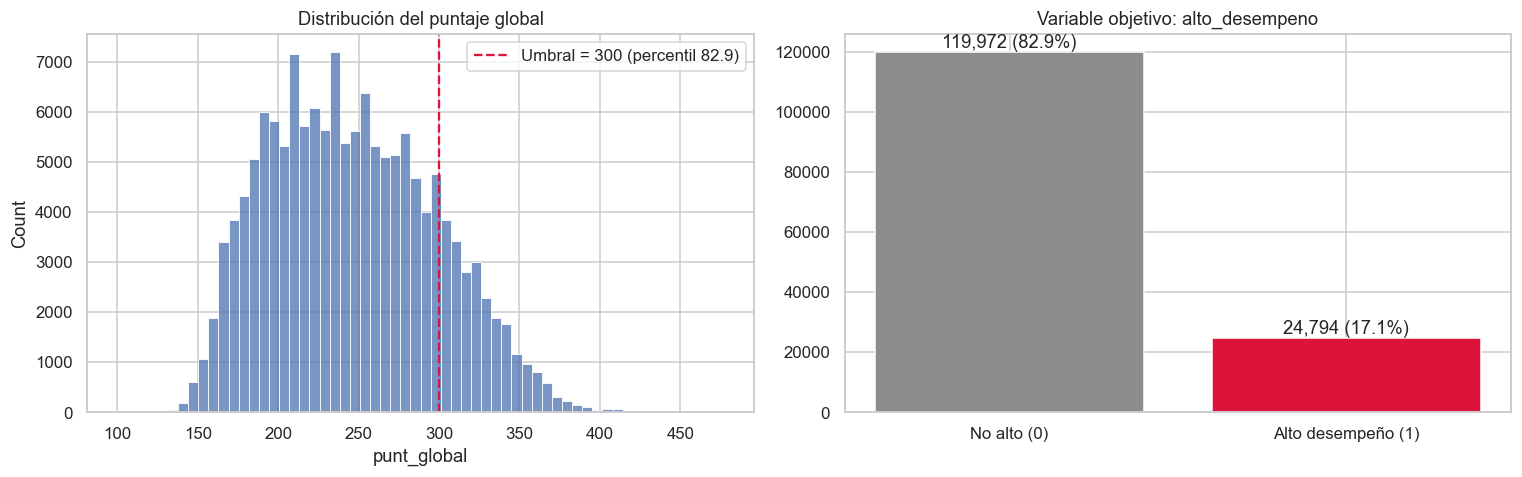

{'count': 144766.0, 'mean': 245.9, 'std': 51.59, 'min': 100.0, '25%': 205.0, '50%': 242.0, '75%': 283.0, 'max': 477.0} | asimetría: 0.312


In [10]:
# 2.3 Distribución del puntaje global y de la clase binaria derivada del umbral de 300
punt = df_raw["punt_global"].dropna()   # Se excluyen los nulos solo para describir la distribución
# kind="strict": % de estudiantes con puntaje estrictamente menor que 300
percentil_umbral = stats.percentileofscore(punt, UMBRAL_ALTO_DESEMPENO, kind="strict")
clase_eda = np.where(punt >= UMBRAL_ALTO_DESEMPENO, "Alto desempeño (1)", "No alto (0)")   # Discretización
conteo = pd.Series(clase_eda).value_counts().reindex(["No alto (0)", "Alto desempeño (1)"])   # Orden fijo para el gráfico

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))
# Izquierda: histograma del puntaje continuo con el umbral marcado
sns.histplot(punt, bins=60, ax=ejes[0], color="#4C72B0")
ejes[0].axvline(UMBRAL_ALTO_DESEMPENO, color="crimson", ls="--",
                label=f"Umbral = {UMBRAL_ALTO_DESEMPENO} (percentil {percentil_umbral:.1f})")
ejes[0].set_title("Distribución del puntaje global"); ejes[0].set_xlabel("punt_global"); ejes[0].legend()
# Derecha: conteo de cada clase con su porcentaje (evidencia el desbalance)
ejes[1].bar(conteo.index, conteo.values, color=["#8C8C8C", "crimson"])
for i, v in enumerate(conteo.values):
    ejes[1].text(i, v, f"{v:,} ({v / conteo.sum():.1%})", ha="center", va="bottom")   # Etiqueta sobre cada barra
ejes[1].set_title("Variable objetivo: alto_desempeno")
plt.tight_layout(); guardar_figura("distribucion_objetivo"); plt.show()

# Asimetría > 0: cola larga hacia puntajes altos (pocos estudiantes con puntajes muy altos)
print(punt.describe().round(2).to_dict(), "| asimetría:", round(stats.skew(punt), 3))

🔎 **Interpretación:** El puntaje global tiene media 245,9, mediana 242 y desviación 51,6, con una ligera asimetría positiva (0,31): pocos estudiantes alcanzan puntajes muy altos.
El umbral de 300 queda en el **percentil 82,9**, así que el 17,1 % de los evaluados es "alto desempeño" (24.794 de 144.766 filas, antes de quitar duplicados). Es el **desbalance** anticipado en el 📘: un modelo que siempre dijera "no alto" acertaría el 82,9 % de las veces sin ninguna utilidad. Por eso la métrica principal es F1 y en 3.8 se evalúa el balanceo.

### 2.4 Posibles sesgos en los datos

#### 📘 Concepto: Sesgos en los datos
Un **sesgo** es una distorsión sistemática que hace que los datos o el modelo representen mal a ciertos grupos.
Fuentes relevantes aquí (Suresh y Guttag, 2021):

| Tipo | Qué es | Riesgo en este proyecto |
|---|---|---|
| **Representación** | Algunos grupos tienen pocos registros | Colegios rurales o de jornada nocturna subrepresentados |
| **Selección** | Los datos no son una muestra aleatoria de la población | Solo aparecen quienes llegaron a grado 11 y presentaron el examen |
| **Histórico** | Los datos reflejan desigualdades existentes | El modelo aprende la brecha socioeconómica y puede perpetuarla |
| **Temporal** | Las condiciones cambian entre cohortes | 2022-2 es una cohorte pospandemia |

Detectarlos antes de modelar permite interpretar bien los resultados. En la fase 5 se audita el desempeño del modelo por grupo.

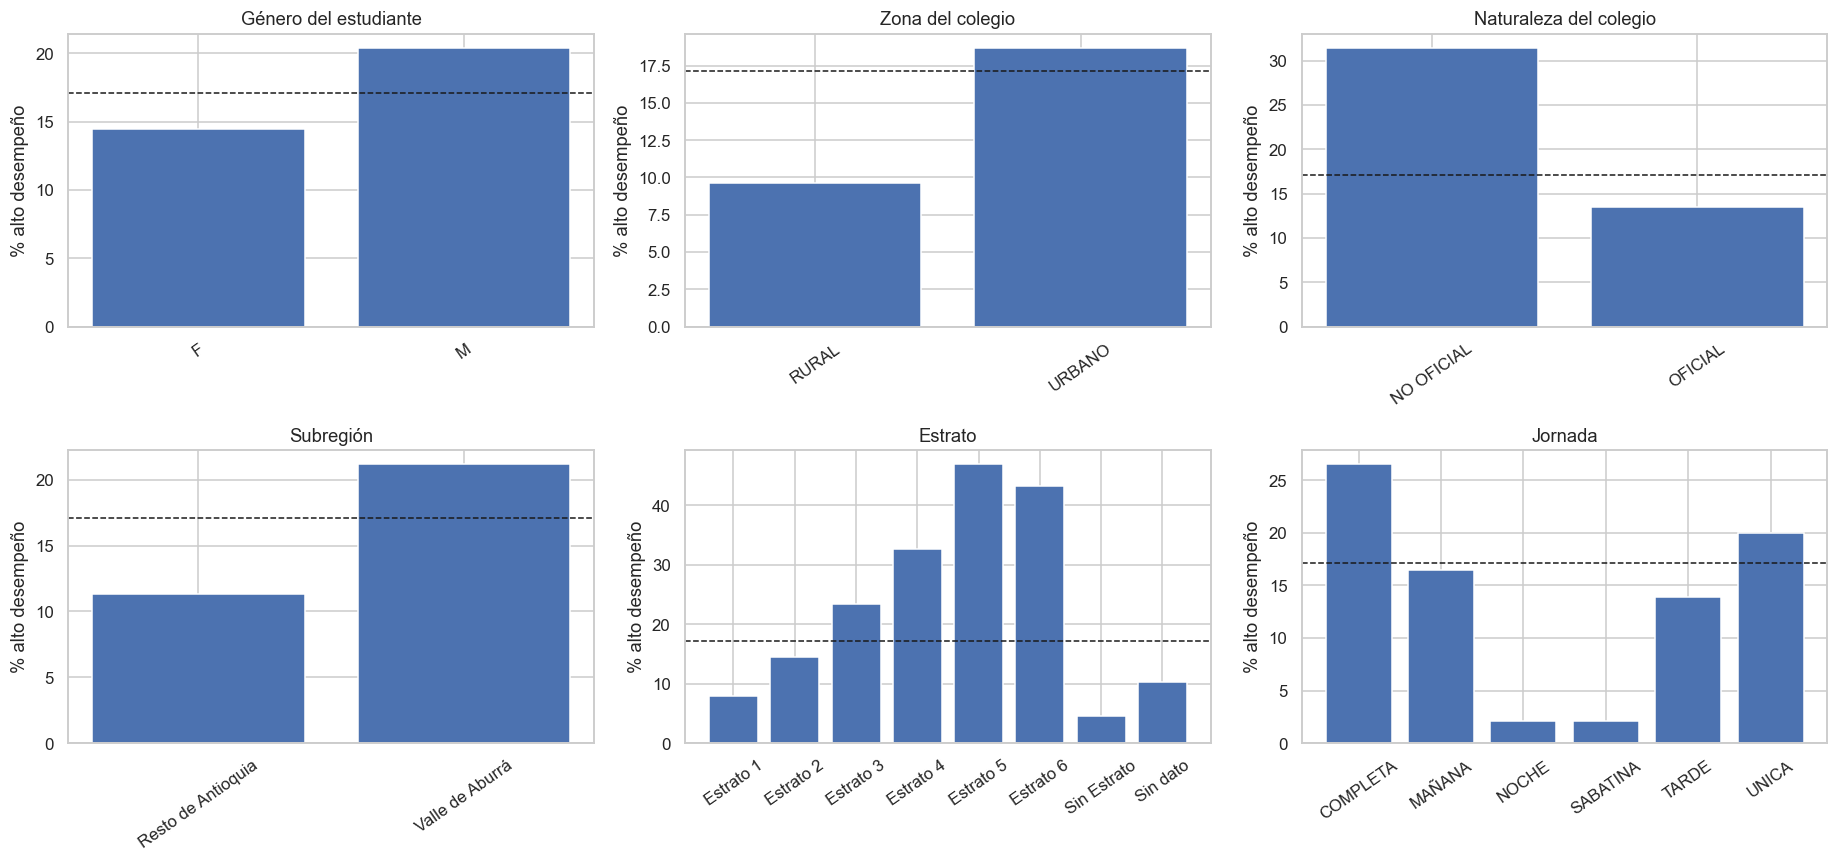

,variable,grupo,registros,pct_registros,tasa_alto_desempeno_pct
0,Género del estudiante,F,80022,55.2800,14.4700
1,Género del estudiante,M,64744,44.7200,20.4100
2,Zona del colegio,RURAL,25078,17.3200,9.6300
3,Zona del colegio,URBANO,119688,82.6800,18.7000
4,Naturaleza del colegio,NO OFICIAL,29506,20.3800,31.4500
5,Naturaleza del colegio,OFICIAL,115260,79.6200,13.4600
6,Subregión,Resto de Antioquia,59472,41.0800,11.3400
7,Subregión,Valle de Aburrá,85294,58.9200,21.1600
8,Estrato,Estrato 1,28346,19.5800,7.9100
9,Estrato,Estrato 2,53304,36.8200,14.5100


In [11]:
# 2.4 Representación de grupos y tasa de alto desempeño por grupo (sesgo de representación e inequidad de base)
df_eda = df_raw.loc[df_raw["punt_global"].notna()].copy()   # Solo registros con objetivo definido
# Subregión: área metropolitana (Valle de Aburrá) frente al resto de Antioquia
df_eda["cole_valle_aburra"] = np.where(df_eda["cole_cod_mcpio_ubicacion"].isin(CODIGOS_VALLE_ABURRA),
                                       "Valle de Aburrá", "Resto de Antioquia")
df_eda["alto"] = (df_eda["punt_global"] >= UMBRAL_ALTO_DESEMPENO).astype(int)   # 1 = alto desempeño
GRUPOS_SESGO = {"estu_genero": "Género del estudiante", "cole_area_ubicacion": "Zona del colegio",
                "cole_naturaleza": "Naturaleza del colegio", "cole_valle_aburra": "Subregión",
                "fami_estratovivienda": "Estrato", "cole_jornada": "Jornada"}

filas = []
for var, titulo in GRUPOS_SESGO.items():
    # size = registros del grupo (representación); mean de una variable 0/1 = tasa de alto desempeño
    grupos = df_eda.groupby(df_eda[var].fillna("Sin dato"))["alto"].agg(["size", "mean"])
    for grupo, fila in grupos.iterrows():
        filas.append({"variable": titulo, "grupo": grupo, "registros": int(fila["size"]),
                      "pct_registros": 100 * fila["size"] / len(df_eda), "tasa_alto_desempeno_pct": 100 * fila["mean"]})
tabla_sesgos = guardar_tabla(pd.DataFrame(filas).round(2), "sesgos")

fig, ejes = plt.subplots(2, 3, figsize=(17, 8))
for eje, (titulo, sub) in zip(ejes.flat, tabla_sesgos.groupby("variable", sort=False)):   # Un panel por variable
    eje.bar(sub["grupo"].astype(str), sub["tasa_alto_desempeno_pct"], color="#4C72B0")
    eje.axhline(100 * df_eda["alto"].mean(), ls="--", color="k", lw=1)   # Tasa global como referencia
    eje.set_title(titulo); eje.set_ylabel("% alto desempeño"); eje.tick_params(axis="x", rotation=35)
plt.tight_layout(); guardar_figura("sesgos_por_grupo"); plt.show()
tabla_sesgos

🔎 **Interpretación:** Las tasas se calculan sobre el archivo original. Los conteos están duplicados, pero los porcentajes no cambian, porque cada registro se repite exactamente dos veces. La tabla muestra **inequidades de base** marcadas:
- **Estrato:** la tasa de alto desempeño pasa de 7,9 % (estrato 1) a 46,9 % (estrato 5). "Sin estrato" solo llega al 4,6 %.
- **Naturaleza y subregión:** 31,5 % en colegios no oficiales frente a 13,5 % en oficiales; 21,2 % en el Valle de Aburrá frente a 11,3 % en el resto de Antioquia.
- **Jornada:** en las jornadas nocturna y sabatina (jóvenes y adultos) la tasa es de apenas 2,1 %.
- **Representación:** los colegios rurales (17 %) y las jornadas nocturna y sabatina (15 % entre ambas) son minoría.

Estas diferencias son un **sesgo histórico** (📘): el modelo las aprenderá. Por eso en la fase 5 se audita su desempeño por grupo.

### 🧠 Para profundizar — Fase 2: Entendimiento de los datos
**Ideas clave**
- Antes de transformar nada hay que **documentar** (diccionario) y **medir** (reglas de calidad) los datos.
- La fuga de información es el error más costoso de un proyecto predictivo: se previene decidiendo el rol de cada variable.
- El desbalance de la variable objetivo condiciona la métrica, el balanceo y la lectura de los resultados.
- Los sesgos se identifican en los datos antes de que aparezcan amplificados en el modelo.

**Preguntas de repaso**
1. ¿Por qué `punt_matematicas` es fuga de información y `fami_estratovivienda` no lo es?
2. ¿Qué diferencia hay entre una regla de validez y una de consistencia? Da un ejemplo de cada una con estos datos.
3. Si la tasa de alto desempeño es muy distinta entre colegios oficiales y no oficiales, ¿eso prueba que la naturaleza del colegio *causa* el desempeño?

**Ejercicios**
- Agrega una regla de consistencia: `punt_global` debería ser cercano a la combinación ponderada de los puntajes por área. Mide su incumplimiento.
- Repite la tabla de sesgos para `cole_caracter` y comenta si hay grupos subrepresentados (< 1 % de los registros).

**Referencias**
- Wang, R. Y. y Strong, D. M. (1996). Beyond accuracy: What data quality means to data consumers. *Journal of Management Information Systems*, 12(4), 5–33.
- Kaufman, S., Rosset, S., Perlich, C. y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM TKDD*, 6(4).
- Suresh, H. y Guttag, J. (2021). A framework for understanding sources of harm throughout the machine learning life cycle. *EAAMO '21*.
- He, H. y Garcia, E. A. (2009). Learning from imbalanced data. *IEEE TKDE*, 21(9), 1263–1284.
- Documentación de la API Socrata (SODA): https://dev.socrata.com/

## 3. Preparación de los datos
### 3.1 Selección de variables

#### 📘 Concepto: Selección de variables
Seleccionar variables reduce ruido, costo y riesgo de fuga. Hay tres familias de métodos:
- **Por conocimiento del dominio:** se eligen variables con relación plausible con el objetivo y **disponibles al predecir**. Es el método principal aquí.
- **De filtro:** se descartan variables constantes, identificadores y redundantes, o se ordenan por una medida estadística (χ², información mutua; ver 3.6).
- **Envolventes o embebidos:** el propio modelo elige (p. ej. regularización L1, importancia en árboles).

Además se **construyen** variables (*feature engineering*): `edad` a partir de la fecha de nacimiento y `cole_valle_aburra`
a partir del código de municipio. Esto último reduce una variable de ~125 categorías (alta cardinalidad) a un indicador binario.

In [12]:
# 3.1 Conjunto de trabajo: variables seleccionadas + las dos derivadas (edad y Valle de Aburrá)
# Las 17 variables originales que entran al modelo (las otras 2 de FEATURES se construyen aquí)
VARS_ORIGINALES_SELECCIONADAS = [v for v in FEATURES if v not in ("edad", "cole_valle_aburra")]

# Se conservan también el estado del resultado (para filtrar) y el puntaje global (para construir el objetivo)
df_sel = df_raw[VARS_ORIGINALES_SELECCIONADAS + ["estu_estadoinvestigacion", "punt_global"]].copy()
df_sel["edad"] = calcular_edad(df_raw["estu_fechanacimiento"])                  # Derivada: edad en años cumplidos
df_sel["cole_valle_aburra"] = np.where(                                         # Derivada: área metropolitana
    df_raw["cole_cod_mcpio_ubicacion"].isin(CODIGOS_VALLE_ABURRA), "Sí", "No")
df_sel = df_sel[FEATURES + ["estu_estadoinvestigacion", "punt_global"]]         # Orden de columnas estable

# Justificación de dominio de cada variable seleccionada (tabla 3.1 del informe)
JUSTIFICACION_SELECCION = {
    "edad": "Derivada de la fecha de nacimiento; la extraedad se asocia con rezago escolar",
    "estu_genero": "Brechas de género documentadas en pruebas estandarizadas; permite auditar sesgo",
    "fami_estratovivienda": "Proxy del nivel socioeconómico del hogar",
    "fami_educacionmadre": "Capital cultural del hogar; predictor clásico del logro académico",
    "fami_educacionpadre": "Capital cultural del hogar",
    "fami_personashogar": "Tamaño del hogar (recursos per cápita)",
    "fami_cuartoshogar": "Condiciones de la vivienda (hacinamiento)",
    "fami_tieneinternet": "Acceso a recursos digitales de estudio",
    "fami_tienecomputador": "Acceso a recursos digitales de estudio",
    "fami_tieneautomovil": "Proxy de ingreso del hogar",
    "fami_tienelavadora": "Proxy de condiciones materiales del hogar",
    "cole_naturaleza": "Oficial vs. privado: diferencias de recursos y de selección de estudiantes",
    "cole_jornada": "Intensidad horaria y tipo de población (sabatina/noche = jóvenes y adultos)",
    "cole_area_ubicacion": "Brecha urbano-rural",
    "cole_bilingue": "Intensidad en inglés y recursos del colegio",
    "cole_caracter": "Orientación académica vs. técnica",
    "cole_genero": "Composición del colegio (mixto, femenino, masculino)",
    "cole_sede_principal": "Las sedes principales suelen concentrar más recursos",
    "cole_valle_aburra": "Resume 125 municipios en un indicador área metropolitana vs. resto de Antioquia",
}
tabla_seleccion = guardar_tabla(pd.DataFrame({"variable": FEATURES,
                                              "justificacion": [JUSTIFICACION_SELECCION[v] for v in FEATURES]}),
                                "seleccion_variables")
print(f"Variables de entrada: {len(FEATURES)} (numéricas: {len(VARIABLES_NUMERICAS)}, "
      f"ordinales: {len(VARIABLES_ORDINALES)}, nominales: {len(VARIABLES_NOMINALES)})")
tabla_seleccion

Variables de entrada: 19 (numéricas: 1, ordinales: 5, nominales: 13)


,variable,justificacion
0,edad,Derivada de la fecha de nacimiento; la extraed...
1,fami_estratovivienda,Proxy del nivel socioeconómico del hogar
2,fami_educacionmadre,Capital cultural del hogar; predictor clásico ...
3,fami_educacionpadre,Capital cultural del hogar
4,fami_personashogar,Tamaño del hogar (recursos per cápita)
5,fami_cuartoshogar,Condiciones de la vivienda (hacinamiento)
6,estu_genero,Brechas de género documentadas en pruebas esta...
7,fami_tieneinternet,Acceso a recursos digitales de estudio
8,fami_tienecomputador,Acceso a recursos digitales de estudio
9,fami_tieneautomovil,Proxy de ingreso del hogar


🔎 **Interpretación:** Quedan 19 variables de entrada: 1 numérica (`edad`), 5 ordinales del hogar y 13 nominales del estudiante, el hogar y el colegio. Cada una tiene su justificación de dominio.
Las dos variables **construidas** muestran el valor del *feature engineering*:
- `edad` convierte una fecha de texto en una cantidad con sentido educativo (extraedad = rezago escolar).
- `cole_valle_aburra` resume 125 municipios (alta cardinalidad) en un indicador binario interpretable.

### 3.2 Descripción estadística y reporte exploratorio (ydata-profiling)

In [13]:
# 3.2.1 Descripción estadística del conjunto seleccionado (antes de limpiar, para evidenciar problemas)
df_perfil = df_sel[FEATURES + ["punt_global"]]   # Variables de entrada + el puntaje del que sale el objetivo
# Tabla 3.2 del informe: tamaño del conjunto y tipos de variables
tabla_descripcion = guardar_tabla(pd.DataFrame({
    "metrica": ["Número de registros", "Número de variables", "Variables numéricas", "Variables categóricas"],
    "resultado": [f"{len(df_perfil):,}", f"{df_perfil.shape[1]} ({len(FEATURES)} de entrada + punt_global)",
                  "2 (edad, punt_global)",
                  f"{len(VARIABLES_ORDINALES) + len(VARIABLES_NOMINALES)} "
                  f"({len(VARIABLES_ORDINALES)} ordinales + {len(VARIABLES_NOMINALES)} nominales)"]}),
    "descripcion_estadistica")
display(tabla_descripcion)
# include="all": numéricas (media, desviación, cuartiles) y categóricas (únicos, moda y su frecuencia)
df_perfil.describe(include="all").T

,metrica,resultado
0,Número de registros,"144,766"
1,Número de variables,20 (19 de entrada + punt_global)
2,Variables numéricas,"2 (edad, punt_global)"
3,Variables categóricas,18 (5 ordinales + 13 nominales)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,144766.0000,NaN,NaN,NaN,17.4833,3.4302,0.0000,16.0000,17.0000,18.0000,79.0000
fami_estratovivienda,135322,7,Estrato 2,53304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_educacionmadre,136374,12,Secundaria (Bachillerato) completa,39854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_educacionpadre,136232,12,Secundaria (Bachillerato) completa,32312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_personashogar,138158,5,3 a 4,77258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_cuartoshogar,137944,6,Tres,56286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estu_genero,144766,2,F,80022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_tieneinternet,136252,2,Si,106744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_tienecomputador,137940,2,Si,85188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_tieneautomovil,137554,2,No,105056,NaN,NaN,NaN,NaN,NaN,NaN,NaN


🔎 **Interpretación:** El conjunto seleccionado tiene 144.766 registros y 20 variables (19 de entrada más el puntaje global): 2 numéricas y 18 categóricas.
La descripción confirma lo visto en la fase 2: las categorías más frecuentes son estrato 2, madre con bachillerato completo, colegio oficial y jornada de la mañana. La edad tiene media 17,5 años, pero un **mínimo de 0**, evidencia directa de fechas erróneas. Estos datos todavía no se han limpiado a propósito: el perfilamiento debe documentar el estado original.

#### 📘 Concepto: Perfilamiento automático
Un **perfilamiento** (*data profiling*) resume de forma sistemática cada variable. **ydata-profiling** genera un reporte
HTML con:
- Tipo inferido, % de faltantes, cardinalidad, valores más frecuentes e histogramas.
- **Alertas**: alta correlación, desbalance, valores constantes, duplicados y ceros.
- Matrices de correlación (Pearson, Spearman, Cramér, φK) y diagramas de faltantes.

No reemplaza el análisis del científico de datos, pero lo acelera y deja evidencia auditable. Se ejecuta **antes de
limpiar** para documentar el estado original de los datos.

In [14]:
# 3.2.2 Reporte exploratorio automático con ydata-profiling (se adjunta como HTML al informe)
import os
os.environ["TQDM_DISABLE"] = "1"   # Oculta las barras de progreso internas de la librería (no aportan al análisis)

inicio = time.time()
with warnings.catch_warnings():    # Silencia solo aquí los avisos internos de la librería (deprecación, copias de pandas)
    warnings.simplefilter("ignore")
    from ydata_profiling import ProfileReport   # Import local: la librería es pesada y solo se usa aquí
    # interactions desactivado: los diagramas de dispersión por pares cuestan O(p²) y aportan poco con variables categóricas
    perfil = ProfileReport(df_perfil, title="Saber 11 · Antioquia 2022-2 · Variables seleccionadas",
                           interactions={"continuous": False}, progress_bar=False)
    RUTA_PERFIL = DIR_REPORTES / "perfilamiento_saber11_antioquia.html"
    perfil.to_file(RUTA_PERFIL)   # Entregable exigido por la actividad
print(f"Reporte: {RUTA_PERFIL.name} ({RUTA_PERFIL.stat().st_size / 1e6:.1f} MB) en {time.time() - inicio:.0f} s")

Reporte: perfilamiento_saber11_antioquia.html (1.8 MB) en 50 s


🔎 **Interpretación:** Se generó `reports/perfilamiento_saber11_antioquia.html` (1,8 MB, en menos de un minuto). Contiene, por variable, histogramas, faltantes, cardinalidad y alertas, además de las matrices de correlación.
Al importarla, la librería emite un aviso de deprecación (silenciado en la celda): ydata-profiling dejará de actualizarse en favor de `fg-data-profiling`. Se mantiene porque la actividad lo exige explícitamente, y es una buena lección sobre el ciclo de vida de las librerías de código abierto. **Recomendación de estudio:** abre el HTML y compara sus alertas de desbalance y faltantes con lo que encontramos manualmente en la fase 2.

### 3.3 Limpieza de errores

#### 📘 Concepto: Limpieza determinística
Hay dos clases de transformaciones y el **momento** en que se aplican importa:

| Tipo | Ejemplo | ¿Aprende de los datos? | Cuándo aplicarla |
|---|---|---|---|
| **Determinística** | Eliminar duplicados, corregir tildes, marcar edades imposibles | No: la regla es fija | Antes de partir los datos |
| **Aprendida** | Imputar con la mediana, escalar, codificar, SMOTE | Sí: calcula estadísticos | **Dentro del pipeline**, ajustada solo con entrenamiento |

Si una transformación aprendida se ajusta con todos los datos, la información del conjunto de prueba "se filtra" al
entrenamiento y las métricas quedan optimistas. Las reglas determinísticas no tienen ese problema: dan el mismo resultado
para un registro sin importar los demás.

In [15]:
# 3.3 Reglas determinísticas (no aprenden de los datos), por eso se aplican antes de la partición
# Variantes de escritura conocidas -> valor canónico (se amplía si la tabla 2.2.2 muestra otras)
HOMOLOGACIONES = {"fami_cuartoshogar": {"Seis o más": "Seis o mas"}, "fami_personashogar": {"9 o mas": "9 o más"}}
df_limpio = df_sel.copy()   # Se trabaja sobre una copia para conservar df_sel como evidencia del estado original
registro = []               # Bitácora de cada regla: (error, acción, registros afectados) -> tabla 3.3 del informe

# (a) Duplicados exactos detectados con las 51 columnas originales (dos estudiantes pueden compartir el mismo perfil)
mascara = df_raw.loc[df_limpio.index].duplicated(keep="first")
df_limpio = df_limpio.loc[~mascara]
registro.append(("Filas duplicadas exactas (51 columnas)", "Eliminadas; se conserva la primera ocurrencia", int(mascara.sum())))

# (b) Resultados no oficiales: el ICFES los marca con un estado distinto de PUBLICAR
mascara = df_limpio["estu_estadoinvestigacion"] != "PUBLICAR"
df_limpio = df_limpio.loc[~mascara]
registro.append(("Resultado en investigación", "Eliminados: el puntaje no es oficial", int(mascara.sum())))

# (c) Puntaje global ausente o fuera de [0, 500]: sin él no hay variable objetivo confiable
mascara = df_limpio["punt_global"].isna() | ~df_limpio["punt_global"].between(0, 500)
df_limpio = df_limpio.loc[~mascara]
registro.append(("Puntaje global nulo o fuera de [0, 500]", "Eliminados: no se puede construir el objetivo", int(mascara.sum())))

# (d) Edad imposible: no se elimina el registro (el resto de su información es válida); se marca como faltante
mascara = df_limpio["edad"].notna() & ~df_limpio["edad"].between(13, 30)
df_limpio.loc[mascara, "edad"] = np.nan
registro.append(("Edad fuera de [13, 30]", "Convertida a NaN (imputación por mediana en el pipeline)", int(mascara.sum())))

# (e) Texto: espacios sobrantes y variantes de escritura; (f) valores fuera del dominio válido -> NaN
total_invalidas = 0
for var, validas in CATEGORIAS_VALIDAS.items():
    df_limpio[var] = df_limpio[var].str.strip().replace(HOMOLOGACIONES.get(var, {}))   # Normaliza antes de validar
    mascara = df_limpio[var].notna() & ~df_limpio[var].isin(validas)                   # Valores que siguen siendo inválidos
    total_invalidas += int(mascara.sum())
    df_limpio.loc[mascara, var] = np.nan
registro.append(("Categorías fuera del dominio válido", "Homologadas si son variantes; si no, NaN", total_invalidas))

# Construcción de la variable objetivo (regla de negocio de la fase 1)
df_limpio[OBJETIVO] = (df_limpio["punt_global"] >= UMBRAL_ALTO_DESEMPENO).astype(int)
tabla_errores = guardar_tabla(pd.DataFrame(registro, columns=["tipo_error", "accion", "registros_afectados"]),
                              "limpieza_errores")
print(f"Registros: {len(df_sel):,} -> {len(df_limpio):,}")
tabla_errores

Registros: 144,766 -> 72,357


,tipo_error,accion,registros_afectados
0,Filas duplicadas exactas (51 columnas),Eliminadas; se conserva la primera ocurrencia,72383
1,Resultado en investigación,Eliminados: el puntaje no es oficial,26
2,"Puntaje global nulo o fuera de [0, 500]",Eliminados: no se puede construir el objetivo,0
3,"Edad fuera de [13, 30]",Convertida a NaN (imputación por mediana en el...,1126
4,Categorías fuera del dominio válido,"Homologadas si son variantes; si no, NaN",0


🔎 **Interpretación:** La limpieza pasa de 144.766 a **72.357 registros**:
- Se eliminan 72.383 duplicados exactos y 26 resultados no oficiales.
- Ningún puntaje estaba nulo ni fuera de rango.
- 1.126 edades imposibles pasan a faltante (la mitad de las 2.252 detectadas, por los duplicados).
- Ninguna categoría estaba fuera de dominio.

Es el caso típico de **limpieza determinística** (📘): cada regla da el mismo resultado para un registro sin mirar los demás, así que se puede aplicar antes de partir los datos sin riesgo de fuga. La tabla es la 3.3 del informe.

In [16]:
# 3.3.1 Verificación automática: las reglas de calidad se cumplen después de limpiar
# Los assert detienen el cuaderno si alguna regla falla: la limpieza se prueba, no se supone
assert not df_raw.loc[df_limpio.index].duplicated().any(), "Persisten duplicados"
assert (df_limpio["estu_estadoinvestigacion"] == "PUBLICAR").all()     # Solo resultados oficiales
assert df_limpio["punt_global"].between(0, 500).all()                   # Objetivo válido en todas las filas
assert df_limpio["edad"].dropna().between(13, 30).all()                 # Edades plausibles (los NaN se imputarán)
for var, validas in CATEGORIAS_VALIDAS.items():
    assert df_limpio[var].dropna().isin(validas).all(), var            # Dominios categóricos respetados
print("Todas las reglas de calidad se cumplen en df_limpio")

Todas las reglas de calidad se cumplen en df_limpio


🔎 **Interpretación:** Todas las aserciones pasan: no quedan duplicados, solo hay resultados oficiales, el objetivo es válido en todas las filas, las edades son plausibles y las categorías están dentro de su dominio.
Convertir las reglas de calidad en `assert` es una práctica de **pruebas de datos**. Si la fuente cambiara y reapareciera un problema, el cuaderno se detendría aquí en lugar de entrenar un modelo con datos defectuosos.

### 3.4 Limpieza de valores nulos

#### 📘 Concepto: Valores faltantes
Rubin (1976) clasifica los faltantes según su **mecanismo**:
- **MCAR** (completamente al azar): la ausencia no depende de nada. Eliminar filas no sesga, pero pierde información.
- **MAR** (al azar condicionado): la ausencia depende de otras variables observadas. Se puede imputar usándolas.
- **MNAR** (no al azar): la ausencia depende del propio valor faltante. Por ejemplo, quien no reporta el estrato puede tener
  un perfil socioeconómico particular.

Estrategias usadas aquí:
- **Imputación por mediana:** robusta a valores extremos (numéricas y ordinales).
- **Indicador de faltante:** columna 0/1 que permite al modelo aprender si "no tener dato" es informativo (útil en MNAR).
- **Categoría explícita `DESCONOCIDO`:** para nominales; conserva la señal del faltante sin inventar un valor.

Toda imputación **aprende** un estadístico, así que va dentro del pipeline (ver 3.3).

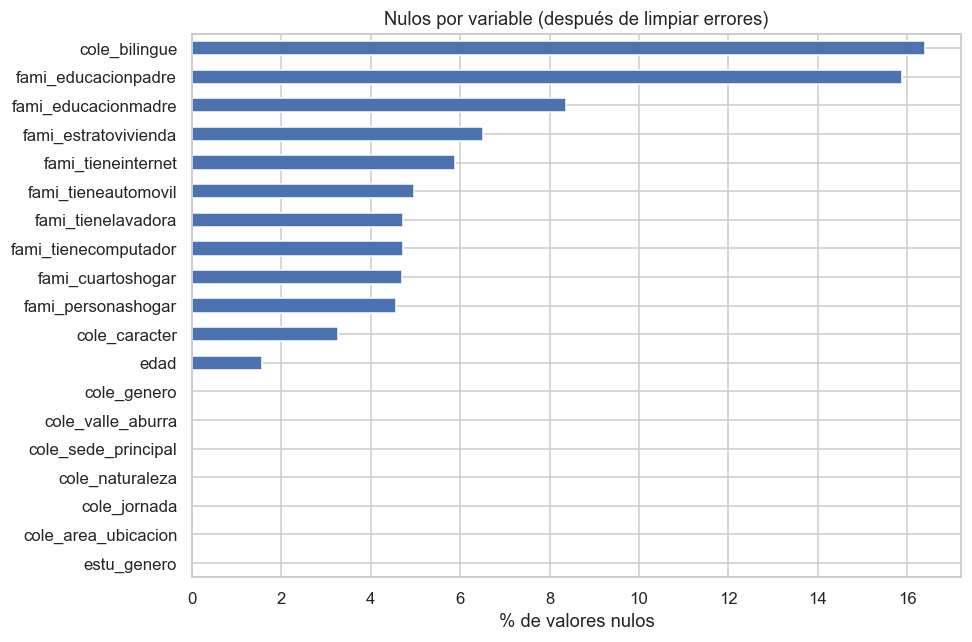

,variable,pct_nulos,metodo
14,cole_bilingue,16.3900,Categoría explícita 'DESCONOCIDO' (pipeline)
3,fami_educacionpadre,15.8800,Mediana del código ordinal + indicador de falt...
2,fami_educacionmadre,8.3600,Mediana del código ordinal + indicador de falt...
1,fami_estratovivienda,6.5200,Mediana del código ordinal + indicador de falt...
7,fami_tieneinternet,5.8800,Categoría explícita 'DESCONOCIDO' (pipeline)
9,fami_tieneautomovil,4.9800,Categoría explícita 'DESCONOCIDO' (pipeline)
10,fami_tienelavadora,4.7300,Categoría explícita 'DESCONOCIDO' (pipeline)
8,fami_tienecomputador,4.7200,Categoría explícita 'DESCONOCIDO' (pipeline)
5,fami_cuartoshogar,4.7100,Mediana del código ordinal + indicador de falt...
4,fami_personashogar,4.5600,Mediana del código ordinal + indicador de falt...


In [17]:
# 3.4 Respuestas no informativas -> NaN y diagnóstico del % de faltantes (la imputación ocurre en el pipeline)
# "No sabe" / "No Aplica" no son un nivel educativo: no tienen lugar en la escala ordinal, así que son faltantes
for var in ["fami_educacionmadre", "fami_educacionpadre"]:
    df_limpio[var] = df_limpio[var].replace(["No sabe", "No Aplica"], np.nan)

# Método de imputación por tipo de variable (tabla 3.4 del informe); los ** fusionan los tres diccionarios
METODO_IMPUTACION = {**{v: "Mediana (SimpleImputer dentro del pipeline)" for v in VARIABLES_NUMERICAS},
                     **{v: "Mediana del código ordinal + indicador de faltante (pipeline)" for v in VARIABLES_ORDINALES},
                     **{v: "Categoría explícita 'DESCONOCIDO' (pipeline)" for v in VARIABLES_NOMINALES}}
pct_nulos = (df_limpio[FEATURES].isna().mean() * 100).round(2)   # isna().mean() = proporción de faltantes
tabla_nulos = guardar_tabla(pd.DataFrame({"variable": FEATURES, "pct_nulos": pct_nulos.values,
                                          "metodo": [METODO_IMPUTACION[v] for v in FEATURES]})
                            .sort_values("pct_nulos", ascending=False), "limpieza_nulos")

fig, eje = plt.subplots(figsize=(9, 6))
pct_nulos.sort_values().plot.barh(ax=eje, color="#4C72B0")   # Barras horizontales ordenadas: fácil de comparar
eje.set_xlabel("% de valores nulos"); eje.set_title("Nulos por variable (después de limpiar errores)")
plt.tight_layout(); guardar_figura("nulos_por_variable"); plt.show()
tabla_nulos

🔎 **Interpretación:** Tras convertir "No sabe" y "No Aplica" en faltantes, los mayores porcentajes de nulos son:

| Variable | % nulos |
|---|---|
| `cole_bilingue` | 16,4 |
| `fami_educacionpadre` | 15,9 (subió desde ~6 % por las respuestas "No sabe") |
| `fami_educacionmadre` | 8,4 |
| `fami_estratovivienda` | 6,5 |
| Tenencias del hogar | entre 4,7 y 5,9 |
| Edad | 1,6 |

Ninguna variable supera el 20 %, así que se **imputan** en lugar de descartarse. La imputación ocurre dentro del pipeline, como indica el 📘.

In [18]:
# 3.4.1 ¿El faltante es informativo? Tasa de alto desempeño con y sin dato (justifica DESCONOCIDO e indicadores)
# Si las tasas difieren mucho, el faltante NO es MCAR: eliminar esas filas sesgaría la muestra
filas = []
for var in pct_nulos[pct_nulos > 1].index:   # Solo variables con más de 1 % de faltantes
    falta = df_limpio[var].isna()
    filas.append({"variable": var, "pct_nulos": pct_nulos[var],
                  "tasa_alto_con_dato_pct": 100 * df_limpio.loc[~falta, OBJETIVO].mean(),
                  "tasa_alto_sin_dato_pct": 100 * df_limpio.loc[falta, OBJETIVO].mean()})
pd.DataFrame(filas).round(2)

,variable,pct_nulos,tasa_alto_con_dato_pct,tasa_alto_sin_dato_pct
0,edad,1.5600,17.3800,0.8000
1,fami_estratovivienda,6.5200,17.6000,10.2900
2,fami_educacionmadre,8.3600,17.3900,14.2900
3,fami_educacionpadre,15.8800,17.3600,15.9100
4,fami_personashogar,4.5600,17.2700,14.1700
5,fami_cuartoshogar,4.7100,17.2700,14.1900
6,fami_tieneinternet,5.8800,17.5800,9.9100
7,fami_tienecomputador,4.7200,17.3000,13.6000
8,fami_tieneautomovil,4.9800,17.3300,13.1800
9,fami_tienelavadora,4.7300,17.3000,13.5300


🔎 **Interpretación:** La prueba es contundente:
- Quienes **no tienen dato de edad** alcanzan alto desempeño solo en el 0,8 % de los casos, frente al 17,4 %.
- Sin estrato reportado, la tasa es 10,3 % frente a 17,6 %; sin dato de internet, 9,9 % frente a 17,6 %.

Los faltantes **no son MCAR**: estar incompleto se asocia a un perfil de menor desempeño, un caso de MNAR/MAR (📘). Eliminar esas filas sesgaría la muestra hacia estudiantes más favorecidos. La categoría `DESCONOCIDO` y los indicadores de faltante permiten que el modelo aproveche esta señal.

In [19]:
# 3.4.2 Guardado del conjunto limpio (insumo reproducible para las fases siguientes)
# index_label="id_registro" conserva la posición original en df_raw: permite rastrear cualquier fila hasta la fuente
df_limpio.to_csv(DIR_PROC / "saber11_antioquia_limpio.csv.gz", index=True, index_label="id_registro", compression="gzip")
print(df_limpio.shape, "| tasa de alto desempeño:", f"{df_limpio[OBJETIVO].mean():.2%}")

(72357, 22) | tasa de alto desempeño: 17.13%


🔎 **Interpretación:** Se guardó el conjunto limpio (72.357 registros × 22 columnas), con una tasa de alto desempeño del 17,13 %: prácticamente la misma que antes de limpiar. La columna `id_registro` conserva la posición original, de modo que cualquier fila puede rastrearse hasta la descarga de la API (**trazabilidad**).

### 3.5 Codificación de variables categóricas

#### 📘 Concepto: Partición entrenamiento/prueba
Para estimar cómo funcionará el modelo con datos **que nunca vio**, se reserva un **conjunto de prueba** (aquí el 30 %)
que no se toca hasta la fase 5. El **entrenamiento** (70 %) se usa para ajustar el preprocesamiento, comparar modelos
con validación cruzada y ajustar hiperparámetros.
- **Estratificar** (`stratify=y`) conserva la proporción de clases (~17/83) en ambos conjuntos. Sin estratificar, un
  conjunto podría quedar con menos positivos por azar.
- **Muestra de modelado:** por costo computacional se modela con 30.000 registros estratificados. El SVM con kernel RBF
  escala entre O(n²) y O(n³). El resto (**pool**) sirve después como datos nunca vistos para validar el despliegue.

In [20]:
# 3.5.1 Muestra de modelado estratificada (30.000) y partición 70/30 estratificada
# train_size con un entero = número exacto de registros; df_pool recibe el resto (nunca participa en el modelado)
df_modelo, df_pool = train_test_split(df_limpio, train_size=N_MUESTRA_MODELADO,
                                      stratify=df_limpio[OBJETIVO], random_state=RANDOM_STATE)
X, y = df_modelo[FEATURES], df_modelo[OBJETIVO]   # X = matriz de entrada; y = vector objetivo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

# Verificación: la tasa de positivos debe ser prácticamente igual en todos los conjuntos (efecto de estratificar)
pd.DataFrame({"conjunto": ["Limpio total", "Muestra de modelado", "Entrenamiento (70 %)", "Prueba (30 %)", "Pool no utilizado"],
              "registros": [len(df_limpio), len(df_modelo), len(X_train), len(X_test), len(df_pool)],
              "pct_alto_desempeno": [100 * s.mean() for s in [df_limpio[OBJETIVO], y, y_train, y_test, df_pool[OBJETIVO]]]}).round(2)

,conjunto,registros,pct_alto_desempeno
0,Limpio total,72357,17.1300
1,Muestra de modelado,30000,17.1300
2,Entrenamiento (70 %),21000,17.1300
3,Prueba (30 %),9000,17.1200
4,Pool no utilizado,42357,17.1300


🔎 **Interpretación:** La estratificación funciona: la tasa de positivos es 17,13 % en todos los conjuntos. Los tamaños quedan así:

| Conjunto | Registros |
|---|---|
| Muestra de modelado | 30.000 |
| Entrenamiento | 21.000 |
| Prueba | 9.000 |
| Pool que no participa en el modelado | 42.357 |

El conjunto de prueba queda "guardado bajo llave" hasta la fase 5, y el pool servirá en la fase 6 como datos reales nunca vistos.

#### 📘 Concepto: Codificación y escalado
Los algoritmos operan con números, así que las categorías deben **codificarse**:

| Técnica | Cómo funciona | Cuándo usarla |
|---|---|---|
| **Ordinal** | Asigna 0, 1, 2… respetando un orden explícito | Categorías con orden natural (estrato, nivel educativo) |
| **One-Hot** | Crea una columna 0/1 por categoría | Categorías **sin** orden (jornada, naturaleza). Codificarlas como 0, 1, 2 inventaría distancias falsas |

El **escalado** (estandarización) $z = \frac{x-\mu}{\sigma}$ pone las variables en la misma escala. Es indispensable
para los modelos basados en distancias o márgenes (KNN, SVM) y para la regresión logística regularizada. A los árboles no
les afecta.

`ColumnTransformer` aplica a cada grupo de columnas su propio `Pipeline` (imputar → codificar → escalar). Al ir dentro del
pipeline del modelo, cada estadístico ($\mu$, $\sigma$, mediana, categorías) se aprende **solo con entrenamiento**.

In [21]:
# 3.5.2 Preprocesamiento por tipo de variable (ColumnTransformer con transformadores nativos de scikit-learn)
# Orden explícito de cada variable ordinal: el primer elemento recibe el código 0, el siguiente 1, etc.
ORDEN_ORDINALES = {
    "fami_estratovivienda": ["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"],
    "fami_educacionmadre": EDUCACION_ORDEN,
    "fami_educacionpadre": EDUCACION_ORDEN,
    "fami_personashogar": ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"],
    "fami_cuartoshogar": ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o mas"],
}
# Numéricas: mediana (robusta a extremos) y luego estandarización z-score
pipe_numerica = Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())])
pipe_ordinal = Pipeline([
    # Categoría no vista o faltante -> NaN, que el paso siguiente imputa (así "No sabe" no rompe la escala)
    ("codificar", OrdinalEncoder(categories=[ORDEN_ORDINALES[v] for v in VARIABLES_ORDINALES],
                                 handle_unknown="use_encoded_value", unknown_value=np.nan)),
    ("imputar", SimpleImputer(strategy="median", add_indicator=True)),   # add_indicator agrega la columna "faltaba"
    ("escalar", StandardScaler())])
pipe_nominal = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value="DESCONOCIDO")),   # El faltante se vuelve una categoría
    # handle_unknown="ignore": una categoría nueva en producción se codifica como todo ceros, sin error
    ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
# Cada tupla: (nombre, transformación, columnas); remainder="drop" descarta cualquier otra columna
preprocesador = ColumnTransformer([("num", pipe_numerica, VARIABLES_NUMERICAS),
                                   ("ord", pipe_ordinal, VARIABLES_ORDINALES),
                                   ("nom", pipe_nominal, VARIABLES_NOMINALES)], remainder="drop")

# Método de codificación por variable (tabla 3.5 del informe)
METODO_CODIFICACION = {
    **{v: "Numérica: imputación por mediana + estandarización (z-score)" for v in VARIABLES_NUMERICAS},
    **{v: f"Ordinal con orden explícito ({ORDEN_ORDINALES[v][0]} < … < {ORDEN_ORDINALES[v][-1]}) + indicador de faltante + estandarización"
       for v in VARIABLES_ORDINALES},
    **{v: "One-Hot Encoding (una columna por categoría, incluida DESCONOCIDO)" for v in VARIABLES_NOMINALES}}
tabla_codificacion = guardar_tabla(pd.DataFrame({"variable": FEATURES, "metodo": [METODO_CODIFICACION[v] for v in FEATURES]}),
                                   "codificacion")
tabla_codificacion

,variable,metodo
0,edad,Numérica: imputación por mediana + estandariza...
1,fami_estratovivienda,Ordinal con orden explícito (Sin Estrato < … <...
2,fami_educacionmadre,Ordinal con orden explícito (Ninguno < … < Pos...
3,fami_educacionpadre,Ordinal con orden explícito (Ninguno < … < Pos...
4,fami_personashogar,Ordinal con orden explícito (1 a 2 < … < 9 o m...
5,fami_cuartoshogar,Ordinal con orden explícito (Uno < … < Seis o ...
6,estu_genero,"One-Hot Encoding (una columna por categoría, i..."
7,fami_tieneinternet,"One-Hot Encoding (una columna por categoría, i..."
8,fami_tienecomputador,"One-Hot Encoding (una columna por categoría, i..."
9,fami_tieneautomovil,"One-Hot Encoding (una columna por categoría, i..."


🔎 **Interpretación:** La tabla resume la estrategia de codificación por tipo de variable (tabla 3.5 del informe):
- **Edad:** mediana y estandarización.
- **5 ordinales:** código ordinal con orden explícito (p. ej. "Sin Estrato" < "Estrato 1" < … < "Estrato 6"), indicador de faltante y estandarización.
- **13 nominales:** One-Hot con la categoría `DESCONOCIDO`.

El `ColumnTransformer` no se ha ajustado todavía: es una "receta" que cada pipeline aprenderá **solo con sus datos de entrenamiento**.

In [22]:
# 3.5.3 Ajuste del preprocesamiento SOLO con entrenamiento y vista de la matriz codificada
# clone crea una copia sin entrenar: el objeto "preprocesador" original queda limpio para usarlo dentro de los pipelines
preprocesador_demo = clone(preprocesador).fit(X_train)
X_train_cod = pd.DataFrame(preprocesador_demo.transform(X_train),
                           columns=preprocesador_demo.get_feature_names_out(),   # Nombres tipo "nom__cole_jornada_MAÑANA"
                           index=X_train.index)
print(f"Variables originales: {X_train.shape[1]} -> variables codificadas: {X_train_cod.shape[1]}")
X_train_cod.head()   # Numéricas y ordinales estandarizadas; nominales como columnas 0/1

Variables originales: 19 -> variables codificadas: 50


,num__edad,ord__fami_estratovivienda,ord__fami_educacionmadre,ord__fami_educacionpadre,ord__fami_personashogar,ord__fami_cuartoshogar,ord__missingindicator_fami_estratovivienda,ord__missingindicator_fami_educacionmadre,ord__missingindicator_fami_educacionpadre,ord__missingindicator_fami_personashogar,ord__missingindicator_fami_cuartoshogar,nom__estu_genero_F,nom__estu_genero_M,nom__fami_tieneinternet_DESCONOCIDO,nom__fami_tieneinternet_No,nom__fami_tieneinternet_Si,nom__fami_tienecomputador_DESCONOCIDO,nom__fami_tienecomputador_No,nom__fami_tienecomputador_Si,nom__fami_tieneautomovil_DESCONOCIDO,nom__fami_tieneautomovil_No,nom__fami_tieneautomovil_Si,nom__fami_tienelavadora_DESCONOCIDO,nom__fami_tienelavadora_No,nom__fami_tienelavadora_Si,nom__cole_naturaleza_NO OFICIAL,nom__cole_naturaleza_OFICIAL,nom__cole_jornada_COMPLETA,nom__cole_jornada_MAÑANA,nom__cole_jornada_NOCHE,nom__cole_jornada_SABATINA,nom__cole_jornada_TARDE,nom__cole_jornada_UNICA,nom__cole_area_ubicacion_RURAL,nom__cole_area_ubicacion_URBANO,nom__cole_bilingue_DESCONOCIDO,nom__cole_bilingue_N,nom__cole_bilingue_S,nom__cole_caracter_ACADÉMICO,nom__cole_caracter_DESCONOCIDO,nom__cole_caracter_NO APLICA,nom__cole_caracter_TÉCNICO,nom__cole_caracter_TÉCNICO/ACADÉMICO,nom__cole_genero_FEMENINO,nom__cole_genero_MASCULINO,nom__cole_genero_MIXTO,nom__cole_sede_principal_N,nom__cole_sede_principal_S,nom__cole_valle_aburra_No,nom__cole_valle_aburra_Sí
69731,-0.6843,0.7417,0.8634,1.1734,2.1496,1.4140,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
57939,0.5194,-0.2245,0.4036,-0.2251,0.8894,0.3018,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000
20044,-0.0824,0.7417,-0.5158,-0.2251,-0.3708,0.3018,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
63214,-0.0824,-0.2245,-0.0561,0.2411,-0.3708,-0.8103,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
41848,0.5194,-1.1906,-1.8949,-1.6236,-1.6310,-1.9225,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000


🔎 **Interpretación:** Ajustado con el entrenamiento, el preprocesamiento convierte 19 variables en **50 columnas numéricas**: 1 de edad, 5 ordinales con sus 5 indicadores de faltante y 39 columnas one-hot.
En la vista se observa que las ordinales y los indicadores quedan estandarizados (media 0), mientras las nominales quedan como 0/1. Los nombres (`ord__…`, `nom__cole_jornada_MAÑANA`) permiten rastrear cada columna hasta su variable original.

### 3.6 Relaciones lineales y no lineales

#### 📘 Concepto: Correlación de Pearson y Spearman
- **Pearson** mide la relación **lineal** entre dos variables numéricas:
  $$r = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\,\sqrt{\sum_i (y_i-\bar y)^2}} \in [-1, 1]$$
- **Spearman** ($\rho$) es la correlación de Pearson calculada sobre los **rangos**. Mide relaciones **monótonas**
  (siempre crecientes o siempre decrecientes), aunque no sean lineales, y es robusta a valores extremos. Es la adecuada
  para variables **ordinales** como el estrato.

Si $|\rho|$ es claramente mayor que $|r|$, la relación es monótona pero no lineal. Correlación **no implica causalidad**:
el estrato y el puntaje pueden estar relacionados porque ambos dependen del ingreso del hogar.

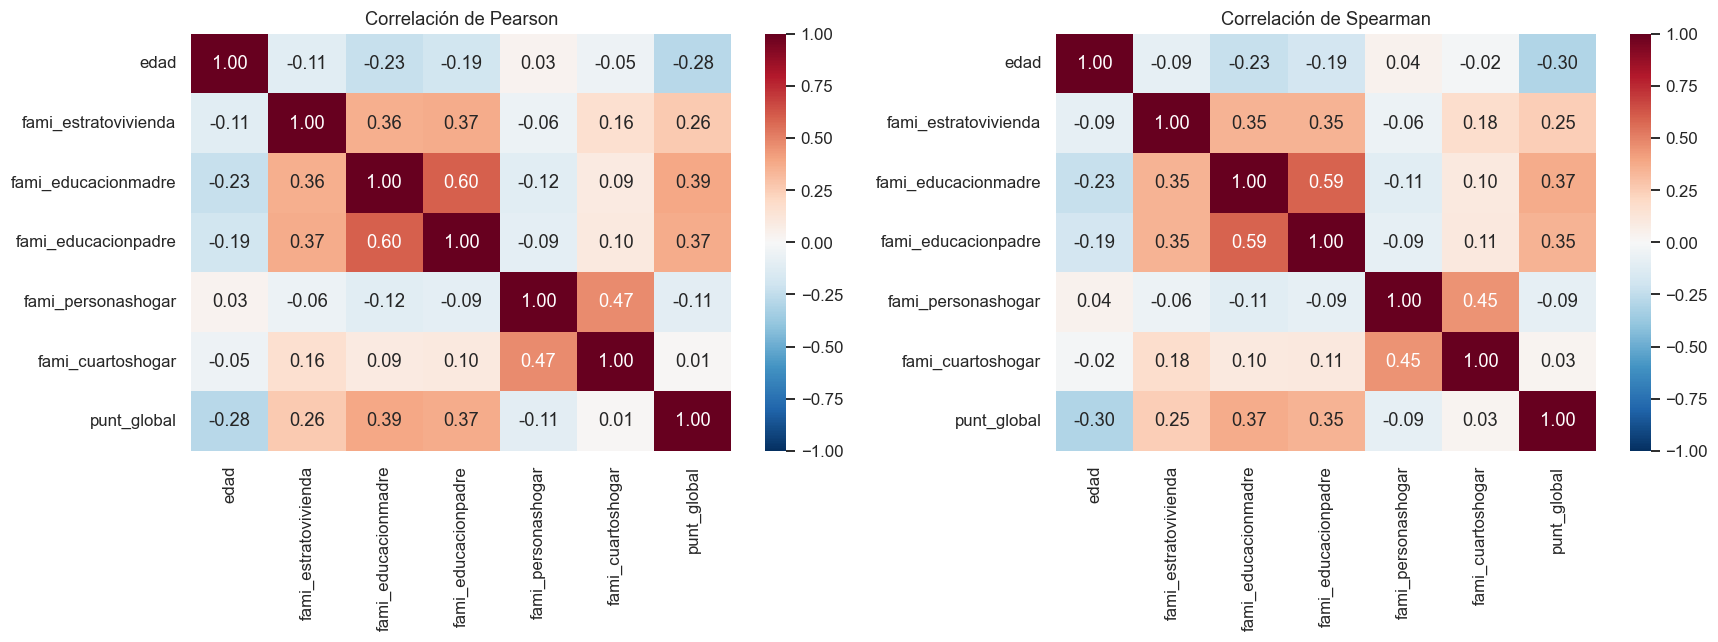

In [23]:
# 3.6.1 Correlación lineal (Pearson) y monótona (Spearman) entre variables numéricas/ordinales y el puntaje
df_analisis = X_train.copy()   # Solo entrenamiento: el análisis exploratorio tampoco debe "ver" el conjunto de prueba
for var, orden in ORDEN_ORDINALES.items():
    df_analisis[var] = df_analisis[var].map({cat: i for i, cat in enumerate(orden)})   # Código ordinal para analizar
df_analisis["punt_global"] = df_modelo.loc[X_train.index, "punt_global"]   # Puntaje continuo (más información que 0/1)
cols_corr = VARIABLES_NUMERICAS + VARIABLES_ORDINALES + ["punt_global"]

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))
for eje, metodo in zip(ejes, ["pearson", "spearman"]):   # Mismo mapa de calor con cada método, para comparar
    sns.heatmap(df_analisis[cols_corr].corr(method=metodo), annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, ax=eje)                  # Escala fija [-1, 1]: rojo positivo, azul negativo
    eje.set_title(f"Correlación de {metodo.capitalize()}")
plt.tight_layout(); guardar_figura("correlaciones"); plt.show()

🔎 **Interpretación:** Hallazgos:
- **Educación de los padres:** es la asociación más fuerte con el puntaje (madre r = 0,39 y ρ = 0,37; padre r = 0,37 y ρ = 0,35).
- **Edad:** relación negativa (r = −0,28, ρ = −0,30): a mayor edad, menor puntaje.
- **Estrato:** asociación positiva moderada (0,26).
- **Multicolinealidad:** las dos educaciones están muy correlacionadas entre sí (0,60), y el número de personas y de cuartos del hogar también (0,47).
- **Forma de la relación:** Pearson y Spearman son muy parecidos, así que las relaciones son **aproximadamente monótonas**. Ninguna variable ordinal muestra una curvatura que Pearson esté subestimando.

Como advierte el 📘, son asociaciones, no causas. El estrato y la educación de los padres comparten un factor común: el nivel socioeconómico del hogar.

#### 📘 Concepto: V de Cramér e información mutua
- **V de Cramér** mide la asociación entre dos variables **categóricas** a partir del estadístico $\chi^2$ de la tabla de contingencia:
  $$V = \sqrt{\frac{\chi^2}{n\,(\min(r,k)-1)}} \in [0,1]$$
  donde $r$ y $k$ son el número de filas y columnas. El p-valor de $\chi^2$ indica si la asociación es estadísticamente
  distinta de cero. Con $n$ grande casi todo es "significativo", por eso importa el **tamaño** $V$.
- **Información mutua** mide cuánta incertidumbre sobre $Y$ se reduce al conocer $X$:
  $$I(X;Y) = \sum_{x,y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)} \ge 0$$
  Es cero solo si las variables son independientes y capta **cualquier** tipo de dependencia, lineal o no.
  Por eso complementa a Pearson.

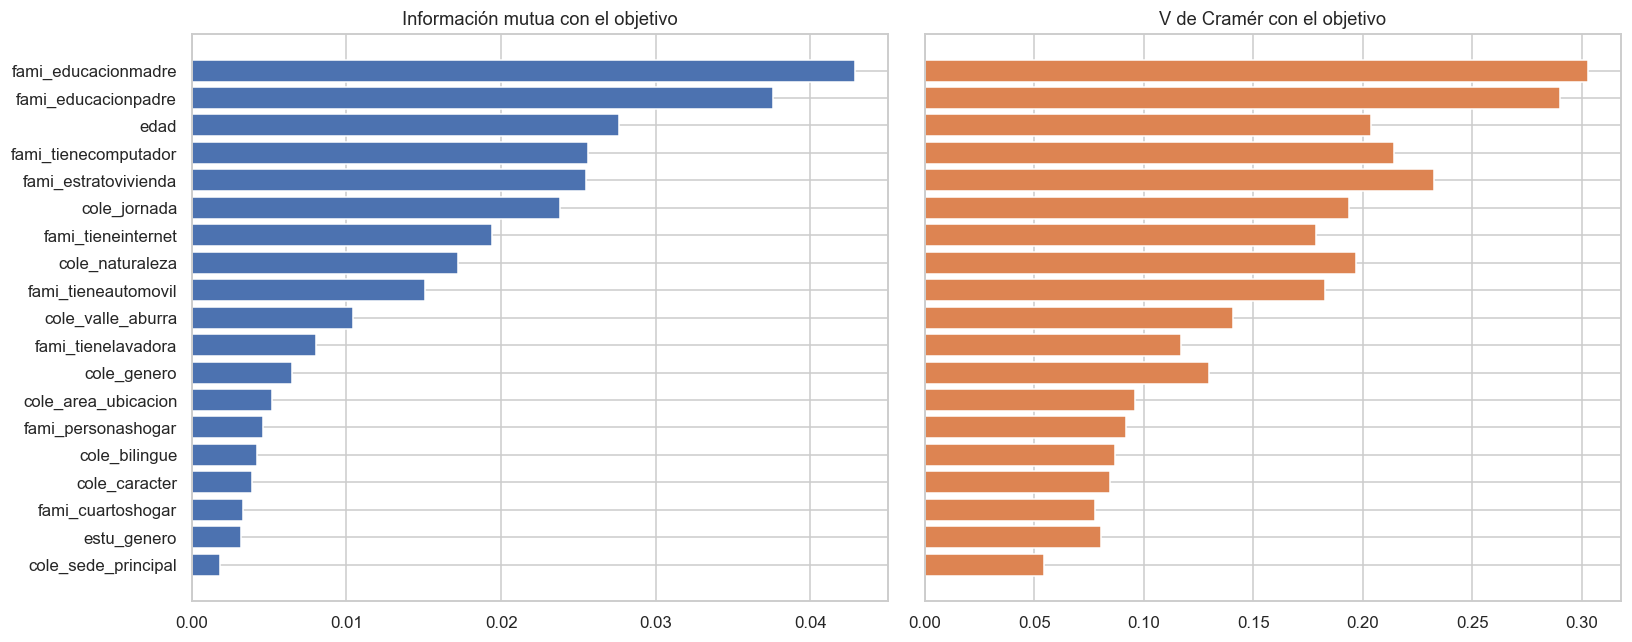

,variable,v_cramer,p_chi2,informacion_mutua,spearman_punt_global
2,fami_educacionmadre,0.3029,0.0000,0.0429,0.3734
3,fami_educacionpadre,0.2898,0.0000,0.0376,0.3504
0,edad,0.2039,0.0000,0.0276,-0.3016
8,fami_tienecomputador,0.2143,0.0000,0.0256,NaN
1,fami_estratovivienda,0.2324,0.0000,0.0255,0.2450
12,cole_jornada,0.1939,0.0000,0.0238,NaN
7,fami_tieneinternet,0.1788,0.0000,0.0194,NaN
11,cole_naturaleza,0.1970,0.0000,0.0172,NaN
9,fami_tieneautomovil,0.1827,0.0000,0.0151,NaN
18,cole_valle_aburra,0.1407,0.0000,0.0104,NaN


In [24]:
# 3.6.2 Asociación con el objetivo: V de Cramér (χ²) e información mutua (captura relaciones no lineales)
def v_cramer(x, y):
    """V de Cramér y p-valor de χ² entre dos variables categóricas."""
    tabla = pd.crosstab(x, y)                                   # Tabla de contingencia (frecuencias conjuntas)
    chi2, p_valor, _, _ = stats.chi2_contingency(tabla)         # Prueba de independencia χ²
    n = tabla.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1))), p_valor


# mutual_info_classif necesita números: se codifica cada categoría con un entero (el orden no importa en la IM discreta)
X_mi = pd.DataFrame(index=X_train.index)
for var in FEATURES:
    if var in VARIABLES_NUMERICAS:
        X_mi[var] = X_train[var].fillna(X_train[var].median())            # Continua: imputación simple solo para el análisis
    else:
        X_mi[var] = pd.factorize(X_train[var].fillna("DESCONOCIDO"))[0]   # Discreta: entero por categoría
info_mutua = mutual_info_classif(X_mi[FEATURES], y_train, random_state=RANDOM_STATE,
                                 discrete_features=[v not in VARIABLES_NUMERICAS for v in FEATURES])
filas = []
for var, mi in zip(FEATURES, info_mutua):
    v, p_valor = v_cramer(X_train[var].fillna("DESCONOCIDO").astype(str), y_train)
    # Spearman con el puntaje solo tiene sentido para numéricas y ordinales
    rho = df_analisis[var].corr(df_analisis["punt_global"], method="spearman") if var in cols_corr else np.nan
    filas.append({"variable": var, "v_cramer": v, "p_chi2": p_valor, "informacion_mutua": mi, "spearman_punt_global": rho})
tabla_relaciones = guardar_tabla(pd.DataFrame(filas).sort_values("informacion_mutua", ascending=False).round(4), "relaciones")

fig, ejes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)   # Mismo eje Y: se comparan ambos rankings por variable
orden_vars = tabla_relaciones["variable"]
ejes[0].barh(orden_vars, tabla_relaciones["informacion_mutua"], color="#4C72B0"); ejes[0].set_title("Información mutua con el objetivo")
ejes[1].barh(orden_vars, tabla_relaciones["v_cramer"], color="#DD8452"); ejes[1].set_title("V de Cramér con el objetivo")
ejes[0].invert_yaxis(); plt.tight_layout(); guardar_figura("asociacion_objetivo"); plt.show()   # La más asociada arriba
tabla_relaciones

🔎 **Interpretación:** Todas las variables tienen asociación estadísticamente significativa con el objetivo (p < 0,001). Con n = 21.000 esto es esperable, así que lo relevante es el **tamaño** del efecto:
- Las más asociadas son la educación de la madre (V = 0,30; IM = 0,043) y del padre (V = 0,29), la edad, tener computador, el estrato y la jornada.
- Las menos asociadas son la sede principal, el género del estudiante y el número de cuartos (V < 0,08).

La información mutua y la V de Cramér ordenan las variables de forma muy parecida. La información es moderada y está repartida entre varias variables, lo que anticipa un techo de desempeño modesto para cualquier modelo.

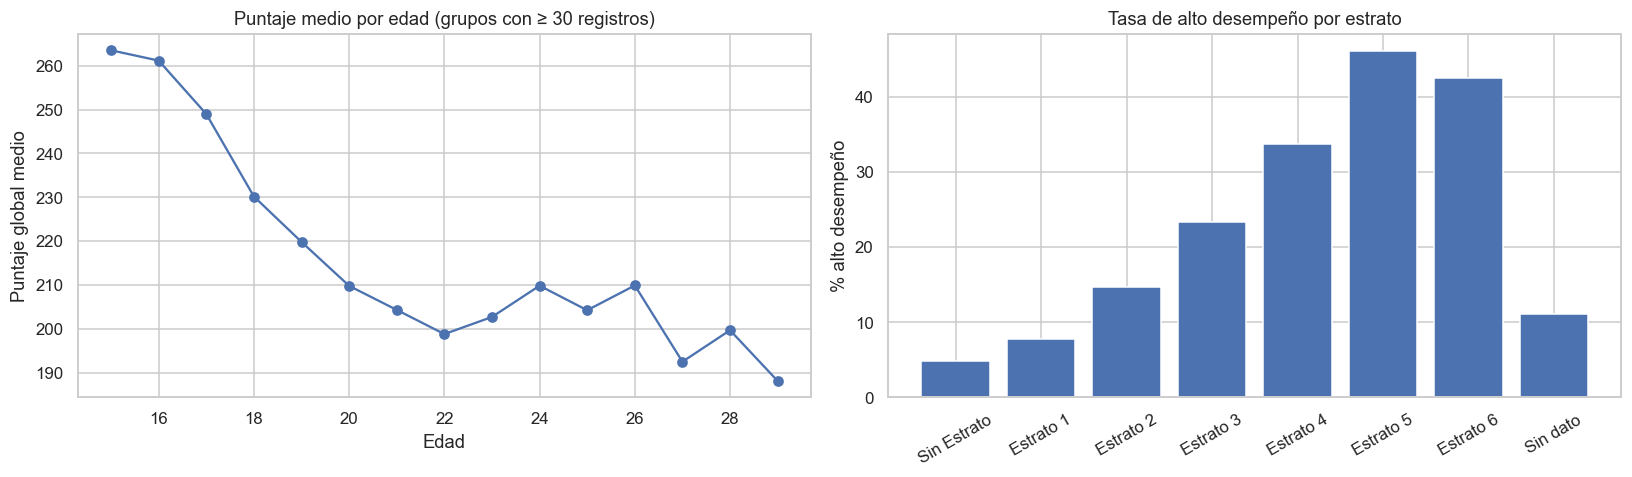

In [25]:
# 3.6.3 Evidencia de no linealidad: puntaje medio por edad y tasa de alto desempeño por estrato
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.5))
# Izquierda: si la curva no es una recta, un coeficiente lineal subestima la relación edad-puntaje
por_edad = df_analisis.groupby("edad")["punt_global"].agg(["mean", "size"]).query("size >= 30")   # Grupos estables
ejes[0].plot(por_edad.index, por_edad["mean"], marker="o"); ejes[0].set_xlabel("Edad"); ejes[0].set_ylabel("Puntaje global medio")
ejes[0].set_title("Puntaje medio por edad (grupos con ≥ 30 registros)")
# Derecha: tasa de positivos por estrato, en el orden natural del estrato
por_estrato = pd.Series(y_train.groupby(X_train["fami_estratovivienda"].fillna("Sin dato")).mean() * 100)
por_estrato = por_estrato.reindex([c for c in ORDEN_ORDINALES["fami_estratovivienda"] + ["Sin dato"] if c in por_estrato.index])
ejes[1].bar(por_estrato.index, por_estrato.values, color="#4C72B0"); ejes[1].set_ylabel("% alto desempeño")
ejes[1].set_title("Tasa de alto desempeño por estrato"); ejes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); guardar_figura("no_linealidad"); plt.show()

🔎 **Interpretación:** - **Edad (izquierda):** la relación **no es lineal**. El puntaje medio cae con fuerza entre los 15 y los 20 años (de ~263 a ~210) y luego se estabiliza alrededor de 200–210. Un coeficiente lineal único no describe bien esa forma: es la no linealidad que la información mutua sí capta.
- **Estrato (derecha):** crece de forma monótona hasta el estrato 5 (~46 %) y baja ligeramente en el estrato 6 (~42 %, con pocos casos). "Sin estrato" es el grupo más bajo (~5 %).

Por eso tiene sentido comparar modelos lineales con modelos flexibles (árboles, SVM RBF) en la fase 4.

### 3.7 Reducción de dimensiones (PCA)

#### 📘 Concepto: Análisis de Componentes Principales
**PCA** busca nuevas variables (componentes) que son **combinaciones lineales** de las originales, no están correlacionadas
entre sí y están ordenadas por la **varianza** que explican. Matemáticamente, son los vectores propios de la matriz de
covarianza $\Sigma = \frac{1}{n}X^\top X$ (con $X$ centrada), y la fracción de varianza que explica la componente $k$ es
$\lambda_k / \sum_j \lambda_j$.

- **Ventajas:** reduce dimensión, ruido y colinealidad, y acelera modelos basados en distancias.
- **Desventajas:** las componentes pierden interpretabilidad ("0,3·estrato − 0,2·jornada…"), PCA solo capta estructura
  lineal y maximiza varianza, no poder predictivo.

**Regla de decisión:** aplicarlo solo si mejora el desempeño o si la dimensión es un problema. Aquí se evalúa empíricamente.

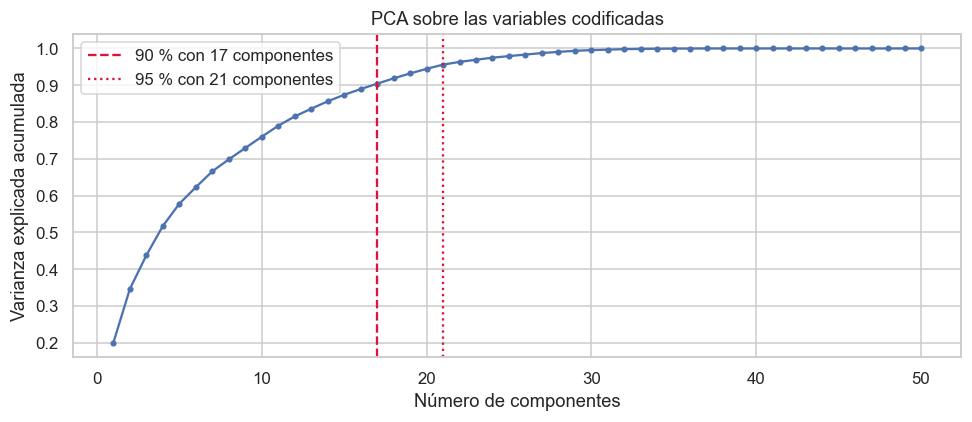

Dimensión codificada: 50 | 90 %: 17 componentes | 95 %: 21 componentes


In [26]:
# 3.7.1 Varianza explicada por componentes principales sobre la matriz codificada de entrenamiento
pca = PCA(random_state=RANDOM_STATE).fit(X_train_cod)      # Sin n_components: calcula todas las componentes
var_acum = np.cumsum(pca.explained_variance_ratio_)        # Varianza explicada acumulada
n_90 = int(np.searchsorted(var_acum, 0.90) + 1)            # Mínimo de componentes para llegar al 90 %
n_95 = int(np.searchsorted(var_acum, 0.95) + 1)            # ... y al 95 %

fig, eje = plt.subplots(figsize=(9, 4))
eje.plot(range(1, len(var_acum) + 1), var_acum, marker="o", ms=3)   # Curva de varianza acumulada
eje.axvline(n_90, ls="--", color="crimson", label=f"90 % con {n_90} componentes")
eje.axvline(n_95, ls=":", color="crimson", label=f"95 % con {n_95} componentes")
eje.set_xlabel("Número de componentes"); eje.set_ylabel("Varianza explicada acumulada")
eje.set_title("PCA sobre las variables codificadas"); eje.legend()
plt.tight_layout(); guardar_figura("pca_varianza"); plt.show()
print(f"Dimensión codificada: {X_train_cod.shape[1]} | 90 %: {n_90} componentes | 95 %: {n_95} componentes")

🔎 **Interpretación:** Con 50 columnas codificadas, PCA necesita **17 componentes para explicar el 90 %** de la varianza y 21 para el 95 %. La curva crece de forma gradual, sin un "codo" marcado.
La varianza está repartida porque muchas columnas son dummies casi independientes. Reducir a 17 componentes quitaría dimensiones, pero cada componente mezclaría variables heterogéneas (jornada, estrato, tenencias) y perdería su significado.

In [27]:
# 3.7.2 Prueba empírica: ¿PCA mejora el F1 de un modelo de referencia? (regresión logística balanceada, CV 5-fold)
# Se comparan dos pipelines idénticos salvo por el paso PCA; la decisión se basa en evidencia, no en costumbre
referencia = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
f1_sin_pca = cross_val_score(Pipeline([("prep", clone(preprocesador)), ("modelo", clone(referencia))]),
                             X_train, y_train, cv=CV, scoring="f1", n_jobs=-1)
f1_con_pca = cross_val_score(Pipeline([("prep", clone(preprocesador)),
                                       ("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)),   # 0.90 = 90 % de varianza
                                       ("modelo", clone(referencia))]),
                             X_train, y_train, cv=CV, scoring="f1", n_jobs=-1)
APLICAR_PCA = bool(f1_con_pca.mean() > f1_sin_pca.mean() + 0.01)   # Solo si mejora el F1 en más de 0,01
justificacion_pca = (
    f"PCA: {n_90} de {X_train_cod.shape[1]} componentes explican el 90 % de la varianza. "
    f"F1 CV sin PCA = {f1_sin_pca.mean():.4f}; con PCA = {f1_con_pca.mean():.4f}. "
    + ("Se aplica porque mejora el F1 en más de 0,01." if APLICAR_PCA else
       "No se aplica: no mejora el desempeño, la dimensión ya es baja y se perdería la interpretabilidad de las variables."))
guardar_tabla(pd.DataFrame({"tecnica": ["Análisis de Componentes Principales (PCA)"], "justificacion": [justificacion_pca]}),
              "reduccion_dimensiones")   # Tabla 3.6 del informe
print(justificacion_pca)

PCA: 17 de 50 componentes explican el 90 % de la varianza. F1 CV sin PCA = 0.4685; con PCA = 0.4592. No se aplica: no mejora el desempeño, la dimensión ya es baja y se perdería la interpretabilidad de las variables.


🔎 **Interpretación:** La prueba empírica decide: con PCA el F1 en validación cruzada **baja** de 0,4685 a 0,4592. Como no mejora (el criterio exigía +0,01), **no se aplica** reducción de dimensiones.
Es la regla de decisión del 📘: PCA maximiza varianza, no poder predictivo, y aquí descarta parte de la señal útil para la clase minoritaria. Además, conservar las variables originales permite interpretar el modelo en la fase 5.

### 3.8 Balanceo de clases

#### 📘 Concepto: Balanceo de clases
Con clases desbalanceadas, el modelo "aprende" que casi siempre conviene predecir la mayoritaria. Estrategias:

| Estrategia | Idea | Ventaja | Riesgo |
|---|---|---|---|
| **Ponderación** (`class_weight`) | Penaliza más los errores en la minoritaria | No altera los datos | No todos los modelos lo admiten (p. ej. KNN) |
| **Submuestreo** (RandomUnderSampler) | Descarta registros de la mayoritaria | Rápido | Pierde información |
| **SMOTE** (Chawla et al., 2002) | Crea registros sintéticos interpolando vecinos de la minoritaria | Conserva todos los datos | Puede generar ruido en zonas de solapamiento |

SMOTE genera cada registro sintético como $x_{nuevo} = x_i + \lambda\,(x_{vecino} - x_i)$ con $\lambda \sim U(0,1)$.

**Regla de oro:** el balanceo se aplica **solo al entrenamiento** (dentro de cada fold). Los datos de validación y de
prueba deben conservar la distribución real; si no, las métricas no representan el uso real.

In [28]:
# 3.8.1 Comparación de estrategias de balanceo con un modelo de referencia (regresión logística, CV 5-fold)
def pipeline_referencia(muestreador=None, class_weight=None):
    """Preprocesamiento + (muestreador opcional) + regresión logística."""
    pasos = [("preprocesamiento", clone(preprocesador))]
    if muestreador is not None:
        pasos.append(("balanceo", muestreador))   # imblearn aplica el muestreo solo durante fit, nunca en predict
    pasos.append(("modelo", LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE)))
    return ImbPipeline(pasos)


# Solo los muestreadores compiten para el pipeline final: sirven para los 8 modelos (class_weight no existe en KNN)
MUESTREADORES = {"Submuestreo aleatorio (RandomUnderSampler)": RandomUnderSampler(random_state=RANDOM_STATE),
                 "Sobremuestreo sintético (SMOTE)": SMOTE(random_state=RANDOM_STATE)}
estrategias = {"Sin balanceo": pipeline_referencia(),                                   # Línea base
               "Ponderación de clases (class_weight)": pipeline_referencia(class_weight="balanced"),
               **{nombre: pipeline_referencia(m) for nombre, m in MUESTREADORES.items()}}
filas = []
for nombre, pipe in estrategias.items():
    # cross_validate devuelve una métrica por fold; se reportan la media y la desviación del F1
    res = cross_validate(pipe, X_train, y_train, cv=CV, scoring=["f1", "precision", "recall", "roc_auc"], n_jobs=-1)
    filas.append({"estrategia": nombre, "f1": res["test_f1"].mean(), "f1_std": res["test_f1"].std(),
                  "precision": res["test_precision"].mean(), "recall": res["test_recall"].mean(),
                  "roc_auc": res["test_roc_auc"].mean()})
df_balanceo = guardar_tabla(pd.DataFrame(filas).round(4), "balanceo_comparacion")
df_balanceo

,estrategia,f1,f1_std,precision,recall,roc_auc
0,Sin balanceo,0.3157,0.0162,0.6052,0.2138,0.8015
1,Ponderación de clases (class_weight),0.4685,0.0120,0.3406,0.7504,0.8015
2,Submuestreo aleatorio (RandomUnderSampler),0.4696,0.0121,0.3414,0.7526,0.8010
3,Sobremuestreo sintético (SMOTE),0.4673,0.0121,0.3404,0.7454,0.8000


🔎 **Interpretación:** Sin balanceo, la regresión logística tiene Precision 0,61 pero **Recall 0,21**: detecta solo uno de cada cinco estudiantes de alto desempeño, y su F1 es 0,316. Las tres estrategias de balanceo elevan el Recall a ~0,75 y el F1 a ~0,47:

| Estrategia | F1 en CV |
|---|---|
| RandomUnderSampler | 0,4696 |
| class_weight | 0,4685 |
| SMOTE | 0,4673 |

La **ROC-AUC casi no cambia** (~0,80): el balanceo no mejora la capacidad de ordenar a los estudiantes, solo desplaza el punto de decisión hacia la clase minoritaria. Es una lección clave: balancear es, en buena medida, elegir un umbral distinto.

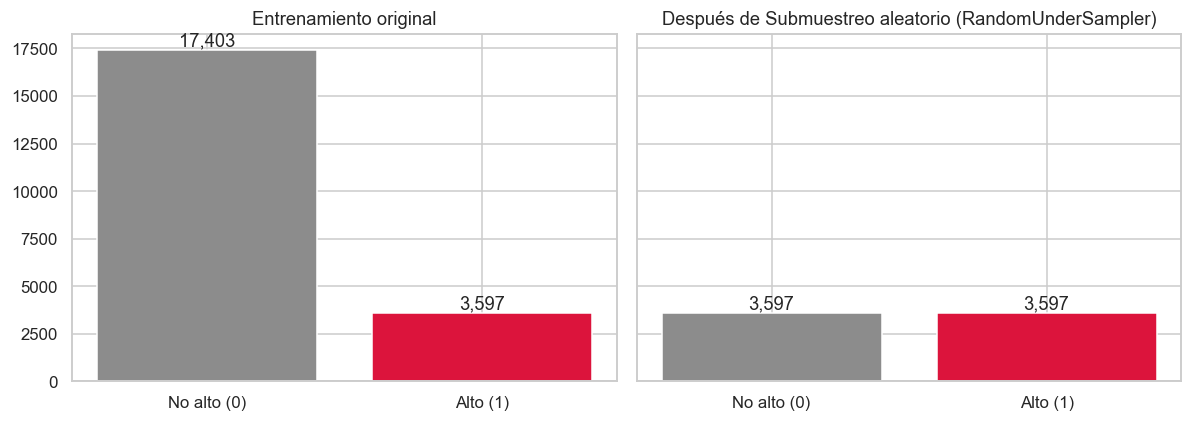

Submuestreo aleatorio (RandomUnderSampler): mejor F1 en CV entre los muestreadores (0.4696 frente a 0.3157 sin balanceo). Se aplica dentro del pipeline (imblearn), solo en los folds de entrenamiento, para no contaminar la validación ni el test.


In [29]:
# 3.8.2 Elección del muestreador (mejor F1) y efecto sobre la distribución de clases del entrenamiento
mejor_balanceo = df_balanceo[df_balanceo["estrategia"].isin(MUESTREADORES)].sort_values("f1", ascending=False).iloc[0]
BALANCEADOR = MUESTREADORES[mejor_balanceo["estrategia"]]              # Se usará en todos los pipelines de la fase 4
_, y_balanceado = clone(BALANCEADOR).fit_resample(X_train_cod, y_train)   # Solo para visualizar el efecto

fig, ejes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for eje, serie, titulo in zip(ejes, [y_train, pd.Series(y_balanceado)],
                              ["Entrenamiento original", f"Después de {mejor_balanceo['estrategia']}"]):
    conteo = serie.value_counts().sort_index()   # Índice 0 y 1 en orden
    eje.bar(["No alto (0)", "Alto (1)"], conteo.values, color=["#8C8C8C", "crimson"])
    for i, v in enumerate(conteo.values):
        eje.text(i, v, f"{v:,}", ha="center", va="bottom")   # Conteo sobre cada barra
    eje.set_title(titulo)
plt.tight_layout(); guardar_figura("balanceo_distribucion"); plt.show()

# Justificación para la tabla 3.7 del informe, con las cifras obtenidas
f1_sin_balanceo = df_balanceo.loc[df_balanceo["estrategia"] == "Sin balanceo", "f1"].iloc[0]
justificacion_balanceo = (
    f"{mejor_balanceo['estrategia']}: mejor F1 en CV entre los muestreadores ({mejor_balanceo['f1']:.4f} frente a "
    f"{f1_sin_balanceo:.4f} sin balanceo). Se aplica dentro del pipeline (imblearn), solo en los folds de entrenamiento, "
    "para no contaminar la validación ni el test.")
guardar_tabla(pd.DataFrame({"tecnica": [mejor_balanceo["estrategia"]], "justificacion": [justificacion_balanceo]}), "balanceo")
print(justificacion_balanceo)

🔎 **Interpretación:** Se elige **RandomUnderSampler**, el muestreador con mejor F1. Su ventaja sobre SMOTE (0,0023) es mucho menor que la desviación estándar entre folds (~0,012): en la práctica las estrategias empatan.
El submuestreo deja el entrenamiento balanceado 1:1 (≈3.600 casos por clase, frente a ≈17.400 negativos originales). Como ventaja adicional reduce el costo de cómputo: el SVM entrena con ~6 mil filas por fold en lugar de ~28 mil con SMOTE. Solo actúa en `fit` dentro de cada fold, así que validación y prueba conservan la distribución real.

### 🧠 Para profundizar — Fase 3: Preparación de los datos
**Ideas clave**
- Las transformaciones **determinísticas** van antes de partir los datos; las **aprendidas** van dentro del pipeline.
- El tipo de variable define su codificación: ordinal con orden explícito, nominal con One-Hot, numérica con escalado.
- Los faltantes pueden ser informativos (MNAR): el indicador o la categoría `DESCONOCIDO` preservan esa señal.
- Pearson ve relaciones lineales, Spearman monótonas y la información mutua cualquier dependencia.
- Reducir dimensiones o balancear son **decisiones empíricas**: se comparan con y sin la técnica.

**Preguntas de repaso**
1. ¿Qué pasaría con las métricas si se aplicara SMOTE **antes** de la validación cruzada?
2. ¿Por qué codificar `cole_jornada` como 0, 1, 2… sería un error para la regresión logística pero casi no afectaría a un árbol?
3. Si $\rho_{Spearman} = 0{,}40$ y $r_{Pearson} = 0{,}25$ entre estrato y puntaje, ¿qué se concluye sobre la forma de la relación?
4. ¿En qué casos sí convendría aplicar PCA en este problema?

**Ejercicios**
- Reemplaza SMOTE por `SMOTENC` (que trata las categóricas sin interpolarlas) y compara el F1 en CV.
- Elimina `add_indicator=True` del pipeline ordinal y mide el efecto en el F1 de la regresión logística.

**Referencias**
- Rubin, D. B. (1976). Inference and missing data. *Biometrika*, 63(3), 581–592.
- Little, R. J. A. y Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3.ª ed.). Wiley.
- Kuhn, M. y Johnson, K. (2019). *Feature Engineering and Selection*. CRC Press.
- Jolliffe, I. T. y Cadima, J. (2016). Principal component analysis: a review and recent developments. *Phil. Trans. R. Soc. A*, 374.
- Chawla, N. V., Bowyer, K. W., Hall, L. O. y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *JAIR*, 16, 321–357.
- Cover, T. M. y Thomas, J. A. (2006). *Elements of Information Theory* (2.ª ed.). Wiley (cap. 2: información mutua).
- Guía de usuario de scikit-learn: *Preprocessing data*, *Imputation of missing values* y *Column Transformer*.

## 4. Modelamiento

#### 📘 Concepto: Validación cruzada y pipelines
**Validación cruzada k-fold:** el entrenamiento se divide en $k$ partes (*folds*). Se entrena $k$ veces, cada vez con
$k-1$ folds, y se evalúa en el restante. La estimación del desempeño es el promedio de las $k$ evaluaciones, y su
desviación estándar indica la **estabilidad** del modelo. Con `StratifiedKFold` cada fold conserva la proporción de clases.

$$\widehat{F1}_{CV} = \frac{1}{k}\sum_{j=1}^{k} F1_j \qquad (k = 5)$$

**Pipeline:** encadena preprocesamiento → balanceo → modelo en un solo objeto. En cada fold, *todo* se ajusta solo con
los folds de entrenamiento, lo que elimina la fuga de información por preprocesamiento (Kaufman et al., 2012). Además, el
pipeline completo es lo que se serializa en la fase 6: la app recibe datos crudos y aplica exactamente las mismas
transformaciones.

Todos los modelos usan **los mismos 5 folds**, así que la comparación entre modelos es **pareada** (se usa en la fase 5).

In [30]:
# 4.0 Fábrica de pipelines y función de validación cruzada común
def crear_pipeline(modelo):
    """Preprocesamiento + (PCA opcional) + balanceo + modelo; todo se ajusta dentro de cada fold."""
    pasos = [("preprocesamiento", clone(preprocesador))]   # clone: cada pipeline recibe su propio preprocesador sin entrenar
    if APLICAR_PCA:                                         # Decisión tomada con evidencia en la prueba de PCA (fase 3)
        pasos.append(("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)))
    pasos += [("balanceo", clone(BALANCEADOR)), ("modelo", modelo)]   # Muestreador elegido al comparar estrategias de balanceo (fase 3)
    return ImbPipeline(pasos)


METRICAS_CV = ["f1", "precision", "recall", "accuracy", "roc_auc"]   # F1 es la principal; las demás dan contexto


def evaluar_cv(nombre, modelo):
    """CV estratificada 5-fold sobre el entrenamiento; devuelve el resumen y el F1 de cada fold."""
    inicio = time.time()
    # n_jobs=-1 entrena los 5 folds en paralelo con todos los núcleos disponibles
    res = cross_validate(crear_pipeline(modelo), X_train, y_train, cv=CV, scoring=METRICAS_CV, n_jobs=-1)
    resumen = {"modelo": nombre, **{f"{m}_mean": res[f"test_{m}"].mean() for m in METRICAS_CV},
               "f1_std": res["test_f1"].std(), "tiempo_s": time.time() - inicio}   # std del F1 = estabilidad
    return resumen, res["test_f1"]   # También el F1 por fold, para las pruebas estadísticas pareadas


# Se muestran los pasos del pipeline para verificar el orden
print("Pasos del pipeline:", [nombre for nombre, _ in crear_pipeline(LogisticRegression()).steps])

Pasos del pipeline: ['preprocesamiento', 'balanceo', 'modelo']


🔎 **Interpretación:** El pipeline de todos los modelos tiene tres pasos: `preprocesamiento` → `balanceo` → `modelo`. No hay paso `pca`, por la decisión de 3.7.2.
Con esta fábrica, cada modelo se evalúa exactamente igual: mismos folds, mismo preprocesamiento aprendido dentro de cada fold y mismo muestreador. Cualquier diferencia de F1 se debe al algoritmo y no a cómo se prepararon los datos.

### 4.1 Modelos clásicos

#### 📘 Concepto: Modelos clásicos
| Modelo | Idea central | Hiperparámetro clave | Fortalezas | Debilidades |
|---|---|---|---|---|
| **Regresión Logística** | $P(y=1\mid x) = \sigma(w^\top x + b) = \frac{1}{1+e^{-(w^\top x+b)}}$; minimiza la log-pérdida con regularización | `C` (inverso de la regularización) | Interpretable (coeficientes = log-odds), rápida, probabilidades calibradas | Frontera lineal |
| **KNN** | Clase mayoritaria entre los $k$ vecinos más cercanos (distancia de Minkowski) | `n_neighbors`, `weights` | Sin supuestos de forma, frontera flexible | Lento al predecir, sensible a la escala y a la dimensión |
| **Árbol de Decisión** | Divisiones binarias que reducen la impureza: Gini $=1-\sum_c p_c^2$ o entropía $=-\sum_c p_c\log p_c$ | `max_depth`, `min_samples_leaf` | Muy interpretable, captura interacciones | Alta varianza (sobreajusta) |
| **SVM (RBF)** | Hiperplano de **margen máximo** en un espacio transformado por el kernel $K(x,x') = e^{-\gamma\lVert x-x'\rVert^2}$ | `C`, `gamma` | Fronteras no lineales complejas | Costo $O(n^2)$–$O(n^3)$; no da probabilidades por defecto |
| **Random Forest** | Promedio de muchos árboles entrenados con *bootstrap* y un subconjunto aleatorio de variables en cada división | `n_estimators`, `max_features` | Robusto, poca varianza, pocas decisiones de ajuste | Menos interpretable, modelo pesado |

El dilema **sesgo-varianza** organiza la comparación: los modelos simples (logística) tienen más sesgo; los flexibles
(árbol profundo, KNN con $k$ pequeño) tienen más varianza. La validación cruzada muestra cuál equilibra mejor en este problema.

In [31]:
# 4.1.1 Cinco modelos clásicos con hiperparámetros iniciales razonables
modelos_clasicos = {
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),   # max_iter alto: asegura convergencia
    "KNN": KNeighborsClassifier(n_neighbors=15),                                           # k impar evita empates
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),   # Profundidad acotada contra sobreajuste
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),       # Valores por defecto de scikit-learn
    # n_jobs=1 dentro del modelo: el paralelismo ya lo aporta la validación cruzada (evita saturar la CPU)
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=1),
}
# Texto para la tabla 4.1 del informe
HIPERPARAMETROS_INICIALES = {
    "Regresión Logística": "C=1.0, penalización L2, max_iter=2000",
    "KNN": "n_neighbors=15, weights='uniform', p=2 (euclidiana)",
    "Árbol de Decisión": "max_depth=8, criterion='gini', min_samples_leaf=1",
    "SVM (RBF)": "kernel='rbf', C=1.0, gamma='scale'",
    "Random Forest": "n_estimators=200, min_samples_leaf=5, max_features='sqrt'",
}
resultados_cv, f1_por_fold = [], {}   # Resúmenes por modelo y F1 de cada fold (para comparaciones pareadas)
for nombre, modelo in modelos_clasicos.items():
    resumen, f1s = evaluar_cv(nombre, modelo)
    resultados_cv.append(resumen)
    f1_por_fold[nombre] = f1s
    print(f"{nombre:<22} F1 = {resumen['f1_mean']:.4f} ± {resumen['f1_std']:.4f}  ({resumen['tiempo_s']:.0f} s)")

df_clasicos = pd.DataFrame(resultados_cv).sort_values("f1_mean", ascending=False).reset_index(drop=True)   # Ranking
guardar_tabla(pd.DataFrame({"modelo": df_clasicos["modelo"],
                            "hiperparametros_iniciales": df_clasicos["modelo"].map(HIPERPARAMETROS_INICIALES),
                            "metrica": "F1 (clase positiva)", "cv_mean": df_clasicos["f1_mean"].round(4),
                            "cv_std": df_clasicos["f1_std"].round(4)}), "modelos_clasicos")   # Tabla 4.1 del informe
df_clasicos.round(4)

Regresión Logística    F1 = 0.4696 ± 0.0121  (2 s)


KNN                    F1 = 0.4289 ± 0.0093  (3 s)


Árbol de Decisión      F1 = 0.4298 ± 0.0130  (2 s)


SVM (RBF)              F1 = 0.4659 ± 0.0131  (24 s)


Random Forest          F1 = 0.4690 ± 0.0099  (7 s)


,modelo,f1_mean,precision_mean,recall_mean,accuracy_mean,roc_auc_mean,f1_std,tiempo_s
0,Regresión Logística,0.4696,0.3414,0.7526,0.7086,0.8010,0.0121,1.7456
1,Random Forest,0.4690,0.3445,0.7348,0.7150,0.8002,0.0099,6.6483
2,SVM (RBF),0.4659,0.3359,0.7598,0.7015,0.7943,0.0131,24.0681
3,Árbol de Decisión,0.4298,0.3058,0.7231,0.6711,0.7520,0.0130,1.7328
4,KNN,0.4289,0.2983,0.7629,0.6520,0.7687,0.0093,3.4137


🔎 **Interpretación:** Ranking de los modelos clásicos por F1 en validación cruzada:

| Modelo | F1 en CV |
|---|---|
| Regresión Logística | 0,4696 ± 0,012 |
| Random Forest | 0,4690 ± 0,010 |
| SVM RBF | 0,4659 ± 0,013 |
| Árbol de decisión | 0,4298 |
| KNN | 0,4289 |

- **Los tres primeros empatan en la práctica:** sus diferencias son mucho menores que la desviación entre folds, y la ROC-AUC de los tres ronda 0,80. Que el modelo **lineal** empate con los flexibles indica que la señal disponible es esencialmente aditiva: la flexibilidad extra no encuentra patrones adicionales.
- **El árbol y KNN quedan claramente atrás:** el árbol individual tiene alta varianza, y KNN sufre con 50 dimensiones en su mayoría binarias.
- **Costo:** el SVM es, con diferencia, el más lento (unos 25 s frente a 2 s de la logística), aun con el submuestreo.

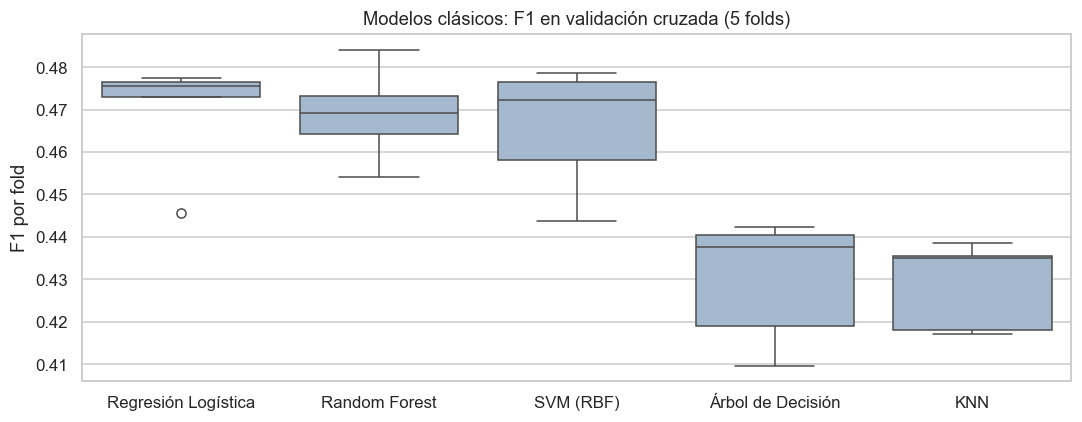

In [32]:
# 4.1.2 Variabilidad del F1 entre folds (misma partición para todos: comparación pareada)
# Un diagrama de caja muestra mediana, dispersión y folds atípicos: dos modelos con cajas solapadas pueden no diferir realmente
fig, eje = plt.subplots(figsize=(10, 4))
sns.boxplot(data=pd.DataFrame(f1_por_fold)[df_clasicos["modelo"]], ax=eje, color="#9DB7D5")   # Orden del ranking
eje.set_ylabel("F1 por fold"); eje.set_title("Modelos clásicos: F1 en validación cruzada (5 folds)")
plt.tight_layout(); guardar_figura("cv_clasicos"); plt.show()

🔎 **Interpretación:** El diagrama de cajas confirma lo anterior: las cajas de la logística, Random Forest y el SVM se solapan casi por completo, mientras las del árbol y KNN están claramente más abajo.
Mirar la **distribución por fold**, y no solo la media, evita conclusiones apresuradas: con desviaciones de ~0,01, una diferencia de medias de 0,0006 (logística frente a Random Forest) es ruido. Esa intuición se formaliza con el t-test corregido en la fase 5.

### 4.2 Modelos de ensamble (actividad investigativa)

#### 📘 Concepto: Métodos de ensamble
Un **ensamble** combina varios modelos para obtener uno mejor que cada componente. Hay tres familias:

- **Votación** (*voting*): modelos **distintos** predicen y se combinan. En el voto **duro** gana la clase más votada; en el
  voto **suave** se promedian las probabilidades, $\hat p(x) = \sum_m w_m\,\hat p_m(x) / \sum_m w_m$. Funciona mejor
  cuando los modelos cometen **errores distintos** (baja correlación).
- **Bagging** (Breiman, 1996): muchos modelos **iguales** (aquí árboles profundos) entrenados en muestras *bootstrap*
  (con reemplazo) y promediados. Promediar $B$ modelos con varianza $\sigma^2$ y correlación $\rho$ da varianza
  $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$: **reduce la varianza**. Random Forest es bagging más un sorteo de variables
  en cada división, que baja $\rho$.
- **Boosting** (Friedman, 2001): modelos débiles (árboles poco profundos) entrenados **en secuencia**; cada uno ajusta el
  gradiente del error de los anteriores, $F_m(x) = F_{m-1}(x) + \eta\,h_m(x)$. **Reduce el sesgo**. **XGBoost** (Chen y
  Guestrin, 2016) agrega regularización L1/L2 sobre las hojas, submuestreo y un algoritmo eficiente por histogramas.

In [33]:
# 4.2.1 Votación suave (3 mejores clásicos con probabilidades), Bagging de árboles y XGBoost
# Alias cortos: VotingClassifier exige nombres simples para sus modelos internos
ALIAS = {"Regresión Logística": "logistica", "KNN": "knn", "Árbol de Decisión": "arbol",
         "SVM (RBF)": "svm", "Random Forest": "rf"}
# El voto suave necesita predict_proba: el SVC sin probability=True no lo tiene y queda excluido automáticamente
con_probabilidad = [n for n in df_clasicos["modelo"] if hasattr(modelos_clasicos[n], "predict_proba")]
TOP3_VOTO = con_probabilidad[:3]   # Los tres mejores clásicos según el ranking de 4.1
modelos_ensamble = {
    "Votación (soft)": VotingClassifier([(ALIAS[n], clone(modelos_clasicos[n])) for n in TOP3_VOTO], voting="soft"),
    # Bagging de árboles sin límite de profundidad (alta varianza, que el promedio reduce); max_samples = 80 % por árbol
    "Bagging (árboles)": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=100,
                                           max_samples=0.8, random_state=RANDOM_STATE, n_jobs=1),
    # Boosting: árboles poco profundos (max_depth=4) + tasa de aprendizaje moderada + submuestreo de filas y columnas
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                             eval_metric="logloss", tree_method="hist", random_state=RANDOM_STATE, n_jobs=1),
}
resultados_ens = []
for nombre, modelo in modelos_ensamble.items():   # Misma evaluación y mismos folds que los clásicos
    resumen, f1s = evaluar_cv(nombre, modelo)
    resultados_ens.append(resumen)
    f1_por_fold[nombre] = f1s
    print(f"{nombre:<22} F1 = {resumen['f1_mean']:.4f} ± {resumen['f1_std']:.4f}  ({resumen['tiempo_s']:.0f} s)")
df_ensambles = pd.DataFrame(resultados_ens).sort_values("f1_mean", ascending=False).reset_index(drop=True)

mejor_clasico = df_clasicos.iloc[0]   # Referencia para medir la mejora de cada ensamble
TIPOS_ENSAMBLE = {"Votación (soft)": "Votación suave (heterogéneo): " + ", ".join(TOP3_VOTO),
                  "Bagging (árboles)": "Bagging (homogéneo, paralelo, bootstrap)",
                  "XGBoost": "Boosting (secuencial, por gradiente)"}
guardar_tabla(pd.DataFrame({   # Tabla 4.2 del informe
    "modelo": df_ensambles["modelo"], "tipo": df_ensambles["modelo"].map(TIPOS_ENSAMBLE),
    "desempeno": [f"F1 CV = {m:.4f} ± {s:.4f}" for m, s in zip(df_ensambles["f1_mean"], df_ensambles["f1_std"])],
    "mejora_vs_clasico": [f"{d:+.4f} vs {mejor_clasico['modelo']}" for d in df_ensambles["f1_mean"] - mejor_clasico["f1_mean"]],
}), "modelos_ensamble")
df_ensambles.round(4)

Votación (soft)        F1 = 0.4643 ± 0.0138  (7 s)


Bagging (árboles)      F1 = 0.4363 ± 0.0090  (12 s)


XGBoost                F1 = 0.4606 ± 0.0123  (5 s)


,modelo,f1_mean,precision_mean,recall_mean,accuracy_mean,roc_auc_mean,f1_std,tiempo_s
0,Votación (soft),0.4643,0.3376,0.7434,0.7060,0.7971,0.0138,6.8899
1,XGBoost,0.4606,0.3346,0.7392,0.7034,0.7976,0.0123,4.9979
2,Bagging (árboles),0.4363,0.3196,0.6872,0.6958,0.7654,0.0090,12.0912


🔎 **Interpretación:** Ninguno de los tres ensambles supera a la regresión logística:

| Ensamble | F1 en CV | Diferencia con la logística |
|---|---|---|
| Votación suave (logística + Random Forest + árbol) | 0,4643 | −0,005 |
| XGBoost | 0,4606 | −0,009 |
| Bagging de árboles | 0,4363 | −0,033 |

Es un resultado **muy instructivo**:
- La **votación** no mejora porque sus miembros cometen errores muy parecidos (usan la misma información) y el árbol débil resta.
- El **boosting** reduce sesgo, pero aquí el límite no es el sesgo del algoritmo, sino la información que contienen las variables.
- El **bagging** reduce la varianza del árbol (0,4298 → 0,4363), pero no alcanza a Random Forest, que además decorrelaciona los árboles.

Los ensambles no son una garantía de mejora: ayudan cuando los modelos base se equivocan distinto o cuando el problema tiene alta varianza.

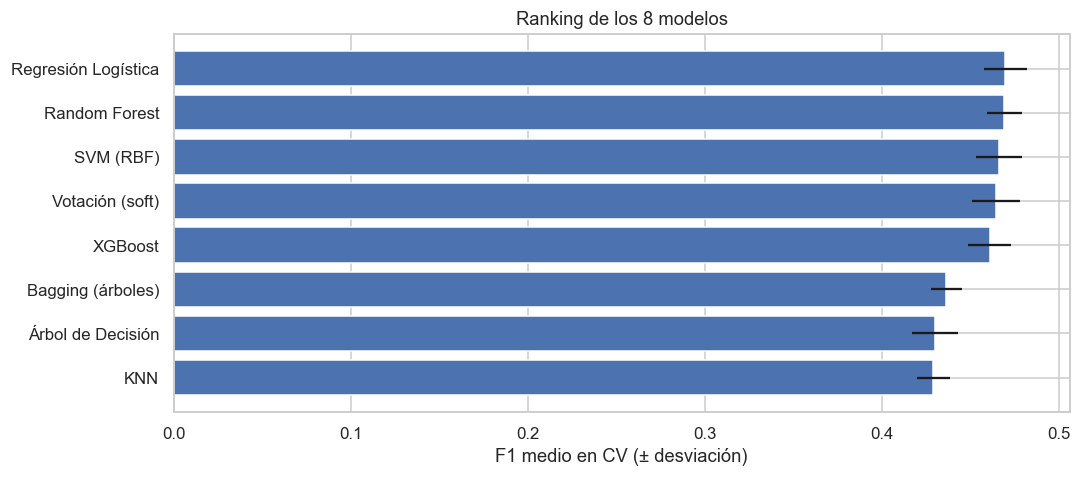

,modelo,f1_mean,f1_std,precision_mean,recall_mean,roc_auc_mean,tiempo_s
0,Regresión Logística,0.4696,0.0121,0.3414,0.7526,0.8010,1.7456
1,Random Forest,0.4690,0.0099,0.3445,0.7348,0.8002,6.6483
2,SVM (RBF),0.4659,0.0131,0.3359,0.7598,0.7943,24.0681
3,Votación (soft),0.4643,0.0138,0.3376,0.7434,0.7971,6.8899
4,XGBoost,0.4606,0.0123,0.3346,0.7392,0.7976,4.9979
5,Bagging (árboles),0.4363,0.0090,0.3196,0.6872,0.7654,12.0912
6,Árbol de Decisión,0.4298,0.0130,0.3058,0.7231,0.7520,1.7328
7,KNN,0.4289,0.0093,0.2983,0.7629,0.7687,3.4137


In [34]:
# 4.2.2 Ranking conjunto (clásicos + ensambles) por F1 en validación cruzada
df_todos = pd.concat([df_clasicos, df_ensambles]).sort_values("f1_mean", ascending=False).reset_index(drop=True)
todos_los_modelos = {**modelos_clasicos, **modelos_ensamble}   # Diccionario único con los 8 modelos sin entrenar

fig, eje = plt.subplots(figsize=(10, 4.5))
# xerr dibuja ± una desviación estándar: barras solapadas sugieren diferencias no concluyentes
eje.barh(df_todos["modelo"], df_todos["f1_mean"], xerr=df_todos["f1_std"], color="#4C72B0")
eje.invert_yaxis(); eje.set_xlabel("F1 medio en CV (± desviación)"); eje.set_title("Ranking de los 8 modelos")
plt.tight_layout(); guardar_figura("ranking_cv"); plt.show()
df_todos[["modelo", "f1_mean", "f1_std", "precision_mean", "recall_mean", "roc_auc_mean", "tiempo_s"]].round(4)

🔎 **Interpretación:** El ranking conjunto de los 8 modelos, con barras de error, muestra un **grupo de cabeza** de cinco modelos entre 0,46 y 0,47 (logística, Random Forest, SVM, votación y XGBoost) que no se distinguen entre sí. Detrás quedan el bagging, el árbol y KNN.
Los tres mejores (logística, Random Forest y SVM) pasan al ajuste de hiperparámetros. En la práctica, cuando varios modelos empatan conviene preferir el más **simple e interpretable**. Esa idea se retoma en la selección final.

### 4.3 Ajuste de hiperparámetros

#### 📘 Concepto: Búsqueda de hiperparámetros
Los **parámetros** se aprenden de los datos (coeficientes, divisiones de un árbol). Los **hiperparámetros** se fijan antes de
entrenar y controlan la complejidad del modelo (`C`, `max_depth`, `learning_rate`…). Ajustarlos es un problema de
optimización cuya función objetivo es el **F1 medio en validación cruzada**, nunca el test.

| Estrategia | Cómo explora | Comentario |
|---|---|---|
| *Grid search* | Todas las combinaciones de una rejilla | Costo exponencial en el número de hiperparámetros |
| *Random search* | $n$ combinaciones al azar de distribuciones | Con el mismo presupuesto suele encontrar mejores valores, porque pocos hiperparámetros importan de verdad (Bergstra y Bengio, 2012) |
| *Successive halving* | Muchos candidatos con pocos datos; solo los mejores pasan a la siguiente ronda con más datos | Muy eficiente para modelos costosos como el SVM; con muy pocos datos en las primeras rondas la selección puede volverse ruidosa |

**Distribuciones:** la log-uniforme se usa cuando importa el **orden de magnitud** (`C` de 0,001 a 100); la uniforme
cuando importa el valor en un rango acotado (fracciones de 0,6 a 1,0).

**Riesgo:** probar muchas combinaciones sobre los mismos folds sobreajusta a la validación (Cawley y Talbot, 2010). Por
eso el test se reserva para la estimación final.

In [35]:
# 4.3.1 Espacios de búsqueda, qué controla cada hiperparámetro y por qué se eligió cada rango
# El prefijo "modelo__" dirige el hiperparámetro al paso "modelo" del pipeline (sintaxis paso__parametro)
ESPACIOS = {
    "Regresión Logística": {"modelo__C": loguniform(1e-3, 1e2)},
    "KNN": {"modelo__n_neighbors": randint(5, 101), "modelo__weights": ["uniform", "distance"], "modelo__p": [1, 2]},
    "Árbol de Decisión": {"modelo__max_depth": randint(3, 21), "modelo__min_samples_leaf": randint(5, 201),
                          "modelo__criterion": ["gini", "entropy"]},
    "SVM (RBF)": {"modelo__C": loguniform(1e-2, 1e2), "modelo__gamma": loguniform(1e-4, 1e0)},
    "Random Forest": {"modelo__n_estimators": randint(100, 501), "modelo__max_depth": [8, 12, 16, 20, None],
                      "modelo__min_samples_leaf": randint(1, 51), "modelo__max_features": ["sqrt", "log2", 0.5]},
    "Votación (soft)": {"modelo__weights": [[1, 1, 1], [2, 1, 1], [1, 2, 1], [1, 1, 2], [3, 2, 1], [1, 2, 3]]},
    "Bagging (árboles)": {"modelo__n_estimators": randint(50, 301), "modelo__max_samples": uniform(0.5, 0.5),
                          "modelo__max_features": uniform(0.5, 0.5), "modelo__estimator__max_depth": [None, 10, 15, 20]},
    "XGBoost": {"modelo__n_estimators": randint(100, 601), "modelo__learning_rate": loguniform(0.01, 0.3),
                "modelo__max_depth": randint(2, 9), "modelo__subsample": uniform(0.6, 0.4),
                "modelo__colsample_bytree": uniform(0.6, 0.4), "modelo__min_child_weight": randint(1, 11),
                "modelo__reg_lambda": loguniform(1e-2, 1e1)},
}
if isinstance(BALANCEADOR, SMOTE):   # El número de vecinos de SMOTE también es un hiperparámetro del pipeline
    for espacio in ESPACIOS.values():
        espacio["balanceo__k_neighbors"] = [3, 5, 7, 9]   # "balanceo__" apunta al paso de SMOTE

# Qué controla cada hiperparámetro (columna exigida por la rúbrica); las excepciones por modelo van aparte
QUE_CONTROLA = {
    "modelo__C": "Inverso de la regularización: valores altos ajustan más a los datos (menos sesgo, más varianza)",
    "modelo__n_neighbors": "Vecinos que votan: pocos = frontera irregular (varianza); muchos = frontera suave (sesgo)",
    "modelo__weights": "Peso de los vecinos: iguales ('uniform') o inversos a la distancia ('distance')",
    "modelo__p": "Métrica de Minkowski: 1 = Manhattan, 2 = Euclidiana",
    "modelo__max_depth": "Profundidad máxima de los árboles: limita las interacciones modeladas y el sobreajuste",
    "modelo__min_samples_leaf": "Mínimo de registros por hoja: suaviza las predicciones y reduce el sobreajuste",
    "modelo__criterion": "Medida de impureza para elegir divisiones (Gini o entropía)",
    "modelo__gamma": "Alcance del kernel RBF: alto = influencia local (fronteras complejas); bajo = fronteras suaves",
    "modelo__n_estimators": "Número de árboles del ensamble: más árboles reducen la varianza a mayor costo",
    "modelo__max_features": "Variables candidatas en cada división: decorrelaciona los árboles",
    "modelo__max_samples": "Fracción de registros (bootstrap) con la que se entrena cada árbol",
    "modelo__estimator__max_depth": "Profundidad de cada árbol base del bagging",
    "modelo__learning_rate": "Tamaño del paso con que cada árbol corrige a los anteriores (shrinkage)",
    "modelo__subsample": "Fracción de registros usada en cada ronda de boosting (regularización estocástica)",
    "modelo__colsample_bytree": "Fracción de variables usada por cada árbol",
    "modelo__min_child_weight": "Peso mínimo (hessiano) por hoja: valores altos hacen el modelo más conservador",
    "modelo__reg_lambda": "Regularización L2 sobre los pesos de las hojas",
    "balanceo__k_neighbors": "Vecinos que usa SMOTE para interpolar registros sintéticos de la clase minoritaria",
}
# Mismo nombre, distinto significado según el modelo: (modelo, hiperparámetro) -> descripción específica
QUE_CONTROLA_ESPECIFICO = {
    ("SVM (RBF)", "modelo__C"): "Penalización por violar el margen: alto = margen estrecho ajustado a los datos; bajo = margen amplio",
    ("Votación (soft)", "modelo__weights"): "Peso de cada modelo en el promedio de probabilidades del voto suave",
    ("Bagging (árboles)", "modelo__max_features"): "Fracción de variables que recibe cada árbol del bagging",
    ("XGBoost", "modelo__max_depth"): "Profundidad de cada árbol débil: orden de las interacciones capturadas",
    ("XGBoost", "modelo__n_estimators"): "Número de rondas de boosting (árboles secuenciales)",
}
# Por qué se eligió cada rango (columna exigida por la rúbrica)
RAZON_RANGO = {
    "modelo__C": "Escala logarítmica 10⁻³–10²: desde regularización fuerte hasta casi nula",
    "modelo__n_neighbors": "5–100: evita el ruido de k muy pequeño sin llegar a fronteras triviales",
    "modelo__weights": "Las dos opciones que ofrece scikit-learn",
    "modelo__p": "Las distancias más usadas con variables escaladas y binarias",
    "modelo__max_depth": "Desde árboles poco profundos hasta sin límite (None)",
    "modelo__min_samples_leaf": "Desde hojas finas hasta hojas grandes que suavizan",
    "modelo__criterion": "Los dos criterios clásicos de impureza",
    "modelo__gamma": "10⁻⁴–1 en escala log, alrededor del valor 'scale' ≈ 1/(n_variables·varianza)",
    "modelo__n_estimators": "Por encima del rango la ganancia suele ser marginal y crece el tamaño del modelo",
    "modelo__max_features": "'sqrt' y 'log2' (valores de la literatura) y 0,5 (más variables por división)",
    "modelo__max_samples": "50 %–100 % de los registros por estimador",
    "modelo__estimator__max_depth": "Árboles completos (None) o limitados para reducir varianza",
    "modelo__learning_rate": "0,01–0,3 en escala log: rango recomendado en la documentación de XGBoost",
    "modelo__subsample": "0,6–1,0: por debajo de 0,6 el modelo suele subajustar",
    "modelo__colsample_bytree": "0,6–1,0: por debajo de 0,6 se pierden variables relevantes",
    "modelo__min_child_weight": "1–10: de hojas finas a conservadoras",
    "modelo__reg_lambda": "0,01–10 en escala log alrededor del valor por defecto (1)",
    "balanceo__k_neighbors": "3–9 alrededor del valor por defecto de SMOTE (5)",
}
RAZON_RANGO_ESPECIFICO = {   # Razones que dependen del modelo
    ("Árbol de Decisión", "modelo__max_depth"): "3–20: por debajo de 3 subajusta; por encima de 20 memoriza 21 mil registros",
    ("Árbol de Decisión", "modelo__min_samples_leaf"): "5–200: hojas con entre ~0,03 % y ~1 % del entrenamiento",
    ("Random Forest", "modelo__min_samples_leaf"): "1–50: el promedio de árboles tolera hojas más finas",
    ("SVM (RBF)", "modelo__C"): "10⁻²–10² en escala log: rango estándar para SVM",
    ("Votación (soft)", "modelo__weights"): "Combinaciones que priorizan a cada modelo o los dejan iguales",
    ("XGBoost", "modelo__max_depth"): "2–8: los árboles débiles del boosting deben ser poco profundos",
}


def describir_rango(dist):
    """Texto legible de un espacio de búsqueda (lista o distribución de scipy)."""
    if isinstance(dist, list):                    # Opciones discretas: se listan
        return ", ".join(map(str, dist))
    a, b = dist.args[:2]                          # Parámetros con que se creó la distribución
    nombre = dist.dist.name                       # Tipo de distribución de scipy
    if nombre == "randint":                       # randint(a, b) genera enteros en [a, b-1]
        return f"enteros en [{a}, {b - 1}]"
    if nombre in ("loguniform", "reciprocal"):    # Uniforme en escala logarítmica
        return f"log-uniforme en [{a:g}, {b:g}]"
    if nombre == "uniform":                       # uniform(loc, scale) cubre [loc, loc + scale]
        return f"uniforme en [{a:g}, {a + b:g}]"
    return str(dist)


# Vista de todos los espacios definidos (solo se buscará en los 3 mejores modelos)
pd.DataFrame([{"modelo": m, "hiperparametro": p, "rango": describir_rango(d)} for m, e in ESPACIOS.items() for p, d in e.items()])

,modelo,hiperparametro,rango
0,Regresión Logística,modelo__C,"log-uniforme en [0.001, 100]"
1,KNN,modelo__n_neighbors,"enteros en [5, 100]"
2,KNN,modelo__weights,"uniform, distance"
3,KNN,modelo__p,"1, 2"
4,Árbol de Decisión,modelo__max_depth,"enteros en [3, 20]"
5,Árbol de Decisión,modelo__min_samples_leaf,"enteros en [5, 200]"
6,Árbol de Decisión,modelo__criterion,"gini, entropy"
7,SVM (RBF),modelo__C,"log-uniforme en [0.01, 100]"
8,SVM (RBF),modelo__gamma,"log-uniforme en [0.0001, 1]"
9,Random Forest,modelo__n_estimators,"enteros en [100, 500]"


🔎 **Interpretación:** La tabla lista los espacios de búsqueda de los 8 modelos, aunque solo se ajustarán los 3 mejores del ranking.
Observa las distribuciones:
- **Log-uniforme:** para `C` y `gamma`, donde importa el orden de magnitud.
- **Enteros:** para `n_estimators` y `max_depth`.
- **Listas:** para opciones discretas.

No aparece `k_neighbors` de SMOTE porque el balanceador elegido fue el submuestreo, que no tiene ese hiperparámetro. El código lo agrega solo si corresponde.

In [36]:
# 4.3.2 Búsqueda aleatoria (o por mitades si el SVM se entrena con SMOTE) sobre los 3 mejores modelos del ranking
MODELOS_A_AJUSTAR = df_todos["modelo"].head(3).tolist()   # Presupuesto de cómputo concentrado en los candidatos fuertes
busquedas = {}
for nombre in MODELOS_A_AJUSTAR:
    inicio = time.time()
    pipe = crear_pipeline(clone(todos_los_modelos[nombre]))   # Pipeline completo: sin fuga durante la búsqueda
    # Mitades sucesivas solo si el SVM es costoso (con SMOTE el entrenamiento crece a ~28 mil filas por fold).
    # Con submuestreo cada fold queda en ~6 mil filas y la búsqueda aleatoria es barata. Además, en una prueba
    # previa las primeras rondas por mitades usaban tan pocos datos que el F1 colapsaba y la selección era casi al azar.
    if nombre == "SVM (RBF)" and isinstance(BALANCEADOR, SMOTE):
        # Mitades sucesivas: 16 candidatos con pocos datos; en cada ronda sobrevive la mitad y recibe el doble de datos
        busqueda = HalvingRandomSearchCV(pipe, ESPACIOS[nombre], n_candidates=16, factor=2, cv=CV, scoring="f1",
                                         random_state=RANDOM_STATE, n_jobs=-1)
    else:
        # return_train_score permite comparar F1 de entrenamiento y de validación (diagnóstico de sobreajuste)
        busqueda = RandomizedSearchCV(pipe, ESPACIOS[nombre], n_iter=N_ITER_BUSQUEDA, cv=CV, scoring="f1",
                                      random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True)
    busquedas[nombre] = busqueda.fit(X_train, y_train)   # Al terminar, reentrena la mejor combinación con todo el 70 %
    print(f"{nombre:<22} mejor F1 CV = {busqueda.best_score_:.4f} ({time.time() - inicio:.0f} s)\n  {busqueda.best_params_}")

Regresión Logística    mejor F1 CV = 0.4701 (31 s)
  {'modelo__C': np.float64(0.14445251022763064)}


Random Forest          mejor F1 CV = 0.4696 (163 s)
  {'modelo__max_depth': 20, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 14, 'modelo__n_estimators': 341}


SVM (RBF)              mejor F1 CV = 0.4655 (1045 s)
  {'modelo__C': np.float64(0.6672367170464207), 'modelo__gamma': np.float64(0.13826232179369857)}


🔎 **Interpretación:** Resultados de la búsqueda aleatoria (20 combinaciones × 5 folds por modelo):
- **Regresión Logística:** mejor `C = 0,144` (algo más de regularización que el valor por defecto, 1,0). F1 en CV = 0,4701, en unos 30 s.
- **Random Forest:** 341 árboles, `max_depth = 20`, `min_samples_leaf = 14`, `max_features = 'sqrt'`. F1 = 0,4696, en 2–4 minutos.
- **SVM:** `C = 0,67` y `gamma = 0,138`. F1 = 0,4655, en unos 15–20 minutos: fue, con diferencia, la búsqueda más costosa. (Los tiempos exactos aparecen en la salida y varían entre ejecuciones; el orden de magnitud es estable.)

Las mejoras frente a los valores por defecto son mínimas (≤ 0,0006). Los hiperparámetros por defecto ya estaban cerca del óptimo y **el límite está en los datos, no en la configuración**.

*Nota metodológica:* una prueba previa con búsqueda por mitades sucesivas para el SVM colapsó (F1 ≈ 0,37), porque sus primeras rondas usaban tan pocos datos que el F1 no discriminaba. Por eso se usa búsqueda aleatoria cuando el balanceo es por submuestreo.

In [37]:
# 4.3.3 Tabla explicativa: qué controla, rango, razón, valor final y efecto observado de cada hiperparámetro
def resultados_busqueda(busqueda):
    """cv_results_ como DataFrame; en búsqueda por mitades se usa la 1.ª ronda (todos con el mismo recurso)."""
    res = pd.DataFrame(busqueda.cv_results_)
    return res[res["iter"] == 0] if "iter" in res else res   # Comparar candidatos con distinto recurso sería injusto


def es_numerico(valores):
    """True si todos los valores probados son números (no listas, textos ni None)."""
    return all(isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool) for v in valores)


def efecto_hiperparametro(busqueda, param):
    """Resume cómo se asoció el valor del hiperparámetro con el F1 medio de validación."""
    res = resultados_busqueda(busqueda)
    valores, score = list(res[f"param_{param}"]), res["mean_test_score"].to_numpy()
    if es_numerico(valores):
        # Spearman: ¿a mayor valor del hiperparámetro, mayor (o menor) F1? Es una asociación, no un efecto aislado
        rho, p_valor = stats.spearmanr(np.array(valores, dtype=float), score)
        if p_valor < 0.05:
            return f"ρ Spearman = {rho:+.2f} (p = {p_valor:.3f}): aumentarlo {'mejoró' if rho > 0 else 'empeoró'} el F1"
        return f"ρ Spearman = {rho:+.2f} (p = {p_valor:.3f}): sin efecto significativo en el rango"
    # Categórico: F1 medio de las combinaciones que usaron cada opción
    etiquetas = [etiqueta_valor(v) for v in valores]   # Etiquetas legibles (una Serie convertiría 16 en 16.0 y None en nan)
    medias = pd.Series(score).groupby(etiquetas).mean().sort_values(ascending=False)
    return "F1 medio por valor: " + "; ".join(f"{k} = {v:.3f}" for k, v in medias.items())


def etiqueta_valor(valor):
    """Texto legible de un valor probado: 'None' en lugar de nan y enteros sin decimales."""
    if valor is None or (isinstance(valor, (float, np.floating)) and np.isnan(valor)):
        return "None"
    if isinstance(valor, (float, np.floating)) and float(valor).is_integer():
        return str(int(valor))   # 16.0 -> "16"
    return str(valor)


def formatear(valor):
    """Cuatro cifras significativas para decimales; texto para el resto."""
    return f"{valor:.4g}" if isinstance(valor, (float, np.floating)) else str(valor)


filas = []
for nombre, busqueda in busquedas.items():
    for param, dist in ESPACIOS[nombre].items():   # Una fila por hiperparámetro ajustado (tabla 4.3 del informe)
        filas.append({"modelo": nombre,
                      "hiperparametro": param.replace("modelo__", "").replace("balanceo__", "SMOTE: "),
                      "que_controla": QUE_CONTROLA_ESPECIFICO.get((nombre, param), QUE_CONTROLA[param]),
                      "rango_probado": describir_rango(dist),
                      "razon_rango": RAZON_RANGO_ESPECIFICO.get((nombre, param), RAZON_RANGO[param]),
                      "valor_final": formatear(busqueda.best_params_[param]),
                      "efecto": efecto_hiperparametro(busqueda, param)})
tabla_hiper = guardar_tabla(pd.DataFrame(filas), "ajuste_hiperparametros")
tabla_hiper

,modelo,hiperparametro,que_controla,rango_probado,razon_rango,valor_final,efecto
0,Regresión Logística,C,Inverso de la regularización: valores altos aj...,"log-uniforme en [0.001, 100]",Escala logarítmica 10⁻³–10²: desde regularizac...,0.1445,ρ Spearman = +0.63 (p = 0.003): aumentarlo mej...
1,Random Forest,n_estimators,Número de árboles del ensamble: más árboles re...,"enteros en [100, 500]",Por encima del rango la ganancia suele ser mar...,341,ρ Spearman = -0.06 (p = 0.794): sin efecto sig...
2,Random Forest,max_depth,Profundidad máxima de los árboles: limita las ...,"8, 12, 16, 20, None",Desde árboles poco profundos hasta sin límite ...,20,F1 medio por valor: 16 = 0.466; 20 = 0.466; No...
3,Random Forest,min_samples_leaf,Mínimo de registros por hoja: suaviza las pred...,"enteros en [1, 50]",1–50: el promedio de árboles tolera hojas más ...,14,ρ Spearman = -0.19 (p = 0.423): sin efecto sig...
4,Random Forest,max_features,Variables candidatas en cada división: decorre...,"sqrt, log2, 0.5",'sqrt' y 'log2' (valores de la literatura) y 0...,sqrt,F1 medio por valor: sqrt = 0.466; log2 = 0.466...
5,SVM (RBF),C,Penalización por violar el margen: alto = marg...,"log-uniforme en [0.01, 100]",10⁻²–10² en escala log: rango estándar para SVM,0.6672,ρ Spearman = +0.69 (p = 0.001): aumentarlo mej...
6,SVM (RBF),gamma,Alcance del kernel RBF: alto = influencia loca...,"log-uniforme en [0.0001, 1]","10⁻⁴–1 en escala log, alrededor del valor 'sca...",0.1383,ρ Spearman = -0.35 (p = 0.125): sin efecto sig...


🔎 **Interpretación:** La tabla explicativa (tabla 4.3 del informe) resume por hiperparámetro qué controla, el rango, la razón del rango, el valor final y el efecto observado:
- **`C` de la logística:** aumentarlo mejoró el F1 (ρ = +0,63, p = 0,003). Los valores muy pequeños (regularización excesiva) empeoran el modelo y, a partir de ~0,1, el F1 se estabiliza.
- **`C` del SVM:** también tiene efecto positivo significativo (ρ = +0,69).
- **Random Forest:** ninguno de sus hiperparámetros tiene efecto significativo en los rangos probados (p > 0,4). Es un modelo robusto a su configuración, como anticipa el 📘.
- **`gamma` del SVM:** su efecto no es significativo en el rango (p = 0,125).

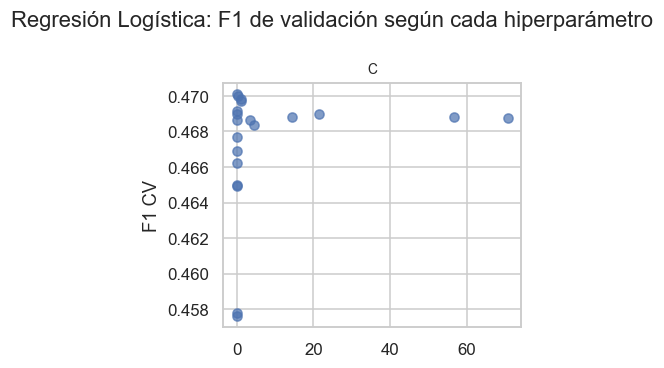

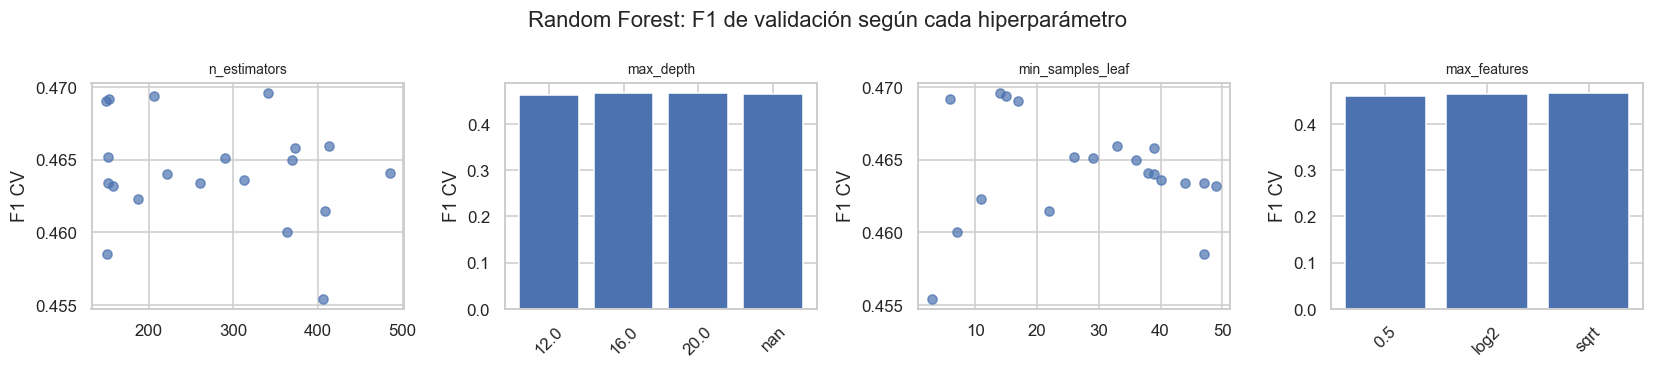

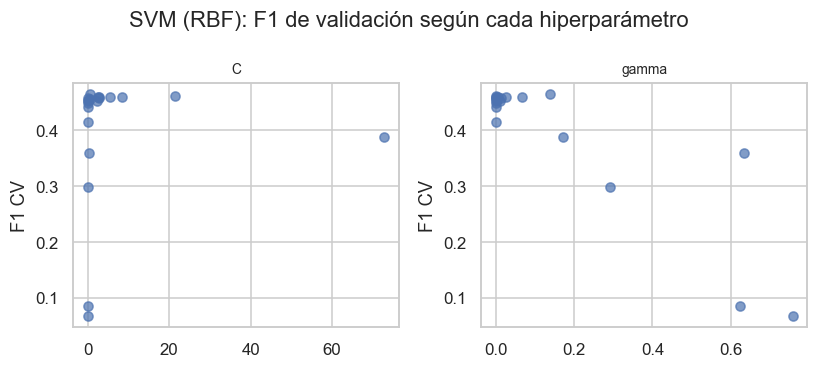

In [38]:
# 4.3.4 Efecto visual de cada hiperparámetro sobre el F1 de validación (un gráfico por modelo ajustado)
for nombre, busqueda in busquedas.items():
    res = resultados_busqueda(busqueda)
    params = list(ESPACIOS[nombre])
    fig, ejes = plt.subplots(1, len(params), figsize=(3.8 * len(params), 3.4), squeeze=False)   # Un panel por hiperparámetro
    for eje, param in zip(ejes[0], params):
        valores = list(res[f"param_{param}"])
        if es_numerico(valores):
            eje.scatter(np.array(valores, dtype=float), res["mean_test_score"], alpha=0.7)   # Nube: tendencia del F1
        else:
            etiquetas = pd.Series(valores).astype(str)
            medias = res["mean_test_score"].groupby(etiquetas.to_numpy()).mean()   # F1 medio por opción
            eje.bar(medias.index, medias.values, color="#4C72B0"); eje.tick_params(axis="x", rotation=45)
        eje.set_title(param.replace("modelo__", "").replace("balanceo__", "SMOTE "), fontsize=9)
        eje.set_ylabel("F1 CV")
    fig.suptitle(f"{nombre}: F1 de validación según cada hiperparámetro")
    plt.tight_layout(); guardar_figura(f"hiperparametros_{ALIAS.get(nombre, nombre.split()[0].lower())}"); plt.show()

🔎 **Interpretación:** Los gráficos muestran la forma del efecto:
- **Logística:** el F1 sube rápidamente cuando `C` sale de valores cercanos a 0 y luego forma una **meseta** (~0,469–0,470). Más allá de C ≈ 0,1 la regularización deja de importar.
- **Random Forest:** nubes sin tendencia, coherentes con la ausencia de efecto significativo.
- **SVM:** los valores de `C` muy pequeños dan los peores F1.

Leer estas gráficas ayuda a decidir si vale la pena ampliar un rango. Aquí ninguna curva sugiere que el óptimo esté fuera de los rangos probados.

#### 📘 Concepto: Umbral de decisión
Un clasificador probabilístico entrega $\hat p(x)$ y decide $\hat y = \mathbb{1}[\hat p(x) \ge t]$. El umbral por defecto
$t = 0{,}5$ no es óptimo cuando las clases están desbalanceadas o cuando los errores tienen costos distintos:
- Bajar $t$ ⇒ más positivos predichos ⇒ **sube el Recall** y baja la Precision.
- Subir $t$ ⇒ lo contrario.

`TunedThresholdClassifierCV` busca el $t$ que maximiza el F1 **con validación cruzada sobre el entrenamiento**, de modo que
el test no se usa para elegirlo. El umbral es, en la práctica, un hiperparámetro más del sistema de decisión.

In [39]:
# 4.3.5 Ajuste del umbral de decisión (maximiza F1 en CV usando solo entrenamiento) y mejora frente a la versión base
modelos_umbral = {}
for nombre, busqueda in busquedas.items():
    # Se parte del mejor pipeline de la búsqueda; el umbral se elige con los mismos 5 folds
    modelos_umbral[nombre] = TunedThresholdClassifierCV(busqueda.best_estimator_, scoring="f1", cv=CV,
                                                        n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train)
# Evolución del F1 en CV: base (4.1/4.2) -> hiperparámetros ajustados -> + umbral óptimo
tabla_mejora = pd.DataFrame([{
    "modelo": nombre,
    "f1_cv_base": df_todos.set_index("modelo").loc[nombre, "f1_mean"],
    "f1_cv_ajustado": busqueda.best_score_,
    "f1_cv_ajustado_umbral": modelos_umbral[nombre].best_score_,
    "umbral_optimo": modelos_umbral[nombre].best_threshold_} for nombre, busqueda in busquedas.items()])
tabla_mejora["mejora_total"] = tabla_mejora["f1_cv_ajustado_umbral"] - tabla_mejora["f1_cv_base"]   # Ganancia acumulada
guardar_tabla(tabla_mejora.round(4), "mejora_ajuste")
tabla_mejora.round(4)

,modelo,f1_cv_base,f1_cv_ajustado,f1_cv_ajustado_umbral,umbral_optimo,mejora_total
0,Regresión Logística,0.4696,0.4701,0.4856,0.6152,0.0160
1,Random Forest,0.4690,0.4696,0.4815,0.5804,0.0125
2,SVM (RBF),0.4659,0.4655,0.4748,0.4316,0.0089


🔎 **Interpretación:** El ajuste del **umbral de decisión** aporta la mayor mejora de toda la fase:

| Modelo | F1 en CV | Umbral óptimo |
|---|---|---|
| Regresión Logística | 0,4701 → 0,4856 | 0,615 |
| Random Forest | 0,4696 → 0,4815 | 0,580 |
| SVM | 0,4655 → 0,4748 | 0,432 |

**Por qué:** el submuestreo deja al modelo "creyendo" que la mitad de los estudiantes son positivos, así que sus probabilidades quedan infladas. Subir el umbral por encima de 0,5 corrige ese sesgo y equilibra Precision y Recall. Es la idea del 📘: el umbral es un hiperparámetro más, y en problemas desbalanceados suele importar más que la configuración del algoritmo.

### 🧠 Para profundizar — Fase 4: Modelamiento
**Ideas clave**
- La validación cruzada estima el desempeño esperado **y su variabilidad**; comparar solo medias puede engañar.
- Todo lo que aprende de los datos va en el pipeline, para que la validación sea honesta y el despliegue sea idéntico.
- Bagging reduce varianza, boosting reduce sesgo y la votación aprovecha modelos que se equivocan distinto.
- Los hiperparámetros se eligen en validación; el umbral de decisión también es un hiperparámetro.

**Preguntas de repaso**
1. ¿Por qué Random Forest suele superar a un árbol de decisión individual? Explícalo con la fórmula de varianza del promedio.
2. ¿Qué diferencia hay entre `max_depth` en Random Forest y en XGBoost, y por qué los rangos elegidos son distintos?
3. ¿Por qué la búsqueda aleatoria es más eficiente que la búsqueda en rejilla con el mismo número de pruebas?
4. Si el F1 de entrenamiento es 0,95 y el de validación 0,50, ¿qué está pasando y qué hiperparámetros lo corregirían?

**Ejercicios**
- Agrega `LightGBM` como segundo modelo de boosting y compáralo con XGBoost en tiempo y F1.
- Duplica `N_ITER_BUSQUEDA` y verifica si el mejor F1 en CV cambia de forma relevante (rendimientos decrecientes).

**Referencias**
- James, G., Witten, D., Hastie, T. y Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2.ª ed.). Springer (caps. 4, 5, 8 y 9).
- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer (caps. 7, 10, 12 y 15).
- Breiman, L. (1996). Bagging predictors. *Machine Learning*, 24, 123–140. — Breiman, L. (2001). Random forests. *Machine Learning*, 45, 5–32.
- Cortes, C. y Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, 273–297.
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *Annals of Statistics*, 29(5), 1189–1232.
- Chen, T. y Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD '16*, 785–794.
- Bergstra, J. y Bengio, Y. (2012). Random search for hyper-parameter optimization. *JMLR*, 13, 281–305.
- Cawley, G. C. y Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *JMLR*, 11, 2079–2107.

## 5. Evaluación
### 5.1 Resultados en el conjunto de prueba (30 %)

#### 📘 Concepto: Métricas de clasificación
Todas parten de la **matriz de confusión**:

| | Predicho 1 | Predicho 0 |
|---|---|---|
| **Real 1** | VP (verdadero positivo) | FN (falso negativo) |
| **Real 0** | FP (falso positivo) | VN (verdadero negativo) |

| Métrica | Fórmula | Pregunta que responde |
|---|---|---|
| Accuracy | $\frac{VP+VN}{VP+VN+FP+FN}$ | ¿Qué fracción acierta? (engañosa con desbalance) |
| Precision | $\frac{VP}{VP+FP}$ | De los que predigo "alto", ¿cuántos lo son? |
| Recall (sensibilidad) | $\frac{VP}{VP+FN}$ | De los que son "alto", ¿cuántos detecto? |
| F1 | $2\cdot\frac{P\cdot R}{P+R}$ | Media armónica: solo es alta si P **y** R lo son |
| ROC-AUC | Área bajo la curva TPR vs FPR | Probabilidad de que un positivo reciba mayor puntaje que un negativo (independiente del umbral) |
| PR-AUC | Área bajo la curva Precision-Recall | Más informativa que ROC-AUC con clases desbalanceadas (Saito y Rehmsmeier, 2015); el azar vale la prevalencia (~0,17) |

El conjunto de prueba se usa **una sola vez**, al final, para estimar el desempeño en datos no vistos.

In [40]:
# 5.1.1 Utilidades de evaluación y evaluación de todos los candidatos en test
def puntaje_positivo(modelo, X):
    """Probabilidad de la clase positiva (o función de decisión si el modelo no expone probabilidades)."""
    return modelo.predict_proba(X)[:, 1] if hasattr(modelo, "predict_proba") else modelo.decision_function(X)


def metricas_test(nombre, modelo, X, y):
    """Métricas de umbral (con la clase predicha) y de ranking (con el puntaje continuo)."""
    prediccion, puntaje = modelo.predict(X), puntaje_positivo(modelo, X)
    return {"modelo": nombre, "accuracy": accuracy_score(y, prediccion), "precision": precision_score(y, prediccion),
            "recall": recall_score(y, prediccion), "f1": f1_score(y, prediccion),
            "roc_auc": roc_auc_score(y, puntaje), "pr_auc": average_precision_score(y, puntaje)}


# Los 8 modelos base se reentrenan con TODO el 70 %; los ajustados ya fueron reentrenados por la búsqueda
candidatos = {}
for nombre, modelo in todos_los_modelos.items():
    candidatos[f"{nombre} (base)"] = crear_pipeline(clone(modelo)).fit(X_train, y_train)
for nombre, busqueda in busquedas.items():
    candidatos[f"{nombre} (ajustado)"] = busqueda.best_estimator_                  # Umbral por defecto (0,5)
    candidatos[f"{nombre} (ajustado + umbral)"] = modelos_umbral[nombre]          # Umbral óptimo de 4.3.5

# Primera y única evaluación en test: 8 base + 3 ajustados + 3 ajustados con umbral = 14 candidatos
df_test = pd.DataFrame([metricas_test(n, m, X_test, y_test) for n, m in candidatos.items()])
df_test = df_test.sort_values("f1", ascending=False).reset_index(drop=True)
guardar_tabla(df_test.round(4), "resultados_test")   # Tabla 5.1 del informe
df_test.round(4)

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regresión Logística (ajustado + umbral),0.7789,0.3996,0.5795,0.4730,0.7975,0.4613
1,Random Forest (ajustado + umbral),0.7723,0.3916,0.5957,0.4726,0.7967,0.4800
2,SVM (RBF) (ajustado + umbral),0.7663,0.3845,0.6067,0.4707,0.7799,0.3952
3,Random Forest (ajustado),0.7097,0.3386,0.7294,0.4625,0.7967,0.4800
4,XGBoost (base),0.7036,0.3353,0.7443,0.4623,0.7995,0.4823
5,Regresión Logística (ajustado),0.7041,0.3345,0.7359,0.4599,0.7975,0.4613
6,Random Forest (base),0.7079,0.3362,0.7249,0.4594,0.7967,0.4803
7,Regresión Logística (base),0.7026,0.3334,0.7378,0.4593,0.7975,0.4606
8,SVM (RBF) (base),0.6961,0.3292,0.7469,0.4570,0.7904,0.4040
9,SVM (RBF) (ajustado),0.6988,0.3298,0.7359,0.4555,0.7799,0.3952


🔎 **Interpretación:** En el test (9.000 estudiantes nunca usados), los tres modelos con umbral ajustado quedan arriba:

| Modelo | F1 | Precision | Recall | Accuracy |
|---|---|---|---|---|
| Regresión Logística + umbral | 0,4730 | 0,400 | 0,580 | 0,779 |
| Random Forest + umbral | 0,4726 | — | — | — |
| SVM + umbral | 0,4707 | — | — | — |

- Sin ajustar el umbral, el Recall es mayor (~0,74) pero la Precision cae a ~0,33. El umbral cambia el **punto de operación**, no la capacidad de ordenar: la ROC-AUC de la logística es 0,7975 con y sin umbral.
- Los resultados en test son muy parecidos a los de CV (0,47 frente a 0,486), así que la validación cruzada fue una buena estimación.

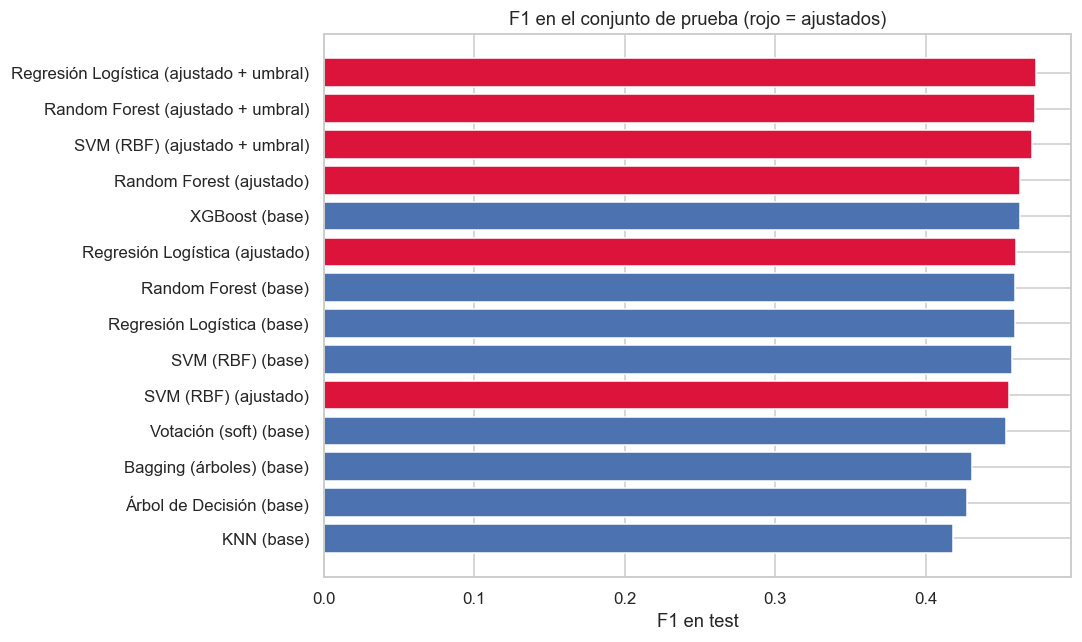

In [41]:
# 5.1.2 Comparación visual del F1 en test de todos los candidatos
# Colores distintos para los ajustados: permite ver el aporte del ajuste de hiperparámetros y del umbral
fig, eje = plt.subplots(figsize=(10, 6))
colores = ["crimson" if "ajustado" in n else "#4C72B0" for n in df_test["modelo"]]
eje.barh(df_test["modelo"], df_test["f1"], color=colores)
eje.invert_yaxis(); eje.set_xlabel("F1 en test"); eje.set_title("F1 en el conjunto de prueba (rojo = ajustados)")
plt.tight_layout(); guardar_figura("f1_test"); plt.show()

🔎 **Interpretación:** El gráfico separa dos grupos: arriba, los modelos con umbral ajustado (F1 ≈ 0,47); en el medio, los modelos base y ajustados sin umbral de la familia fuerte, XGBoost y la votación (0,45–0,46); abajo, el bagging, el árbol y KNN (0,42–0,43).
El salto más grande no viene de cambiar de algoritmo, sino de **ajustar el umbral**. Esta lección se repite en muchos problemas desbalanceados reales.

### 5.2 Selección del modelo final
El modelo se elige por su **F1 en validación cruzada**, no por el de test: elegir con el test introduce sesgo de selección
(el test dejaría de ser una estimación independiente). El test se usa para confirmar y para las pruebas estadísticas.

In [42]:
# 5.2.1 Candidato final (mayor F1 en CV) y rival más fuerte de otra familia de modelos
cv_f1 = {}   # F1 en CV de cada candidato ajustado (con y sin umbral óptimo)
for nombre, busqueda in busquedas.items():
    cv_f1[f"{nombre} (ajustado)"] = busqueda.best_score_
    cv_f1[f"{nombre} (ajustado + umbral)"] = modelos_umbral[nombre].best_score_
NOMBRE_FINAL = max(cv_f1, key=cv_f1.get)                   # Criterio de selección: F1 en validación
FAMILIA_FINAL = NOMBRE_FINAL.split(" (")[0]                # Nombre del algoritmo sin el sufijo
# El rival es el mejor candidato de OTRO algoritmo: compararlo con su propia variante no aportaría evidencia
RIVAL = max((k for k in cv_f1 if k.split(" (")[0] != FAMILIA_FINAL), key=cv_f1.get)
FAMILIA_RIVAL = RIVAL.split(" (")[0]
modelo_final = candidatos[NOMBRE_FINAL]

# Comparación lado a lado del F1 en CV y en test: si el orden se mantiene, la selección es consistente
tabla_seleccion_cv = (pd.DataFrame({"candidato": list(cv_f1), "f1_cv": list(cv_f1.values())})
                      .merge(df_test[["modelo", "f1"]].rename(columns={"modelo": "candidato", "f1": "f1_test"}), on="candidato")
                      .sort_values("f1_cv", ascending=False).round(4))
print(f"Modelo final: {NOMBRE_FINAL} | Rival: {RIVAL}")
tabla_seleccion_cv

Modelo final: Regresión Logística (ajustado + umbral) | Rival: Random Forest (ajustado + umbral)


,candidato,f1_cv,f1_test
1,Regresión Logística (ajustado + umbral),0.4856,0.4730
3,Random Forest (ajustado + umbral),0.4815,0.4726
5,SVM (RBF) (ajustado + umbral),0.4748,0.4707
0,Regresión Logística (ajustado),0.4701,0.4599
2,Random Forest (ajustado),0.4696,0.4625
4,SVM (RBF) (ajustado),0.4655,0.4555


🔎 **Interpretación:** El candidato con mayor F1 en validación cruzada es la **Regresión Logística (ajustado + umbral)** (0,4856). El rival más fuerte de otra familia es Random Forest (ajustado + umbral), con 0,4815.
El orden por CV coincide con el orden en test (0,4730 frente a 0,4726): la selección es **consistente**. Elegir por CV y confirmar con el test evita el sesgo de selección descrito en 5.2.

#### 📘 Concepto: Comparación estadística de modelos
Que un modelo tenga un F1 mayor no prueba que sea **mejor**: la diferencia puede deberse al azar de la muestra. Se usan
tres herramientas complementarias:

1. **Intervalo de confianza bootstrap** (Efron y Tibshirani, 1993): se remuestrea el test con reemplazo $B = 1000$ veces
   y se calcula el F1 en cada remuestra. Los percentiles 2,5 y 97,5 dan un IC del 95 %. Si los IC de dos modelos se
   solapan mucho, la diferencia es incierta.
2. **Prueba de McNemar** (Dietterich, 1998): compara dos modelos **en los mismos registros de test**. Solo cuentan los
   desacuerdos: $b$ = casos donde acierta A y falla B, $c$ = el caso contrario. Bajo $H_0$ (igual tasa de error),
   $b \sim \text{Binomial}(b+c,\ 0{,}5)$.
3. **t-test corregido de Nadeau y Bengio (2003):** compara los F1 de los mismos $k$ folds. Los folds comparten datos de
   entrenamiento, así que el t-test clásico subestima la varianza. La corrección es:
   $$t = \frac{\bar d}{\sqrt{\left(\frac{1}{k} + \frac{n_{test}}{n_{train}}\right)\hat\sigma_d^2}}$$
   con $d_j$ = diferencia de F1 en el fold $j$ y $\frac{n_{test}}{n_{train}} = \frac{1}{k-1}$ en k-fold.

Un p-valor < 0,05 indica evidencia de diferencia real. Si no la hay, conviene preferir el modelo más **simple o interpretable**.

In [43]:
# 5.2.2 Justificación estadística: IC bootstrap del F1, McNemar en test y t-test corregido (Nadeau-Bengio) en CV
def ic_bootstrap_f1(y_real, y_pred, n_boot=1000):
    """Intervalo de confianza del 95 % del F1 remuestreando el conjunto de prueba."""
    rng = np.random.default_rng(RANDOM_STATE)                    # Generador reproducible
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    # Cada remuestra toma n índices con reemplazo (algunos registros se repiten y otros quedan fuera)
    valores = [f1_score(y_real[i], y_pred[i]) for i in (rng.integers(0, len(y_real), len(y_real)) for _ in range(n_boot))]
    return np.percentile(valores, [2.5, 97.5])                   # Percentiles = límites del IC 95 %


def mcnemar_exacto(y_real, pred_a, pred_b):
    """Prueba exacta de McNemar: ¿los dos modelos se equivocan en proporciones distintas?"""
    y_real, pred_a, pred_b = map(np.asarray, (y_real, pred_a, pred_b))
    b = int(np.sum((pred_a == y_real) & (pred_b != y_real)))   # A acierta, B falla
    c = int(np.sum((pred_a != y_real) & (pred_b == y_real)))   # A falla, B acierta
    # Prueba binomial bilateral exacta sobre los desacuerdos (válida incluso con pocos desacuerdos)
    return b, c, (stats.binomtest(min(b, c), b + c, 0.5).pvalue if b + c > 0 else 1.0)


def ttest_corregido(a, b):
    """t-test pareado con varianza corregida por solapamiento de folds (Nadeau y Bengio, 2003)."""
    d = np.asarray(a) - np.asarray(b)                        # Diferencia de F1 fold a fold
    k = len(d)
    var_corregida = (1 / k + 1 / (k - 1)) * d.var(ddof=1)   # n_test/n_train = 1/(k-1) en k-fold
    t = d.mean() / np.sqrt(var_corregida)
    return t, 2 * stats.t.sf(abs(t), df=k - 1)               # p-valor bilateral con k-1 grados de libertad


def f1_folds(busqueda):
    """F1 de cada fold para la mejor configuración encontrada."""
    return np.array([busqueda.cv_results_[f"split{k}_test_score"][busqueda.best_index_] for k in range(CV.get_n_splits())])


predicciones = {n: candidatos[n].predict(X_test) for n in cv_f1}   # Predicciones de test de los candidatos ajustados
filas = []
for n in cv_f1:
    inferior, superior = ic_bootstrap_f1(y_test, predicciones[n])
    filas.append({"candidato": n, "f1_test": f1_score(y_test, predicciones[n]), "ic95_inf": inferior, "ic95_sup": superior})
df_ic = pd.DataFrame(filas).sort_values("f1_test", ascending=False).round(4)

# Final vs rival en test (McNemar) y en CV (t corregido); además, final vs la línea base de la fase 1
b_mc, c_mc, p_mcnemar = mcnemar_exacto(y_test, predicciones[NOMBRE_FINAL], predicciones[RIVAL])
_, p_t_rival = ttest_corregido(f1_folds(busquedas[FAMILIA_FINAL]), f1_folds(busquedas[FAMILIA_RIVAL]))
_, p_t_base = ttest_corregido(f1_folds(busquedas[FAMILIA_FINAL]), f1_por_fold["Regresión Logística"])
print(f"McNemar {NOMBRE_FINAL} vs {RIVAL}: b = {b_mc}, c = {c_mc}, p = {p_mcnemar:.4g}")
print(f"t-test corregido en CV vs {FAMILIA_RIVAL}: p = {p_t_rival:.4g} | vs Regresión Logística base: p = {p_t_base:.4g}")
df_ic

McNemar Regresión Logística (ajustado + umbral) vs Random Forest (ajustado + umbral): b = 364, c = 305, p = 0.02486
t-test corregido en CV vs Random Forest: p = 0.8948 | vs Regresión Logística base: p = 0.6704


,candidato,f1_test,ic95_inf,ic95_sup
1,Regresión Logística (ajustado + umbral),0.4730,0.4531,0.4939
3,Random Forest (ajustado + umbral),0.4726,0.4517,0.4921
5,SVM (RBF) (ajustado + umbral),0.4707,0.4511,0.4907
2,Random Forest (ajustado),0.4625,0.4446,0.4796
0,Regresión Logística (ajustado),0.4599,0.4409,0.4776
4,SVM (RBF) (ajustado),0.4555,0.4379,0.4730


🔎 **Interpretación:** Tres pruebas complementarias:
- **IC bootstrap al 95 %:** logística 0,453–0,494; Random Forest 0,452–0,492; SVM 0,451–0,491. Los intervalos se **solapan casi por completo**: en F1 los tres modelos son estadísticamente indistinguibles.
- **McNemar (logística frente a Random Forest):** de los 669 casos en que discrepan, la logística acierta 364 y Random Forest 305 (p = 0,025). La logística comete **significativamente menos errores totales** (su accuracy es mayor: 0,779 frente a 0,772), aunque su F1 sea igual.
- **t-test corregido de Nadeau–Bengio en CV:** frente a Random Forest, p = 0,895; frente a la logística base, p = 0,670. No hay diferencia real de F1, y ajustar `C` no cambió el F1 de forma significativa: la ganancia vino del umbral.

**Conclusión:** con F1 equivalente, menos errores totales, un modelo de 20 KB y coeficientes interpretables, la **regresión logística es la mejor elección**. Es un ejemplo del principio de parsimonia.

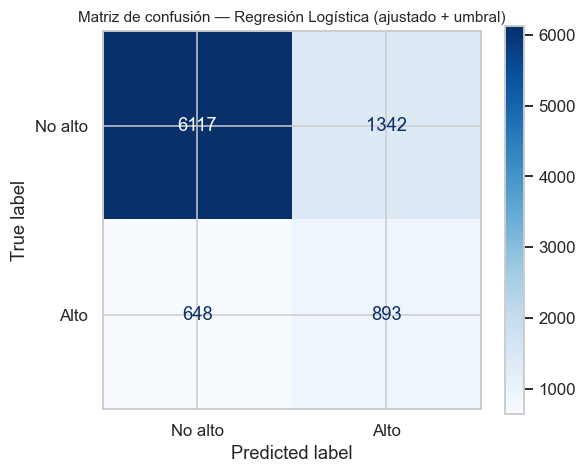

              precision    recall  f1-score   support

     No alto     0.9042    0.8201    0.8601      7459
        Alto     0.3996    0.5795    0.4730      1541

    accuracy                         0.7789      9000
   macro avg     0.6519    0.6998    0.6665      9000
weighted avg     0.8178    0.7789    0.7938      9000



In [44]:
# 5.2.3 Matriz de confusión del modelo final (se guarda también para mostrarla en la app)
fig, eje = plt.subplots(figsize=(5.5, 4.5))
# values_format="d": conteos enteros; la diagonal son aciertos (VN, VP) y fuera de ella los errores (FP, FN)
ConfusionMatrixDisplay.from_predictions(y_test, predicciones[NOMBRE_FINAL], display_labels=["No alto", "Alto"],
                                        cmap="Blues", values_format="d", ax=eje)
eje.set_title(f"Matriz de confusión — {NOMBRE_FINAL}", fontsize=10)
plt.tight_layout(); guardar_figura("matriz_confusion_final"); plt.show()
# classification_report: precision, recall y F1 de cada clase, más sus promedios
print(classification_report(y_test, predicciones[NOMBRE_FINAL], target_names=["No alto", "Alto"], digits=4))

🔎 **Interpretación:** La matriz de confusión del modelo final en test:

| | Predicho alto | Predicho no alto |
|---|---|---|
| **Real alto** (1.541) | 893 detectados (VP) | 648 no detectados (FN) |
| **Real no alto** (7.459) | 1.342 falsos positivos (FP) | 6.117 correctos (VN) |

- De cada 10 estudiantes señalados como "alto", 4 lo son (Precision 0,40). Se detecta al 58 % de los que realmente lo son (Recall 0,58).
- Para la clase "no alto" el desempeño es alto (F1 0,86): es la clase fácil y mayoritaria.

En un uso de focalización, los falsos positivos son estudiantes con buen perfil socioeconómico que no alcanzaron 300. Los falsos negativos son estudiantes que superaron las expectativas de su contexto. Ambos grupos muestran los límites de predecir con variables estructurales.

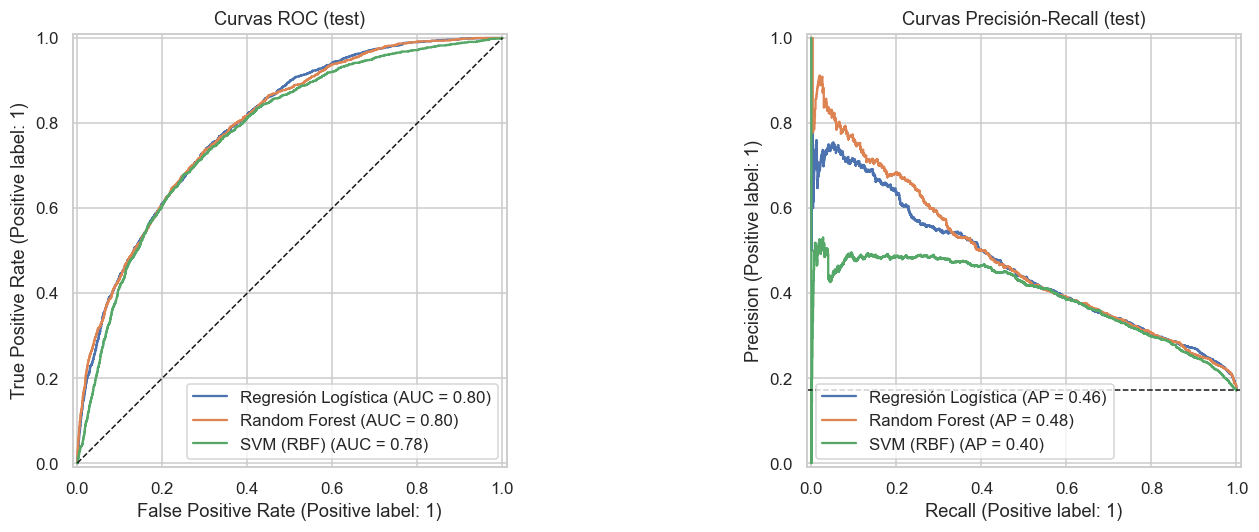

In [45]:
# 5.2.4 Curvas ROC y Precisión-Recall de los modelos ajustados (mismo puntaje con o sin umbral)
# Las curvas recorren todos los umbrales posibles: comparan la capacidad de ORDENAR, no una decisión concreta
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
for nombre, busqueda in busquedas.items():
    puntaje = puntaje_positivo(busqueda.best_estimator_, X_test)
    RocCurveDisplay.from_predictions(y_test, puntaje, name=nombre, ax=ejes[0])
    PrecisionRecallDisplay.from_predictions(y_test, puntaje, name=nombre, ax=ejes[1])
ejes[0].plot([0, 1], [0, 1], "k--", lw=1); ejes[0].set_title("Curvas ROC (test)")   # Diagonal = clasificador aleatorio
ejes[1].axhline(y_test.mean(), ls="--", color="k", lw=1, label="Azar")              # En PR el azar es la prevalencia
ejes[1].set_title("Curvas Precisión-Recall (test)")
plt.tight_layout(); guardar_figura("roc_pr"); plt.show()

🔎 **Interpretación:** - **Curvas ROC:** la logística y Random Forest son casi idénticas (AUC ≈ 0,80) y el SVM queda algo por debajo (0,78).
- **Curvas Precisión-Recall:** Random Forest tiene la mejor PR-AUC (0,48), seguida de la logística (0,46). El SVM queda en 0,40, porque sus puntajes de decisión ordenan peor a los casos más seguros. Todas superan con amplitud la línea del azar (prevalencia 0,17).

Random Forest es algo mejor en la zona de **alta precisión y bajo recall**: si el objetivo fuera identificar solo a los estudiantes con probabilidad muy alta, podría convenir. En el punto de operación elegido (F1 máximo), ambos modelos coinciden.

#### 📘 Concepto: Curva de aprendizaje
Grafica el desempeño en entrenamiento y en validación a medida que crece el número de registros de entrenamiento:
- **Curvas que convergen en un valor bajo:** alto **sesgo**. Más datos no ayudan; hacen falta mejores variables o un modelo más flexible.
- **Brecha grande entre ambas curvas:** alta **varianza**. Más datos o más regularización ayudan.
- **Curva de validación que se aplana (meseta):** agregar datos casi no mejora el modelo.

Aquí justifica empíricamente haber modelado con una muestra de 30.000 registros en lugar de los ~72 mil registros limpios disponibles.

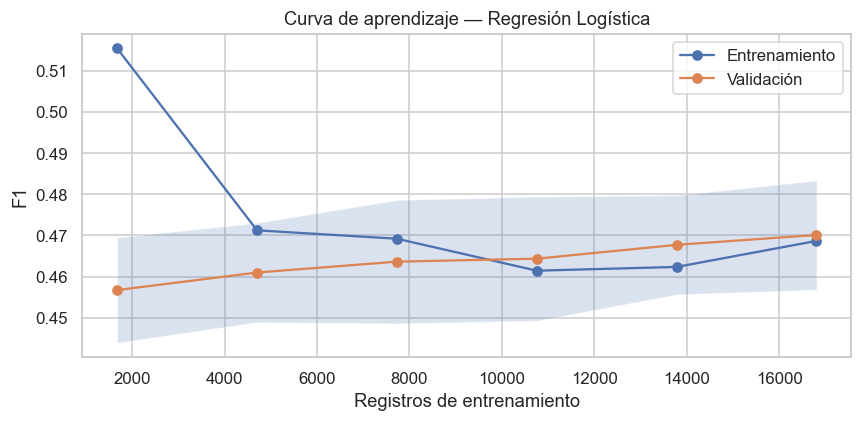

In [46]:
# 5.2.5 Curva de aprendizaje del modelo final: ¿más datos mejorarían el F1? (justifica la muestra de 30.000)
# train_sizes: 6 tamaños entre el 10 % y el 100 % del entrenamiento; en cada uno se hace la CV de 5 folds
tamanos, f1_entrena, f1_valida = learning_curve(busquedas[FAMILIA_FINAL].best_estimator_, X_train, y_train, cv=CV,
                                                 scoring="f1", train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
fig, eje = plt.subplots(figsize=(8, 4))
eje.plot(tamanos, f1_entrena.mean(axis=1), marker="o", label="Entrenamiento")   # Media de los 5 folds
eje.plot(tamanos, f1_valida.mean(axis=1), marker="o", label="Validación")
# Banda de ± 1 desviación: variabilidad entre folds
eje.fill_between(tamanos, f1_valida.mean(axis=1) - f1_valida.std(axis=1), f1_valida.mean(axis=1) + f1_valida.std(axis=1), alpha=0.2)
eje.set_xlabel("Registros de entrenamiento"); eje.set_ylabel("F1"); eje.set_title(f"Curva de aprendizaje — {FAMILIA_FINAL}"); eje.legend()
plt.tight_layout(); guardar_figura("curva_aprendizaje"); plt.show()

🔎 **Interpretación:** La curva de aprendizaje de la regresión logística muestra que el F1 de entrenamiento y el de validación **convergen alrededor de 0,47** a partir de unos 10 mil registros. Con 17 mil la brecha es prácticamente nula.
Según el 📘, este patrón indica **alto sesgo**, no alta varianza: agregar más registros (por ejemplo, los 72 mil disponibles) apenas mejoraría el modelo. Esto **justifica empíricamente** haber modelado con 30 mil registros. Para mejorar habría que aportar **variables más informativas**, como el efecto colegio (extensión E1).

#### 📘 Concepto: Importancia por permutación
Mide cuánto **empeora** la métrica cuando se desordenan al azar los valores de una variable en el test. Así se rompe su
relación con el objetivo sin cambiar su distribución:
$$I_j = s(\text{modelo}, X) - \frac{1}{R}\sum_{r=1}^{R} s\big(\text{modelo}, X^{(j,\,r)}_{\text{permutada}}\big)$$
- **Ventajas:** sirve con cualquier modelo (incluidos ensambles y pipelines), se mide en la métrica de negocio (F1) y
  actúa sobre las variables **originales**, no sobre las columnas codificadas.
- **Limitaciones:** con variables correlacionadas reparte (o subestima) la importancia, y describe asociación **en el
  modelo**, no causalidad en el mundo (Molnar, 2022).

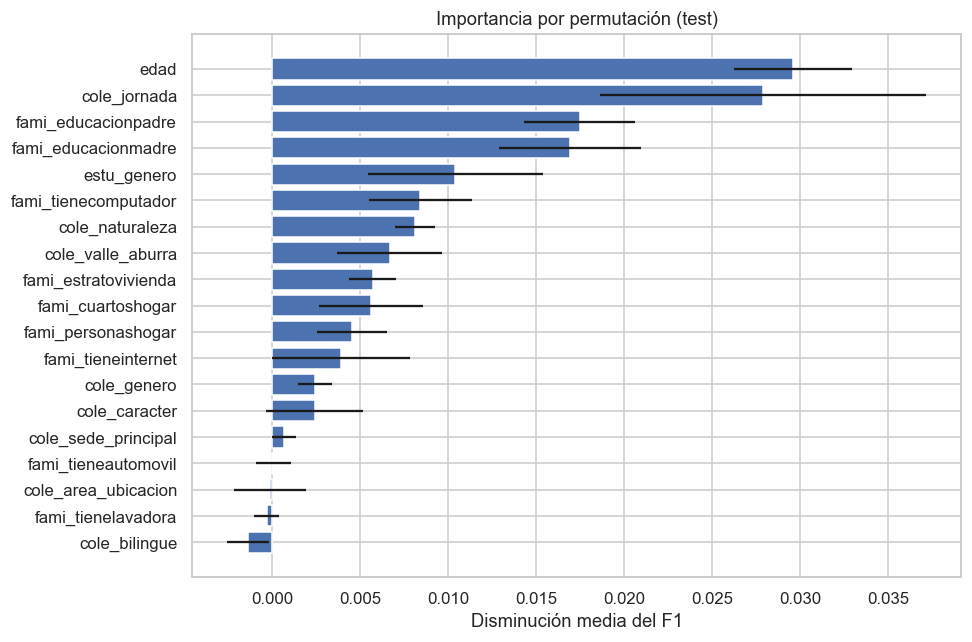

,variable,importancia,desviacion
0,edad,0.0296,0.0034
1,cole_jornada,0.0279,0.0093
2,fami_educacionpadre,0.0175,0.0032
3,fami_educacionmadre,0.0169,0.0040
4,estu_genero,0.0104,0.0050
5,fami_tienecomputador,0.0084,0.0029
6,cole_naturaleza,0.0081,0.0011
7,cole_valle_aburra,0.0067,0.0030
8,fami_estratovivienda,0.0057,0.0013
9,fami_cuartoshogar,0.0056,0.0029


In [47]:
# 5.2.6 Importancia de variables por permutación en test (caída del F1 al desordenar cada variable)
# n_repeats=5: cada variable se permuta 5 veces y se promedia, para reducir el ruido del azar
importancia = permutation_importance(modelo_final, X_test, y_test, scoring="f1", n_repeats=5,
                                     random_state=RANDOM_STATE, n_jobs=-1)
df_importancia = (pd.DataFrame({"variable": FEATURES, "importancia": importancia.importances_mean,
                                "desviacion": importancia.importances_std})
                  .sort_values("importancia", ascending=False).reset_index(drop=True))
df_importancia.to_csv(DIR_MODELOS / "importancias.csv", index=False)   # La app muestra este gráfico

fig, eje = plt.subplots(figsize=(9, 6))
eje.barh(df_importancia["variable"], df_importancia["importancia"], xerr=df_importancia["desviacion"], color="#4C72B0")
eje.invert_yaxis(); eje.set_xlabel("Disminución media del F1"); eje.set_title("Importancia por permutación (test)")
plt.tight_layout(); guardar_figura("importancia_permutacion"); plt.show()
df_importancia.round(4)   # Valores ≈ 0 (o negativos) = la variable no aporta al modelo

🔎 **Interpretación:** Las variables más importantes por permutación (caída del F1 al desordenarlas) son:

| Variable | Caída del F1 |
|---|---|
| Edad | 0,030 |
| Jornada | 0,028 |
| Educación del padre | 0,018 |
| Educación de la madre | 0,017 |
| Género | 0,010 |
| Computador en el hogar | 0,008 |
| Naturaleza del colegio | 0,008 |
| Valle de Aburrá | 0,007 |

El **estrato** aparece con una importancia baja (0,006), aunque en 3.6 estaba muy asociado al objetivo. Es la limitación descrita en el 📘: comparte información con la educación de los padres y las tenencias del hogar. Al desordenarlo, el modelo compensa con esas variables correlacionadas.
Automóvil, zona rural/urbana, lavadora y colegio bilingüe tienen importancias de cero o negativas: no aportan al modelo una vez consideradas las demás.

#### 📘 Concepto: Equidad por subgrupos
Un buen desempeño global puede esconder un desempeño pobre en algunos grupos. La **auditoría por subgrupos** calcula
las métricas por separado para cada grupo (género, zona, naturaleza del colegio, subregión) y compara:
- **Tasa real vs. tasa predicha:** si el modelo exagera o atenúa las diferencias que ya existen.
- **Recall por grupo** (*igualdad de oportunidad*, Hardt et al., 2016): ¿detecta igual de bien a los estudiantes de alto
  desempeño de cada grupo?
- **Precision por grupo:** ¿se equivoca más al señalar "alto" en algún grupo?

No existe una única definición de equidad y varias son incompatibles entre sí (Barocas, Hardt y Narayanan, 2023). El
objetivo aquí es **hacer visibles** las diferencias para interpretarlas y discutirlas.

In [48]:
# 5.2.7 Desempeño por subgrupo: control de sesgo del modelo final (género, zona, naturaleza, subregión)
serie_pred = pd.Series(predicciones[NOMBRE_FINAL], index=X_test.index)   # Predicciones alineadas con los índices de test
filas = []
for var in ["estu_genero", "cole_area_ubicacion", "cole_naturaleza", "cole_valle_aburra"]:
    for grupo, indices in X_test.groupby(X_test[var].fillna("DESCONOCIDO")).groups.items():   # Índices de cada grupo
        real, pred = y_test.loc[indices], serie_pred.loc[indices]
        # zero_division=0 evita errores en grupos sin positivos predichos
        filas.append({"variable": var, "grupo": grupo, "registros": len(indices),
                      "tasa_real": real.mean(), "tasa_predicha": pred.mean(),
                      "precision": precision_score(real, pred, zero_division=0),
                      "recall": recall_score(real, pred, zero_division=0), "f1": f1_score(real, pred, zero_division=0)})
tabla_subgrupos = guardar_tabla(pd.DataFrame(filas).round(4), "desempeno_subgrupos")
tabla_subgrupos

,variable,grupo,registros,tasa_real,tasa_predicha,precision,recall,f1
0,estu_genero,F,4974,0.1456,0.1673,0.4411,0.5069,0.4717
1,estu_genero,M,4026,0.2029,0.3485,0.3749,0.6438,0.4739
2,cole_area_ubicacion,RURAL,1485,0.1064,0.1057,0.4841,0.4810,0.4825
3,cole_area_ubicacion,URBANO,7515,0.1840,0.2765,0.3932,0.5907,0.4721
4,cole_naturaleza,NO OFICIAL,1843,0.3201,0.5334,0.5239,0.8729,0.6548
5,cole_naturaleza,OFICIAL,7157,0.1329,0.1749,0.3019,0.3975,0.3432
6,cole_valle_aburra,No,3743,0.1122,0.1341,0.3486,0.4167,0.3796
7,cole_valle_aburra,Sí,5257,0.2132,0.3297,0.4143,0.6405,0.5032


🔎 **Interpretación:** La auditoría por subgrupos revela **diferencias importantes**:
- **Naturaleza del colegio:** F1 de 0,65 en colegios no oficiales frente a 0,34 en oficiales. En los oficiales el modelo solo detecta al 40 % de los estudiantes de alto desempeño (Recall 0,40, frente a 0,87 en los no oficiales).
- **Subregión:** fuera del Valle de Aburrá, F1 0,38 frente a 0,50 dentro.
- **Género:** el F1 es similar (0,47 en ambos), pero en hombres el modelo **sobrepredice** "alto" (35 % predicho frente a 20 % real), mientras en mujeres queda cerca de la tasa real (17 % frente a 15 %).

El modelo funciona peor precisamente en los grupos menos favorecidos: los estudiantes de alto desempeño en colegios oficiales o fuera del área metropolitana tienen perfiles socioeconómicos "atípicos" que el modelo no reconoce. Es la amplificación del **sesgo histórico** anticipada en 2.4 y la razón principal para no usar este modelo en decisiones individuales.

In [49]:
# 5.2.8 Justificación técnica y estadística del modelo seleccionado (tabla 5.2 del informe)
fila_final = df_test.set_index("modelo").loc[NOMBRE_FINAL]   # Métricas de test del modelo final
ic_final = df_ic.set_index("candidato").loc[NOMBRE_FINAL]    # Su intervalo de confianza bootstrap
# El texto se arma con las cifras calculadas: si los datos cambian, la justificación cambia con ellos
justificacion_final = (
    f"Mayor F1 en validación cruzada ({cv_f1[NOMBRE_FINAL]:.4f}). En test: F1 = {fila_final['f1']:.4f} "
    f"(IC95 % bootstrap {ic_final['ic95_inf']:.3f}–{ic_final['ic95_sup']:.3f}), Recall = {fila_final['recall']:.4f}, "
    f"Precision = {fila_final['precision']:.4f}, ROC-AUC = {fila_final['roc_auc']:.4f}. "
    f"McNemar frente a {RIVAL}: p = {p_mcnemar:.3g}. t-test corregido (Nadeau–Bengio) en CV frente a {FAMILIA_RIVAL}: "
    f"p = {p_t_rival:.3g}; frente a la regresión logística base: p = {p_t_base:.3g}.")
guardar_tabla(pd.DataFrame({"modelo_final": [NOMBRE_FINAL], "justificacion": [justificacion_final]}), "modelo_seleccionado")
print(justificacion_final)

Mayor F1 en validación cruzada (0.4856). En test: F1 = 0.4730 (IC95 % bootstrap 0.453–0.494), Recall = 0.5795, Precision = 0.3996, ROC-AUC = 0.7975. McNemar frente a Random Forest (ajustado + umbral): p = 0.0249. t-test corregido (Nadeau–Bengio) en CV frente a Random Forest: p = 0.895; frente a la regresión logística base: p = 0.67.


🔎 **Interpretación:** La justificación final (tabla 5.2 del informe) reúne los argumentos técnicos y estadísticos:
- El modelo tiene el mayor F1 en validación cruzada (0,4856).
- En test obtiene F1 = 0,4730, con IC95 % de 0,453 a 0,494, Recall 0,58, Precision 0,40 y ROC-AUC 0,80.
- McNemar indica que comete menos errores que Random Forest (p = 0,025).
- El t-test corregido confirma que la diferencia de F1 frente a Random Forest no es significativa (p = 0,895).

A igualdad de F1 prima la **simplicidad y la interpretabilidad**: la regresión logística se explica con coeficientes y pesa solo 20 KB.

### 🧠 Para profundizar — Fase 5: Evaluación
**Ideas clave**
- Con clases desbalanceadas importan Precision, Recall, F1 y PR-AUC; la *accuracy* es secundaria.
- Se **selecciona** con validación cruzada y se **confirma** con el test; usar el test para elegir sesga la estimación.
- Una diferencia de métricas solo es relevante si sobrevive a una prueba estadística (bootstrap, McNemar, t corregido).
- Interpretar el modelo (importancias) y auditarlo por grupos es parte de la evaluación, no un extra.

**Preguntas de repaso**
1. Un modelo tiene Recall 0,80 y Precision 0,30. ¿Cuál es su F1 y qué significa para una secretaría que asigna becas?
2. ¿Por qué el t-test clásico sobre los folds de CV da p-valores demasiado pequeños?
3. ¿Qué indica una curva de aprendizaje donde entrenamiento y validación convergen en F1 ≈ 0,5?
4. Si el Recall es mucho menor en colegios rurales, ¿qué acciones de preparación o de modelamiento lo mitigarían?

**Ejercicios**
- Grafica Precision, Recall y F1 en test en función del umbral (0,05 a 0,95) y ubica el umbral elegido en 4.3.5.
- Calcula la importancia por permutación con `scoring="roc_auc"` y compara el ranking con el de F1.

**Referencias**
- Saito, T. y Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE*, 10(3).
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895–1923.
- Nadeau, C. y Bengio, Y. (2003). Inference for the generalization error. *Machine Learning*, 52, 239–281.
- Efron, B. y Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall.
- Molnar, C. (2022). *Interpretable Machine Learning* (2.ª ed.). https://christophm.github.io/interpretable-ml-book/
- Hardt, M., Price, E. y Srebro, N. (2016). Equality of opportunity in supervised learning. *NeurIPS*.
- Barocas, S., Hardt, M. y Narayanan, A. (2023). *Fairness and Machine Learning*. MIT Press.

## 6. Despliegue
### 6.1 Serialización del pipeline completo

#### 📘 Concepto: Serialización de modelos
**Serializar** es guardar en disco el objeto entrenado para usarlo después sin reentrenar. Aquí se serializa el
**pipeline completo** (imputación → codificación → escalado → modelo) y no solo el modelo. Así la aplicación recibe datos
en su forma original y les aplica **exactamente** las mismas transformaciones que en el entrenamiento; se evita el
*training-serving skew* (Sculley et al., 2015).

- **joblib** es el formato recomendado por scikit-learn: se basa en *pickle* y es eficiente con arreglos numéricos.
- **Versiones:** un pickle solo es confiable con las **mismas versiones** de las librerías. Por eso se guardan en la metadata y se fijan en `requirements.txt`.
- **Seguridad:** cargar un pickle ejecuta código. Solo se cargan archivos de **fuentes confiables** (aquí, el propio repositorio).
- **Metadata:** variables esperadas, categorías válidas, umbral y métricas acompañan al modelo. La app se construye a partir de ella, sin valores fijos en el código.

Las pruebas automáticas de `tests/test_modelo.py` verifican que el artefacto cargue, prediga y tolere valores inesperados.

In [50]:
# 6.1.1 Extraer el pipeline final y su umbral, y serializarlo con joblib
if isinstance(modelo_final, TunedThresholdClassifierCV):
    # El envoltorio del umbral contiene el pipeline reentrenado (estimator_) y el umbral óptimo (best_threshold_)
    pipeline_final, umbral_final = modelo_final.estimator_, float(modelo_final.best_threshold_)
else:
    pipeline_final = modelo_final
    umbral_final = 0.5 if hasattr(pipeline_final, "predict_proba") else 0.0   # 0 = frontera de decision_function

RUTA_MODELO = DIR_MODELOS / "pipeline_saber11.joblib"
joblib.dump(pipeline_final, RUTA_MODELO, compress=3)   # compress=3: buen equilibrio entre tamaño y velocidad de carga
tamano_mb = RUTA_MODELO.stat().st_size / 1e6
assert tamano_mb < 95, "El modelo supera el límite de GitHub (100 MB)"
print(f"Pipeline guardado: {RUTA_MODELO.name} ({tamano_mb:.1f} MB) | umbral de decisión = {umbral_final:.4f}")
if tamano_mb > 25:   # La carga por la web de GitHub admite hasta 25 MB; con git se admiten hasta 100 MB
    print("Aviso: supera 25 MB; súbalo con git (no con la carga web de GitHub).")
print("Pasos:", [nombre for nombre, _ in pipeline_final.steps])   # El balanceo se omite al predecir (solo actúa en fit)

Pipeline guardado: pipeline_saber11.joblib (0.0 MB) | umbral de decisión = 0.6152
Pasos: ['preprocesamiento', 'balanceo', 'modelo']


🔎 **Interpretación:** Se serializó el pipeline completo (`preprocesamiento` → `balanceo` → `modelo`) en `models/pipeline_saber11.joblib`. Pesa unos **20 KB** porque una regresión logística guarda un coeficiente por columna codificada. Un Random Forest de 341 árboles habría pesado decenas de MB.
El umbral de decisión (0,6152) se extrajo del envoltorio `TunedThresholdClassifierCV` y se guardará en la metadata. El paso `balanceo` viaja dentro del pipeline, pero solo actúa en `fit`: al predecir no altera los datos.

In [51]:
# 6.1.2 Metadata para la app: variables, categorías válidas, etiquetas, umbral, métricas y versiones
# Etiquetas legibles para el formulario de la app (el usuario no ve nombres técnicos como fami_estratovivienda)
ETIQUETAS = {"edad": "Edad (años)", "estu_genero": "Género del estudiante", "fami_estratovivienda": "Estrato de la vivienda",
             "fami_educacionmadre": "Educación de la madre", "fami_educacionpadre": "Educación del padre",
             "fami_personashogar": "Personas en el hogar", "fami_cuartoshogar": "Cuartos en el hogar",
             "fami_tieneinternet": "¿Internet en el hogar?", "fami_tienecomputador": "¿Computador en el hogar?",
             "fami_tieneautomovil": "¿Automóvil en el hogar?", "fami_tienelavadora": "¿Lavadora en el hogar?",
             "cole_naturaleza": "Naturaleza del colegio", "cole_jornada": "Jornada", "cole_area_ubicacion": "Zona del colegio",
             "cole_bilingue": "¿Colegio bilingüe? (S/N)", "cole_caracter": "Carácter del colegio",
             "cole_genero": "Género del colegio", "cole_sede_principal": "¿Sede principal? (S/N)",
             "cole_valle_aburra": "¿Colegio en el Valle de Aburrá?"}
# Opciones de cada lista desplegable: categorías vistas en entrenamiento (nominales) u orden natural (ordinales)
categorias_app = {v: sorted(X_train[v].dropna().unique().tolist()) for v in VARIABLES_NOMINALES}
categorias_app.update({v: list(ORDEN_ORDINALES[v]) for v in VARIABLES_ORDINALES})
for v in ["fami_educacionmadre", "fami_educacionpadre"]:
    categorias_app[v] = categorias_app[v] + ["No sabe"]   # El pipeline lo trata como faltante (imputación)

metadata = {
    "proyecto": "Predicción de alto desempeño en Saber 11 — Antioquia 2022-2",
    "proposito": "Proyecto académico de maestría con fines exclusivamente educativos; no es una herramienta oficial",
    "fuente": URL_DATASET, "objetivo": f"alto_desempeno = 1 si punt_global >= {UMBRAL_ALTO_DESEMPENO}",
    "modelo_final": NOMBRE_FINAL, "umbral_decision": umbral_final,
    "tipo_puntaje": "probabilidad" if hasattr(pipeline_final, "predict_proba") else "decision",
    # Si el modelo es XGBoost, la app necesita instalar xgboost (se usa al generar requirements.txt)
    "requiere_xgboost": type(pipeline_final.named_steps["modelo"]).__module__.startswith("xgboost"),
    "features": FEATURES, "variables_numericas": VARIABLES_NUMERICAS, "variables_ordinales": VARIABLES_ORDINALES,
    "variables_nominales": VARIABLES_NOMINALES, "categorias": categorias_app, "etiquetas": ETIQUETAS,
    "rango_edad": [13, 30], "edad_mediana": float(X_train["edad"].median()),
    # Moda de cada variable: el formulario de la app arranca con un perfil típico y no con la primera opción alfabética
    "valores_por_defecto": {v: str(X_train[v].mode()[0]) for v in VARIABLES_ORDINALES + VARIABLES_NOMINALES},
    "metricas_test": {k: float(v) for k, v in df_test.set_index("modelo").loc[NOMBRE_FINAL].items()},   # float: JSON no admite numpy
    "n_entrenamiento": int(len(X_train)), "n_prueba": int(len(X_test)),
    "versiones": {"python": sys.version.split()[0], "scikit-learn": sklearn.__version__, "imbalanced-learn": imblearn.__version__,
                  "xgboost": xgboost.__version__, "pandas": pd.__version__, "numpy": np.__version__},
    "fecha_entrenamiento": pd.Timestamp.now().strftime("%Y-%m-%d"),
}
# ensure_ascii=False conserva tildes y eñes legibles en el archivo JSON
(DIR_MODELOS / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps({k: metadata[k] for k in ["modelo_final", "umbral_decision", "tipo_puntaje", "metricas_test"]},
                 ensure_ascii=False, indent=2))

{
  "modelo_final": "Regresión Logística (ajustado + umbral)",
  "umbral_decision": 0.6152265930370098,
  "tipo_puntaje": "probabilidad",
  "metricas_test": {
    "accuracy": 0.7788888888888889,
    "precision": 0.3995525727069351,
    "recall": 0.5794938351719663,
    "f1": 0.4729872881355932,
    "roc_auc": 0.7975366352717372,
    "pr_auc": 0.46134249032583907
  }
}


🔎 **Interpretación:** La metadata registra todo lo que la app necesita sin fijar valores en el código:
- Las 19 variables y sus categorías válidas, en el orden natural para las ordinales.
- Las etiquetas legibles para el formulario.
- El umbral (0,615), el tipo de puntaje (probabilidad) y las métricas de test (F1 0,473, ROC-AUC 0,798).
- Las versiones exactas de las librerías.
- El propósito académico del proyecto.

`requiere_xgboost = False`: la app no necesita instalar xgboost, lo que aligera el despliegue en Streamlit Cloud.

In [52]:
# 6.1.3 Verificación: el pipeline recargado desde disco produce exactamente los mismos puntajes
# joblib usa pickle: solo se carga el archivo que acabamos de generar (fuente confiable)
pipeline_recargado = joblib.load(RUTA_MODELO)
# np.allclose tolera diferencias mínimas de redondeo en coma flotante
assert np.allclose(puntaje_positivo(pipeline_recargado, X_test), puntaje_positivo(pipeline_final, X_test))
print("Pipeline recargado: predicciones idénticas en los", len(X_test), "registros de prueba")

Pipeline recargado: predicciones idénticas en los 9000 registros de prueba


🔎 **Interpretación:** El pipeline recargado desde disco produce **exactamente** los mismos puntajes en los 9.000 registros de prueba. Así se verifica que la serialización conserva el modelo completo (preprocesamiento incluido) y que lo que se evaluó en la fase 5 es lo que se despliega.
Esta misma verificación está automatizada en `tests/test_modelo.py`, que además prueba categorías desconocidas y valores faltantes.

### 6.2 Predicción con datos nuevos

#### 📘 Concepto: Generalización a datos nuevos
Un modelo es útil si **generaliza**: si mantiene su desempeño en datos que no participaron en ninguna decisión del
entrenamiento. Aquí se prueban dos tipos de datos nuevos:
- **Perfiles sintéticos:** combinaciones construidas a mano (arquetipos) o al azar. Sirven para verificar que el pipeline
  acepta entradas nuevas y que las predicciones son **coherentes con el conocimiento del dominio** (prueba de sensatez).
- **Registros reales no vistos:** ~42 mil registros del *pool* que quedaron fuera de la muestra de modelado. Si su F1 es
  similar al del test, se confirma la estimación de desempeño.

En un despliegue real además cambia la distribución de los datos con el tiempo (*data drift*: nuevas cohortes, cambios
en el examen). Por eso los modelos en producción se **monitorean** y se reentrenan periódicamente.

In [53]:
# 6.2.1 Generación de 10 perfiles nuevos: 5 arquetipos diseñados + 5 aleatorios de las distribuciones observadas
# Perfil base "típico"; cada arquetipo modifica solo las variables que lo caracterizan
BASE_PERFIL = {"edad": 17, "estu_genero": "F", "fami_estratovivienda": "Estrato 2",
               "fami_educacionmadre": "Secundaria (Bachillerato) completa", "fami_educacionpadre": "Secundaria (Bachillerato) completa",
               "fami_personashogar": "3 a 4", "fami_cuartoshogar": "Tres", "fami_tieneinternet": "Si", "fami_tienecomputador": "Si",
               "fami_tieneautomovil": "No", "fami_tienelavadora": "Si", "cole_naturaleza": "OFICIAL", "cole_jornada": "MAÑANA",
               "cole_area_ubicacion": "URBANO", "cole_bilingue": "N", "cole_caracter": "ACADÉMICO", "cole_genero": "MIXTO",
               "cole_sede_principal": "S", "cole_valle_aburra": "Sí"}
ARQUETIPOS = [   # (nombre, cambios respecto al perfil base)
    ("A1 · Rural oficial, estrato 1, sin internet ni computador",
     {"edad": 18, "estu_genero": "M", "fami_estratovivienda": "Estrato 1", "fami_educacionmadre": "Primaria incompleta",
      "fami_educacionpadre": "Primaria incompleta", "fami_personashogar": "5 a 6", "fami_cuartoshogar": "Dos",
      "fami_tieneinternet": "No", "fami_tienecomputador": "No", "fami_tienelavadora": "No", "cole_jornada": "UNICA",
      "cole_area_ubicacion": "RURAL", "cole_caracter": "TÉCNICO/ACADÉMICO", "cole_sede_principal": "N", "cole_valle_aburra": "No"}),
    ("A2 · Urbano oficial del Valle de Aburrá, estrato 2, madre bachiller", {}),   # Es el perfil base sin cambios
    ("A3 · Urbano no oficial, estrato 4, padres profesionales",
     {"estu_genero": "M", "fami_estratovivienda": "Estrato 4", "fami_educacionmadre": "Educación profesional completa",
      "fami_educacionpadre": "Educación profesional completa", "fami_tieneautomovil": "Si", "cole_naturaleza": "NO OFICIAL",
      "cole_jornada": "COMPLETA"}),
    ("A4 · Colegio bilingüe no oficial, estrato 6, padres con posgrado",
     {"edad": 16, "fami_estratovivienda": "Estrato 6", "fami_educacionmadre": "Postgrado", "fami_educacionpadre": "Postgrado",
      "fami_cuartoshogar": "Cuatro", "fami_tieneautomovil": "Si", "cole_naturaleza": "NO OFICIAL", "cole_jornada": "COMPLETA",
      "cole_bilingue": "S"}),
    ("A5 · Adulto en jornada sabatina, estrato 2, padre desconocido",   # "No sabe" prueba el manejo de faltantes
     {"edad": 26, "fami_educacionmadre": "Primaria completa", "fami_educacionpadre": "No sabe", "fami_cuartoshogar": "Dos",
      "fami_tienecomputador": "No", "cole_naturaleza": "NO OFICIAL", "cole_jornada": "SABATINA"}),
]
rng = np.random.default_rng(RANDOM_STATE)   # Generador reproducible para los perfiles aleatorios
# {**BASE_PERFIL, **cambios}: el segundo diccionario sobrescribe las claves del primero
registros = [{"registro": nombre, **BASE_PERFIL, **cambios} for nombre, cambios in ARQUETIPOS]
for i in range(1, 6):
    # Cada variable se sortea de su distribución marginal observada (las combinaciones pueden ser inusuales)
    aleatorio = {v: rng.choice(X_train[v].dropna().to_numpy()) for v in FEATURES if v != "edad"}
    registros.append({"registro": f"R{i} · Perfil aleatorio", "edad": int(rng.integers(15, 20)), **aleatorio})
df_nuevos = pd.DataFrame(registros)[["registro"] + FEATURES]
df_nuevos.to_csv(DIR_NUEVOS / "perfiles_nuevos.csv", index=False)   # Entregable: "generar nuevos datos de entrada"
df_nuevos

,registro,edad,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_personashogar,fami_cuartoshogar,estu_genero,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,cole_naturaleza,cole_jornada,cole_area_ubicacion,cole_bilingue,cole_caracter,cole_genero,cole_sede_principal,cole_valle_aburra
0,"A1 · Rural oficial, estrato 1, sin internet ni...",18,Estrato 1,Primaria incompleta,Primaria incompleta,5 a 6,Dos,M,No,No,No,No,OFICIAL,UNICA,RURAL,N,TÉCNICO/ACADÉMICO,MIXTO,N,No
1,"A2 · Urbano oficial del Valle de Aburrá, estra...",17,Estrato 2,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,3 a 4,Tres,F,Si,Si,No,Si,OFICIAL,MAÑANA,URBANO,N,ACADÉMICO,MIXTO,S,Sí
2,"A3 · Urbano no oficial, estrato 4, padres prof...",17,Estrato 4,Educación profesional completa,Educación profesional completa,3 a 4,Tres,M,Si,Si,Si,Si,NO OFICIAL,COMPLETA,URBANO,N,ACADÉMICO,MIXTO,S,Sí
3,"A4 · Colegio bilingüe no oficial, estrato 6, p...",16,Estrato 6,Postgrado,Postgrado,3 a 4,Cuatro,F,Si,Si,Si,Si,NO OFICIAL,COMPLETA,URBANO,S,ACADÉMICO,MIXTO,S,Sí
4,"A5 · Adulto en jornada sabatina, estrato 2, pa...",26,Estrato 2,Primaria completa,No sabe,3 a 4,Dos,F,Si,No,No,Si,NO OFICIAL,SABATINA,URBANO,N,ACADÉMICO,MIXTO,S,Sí
5,R1 · Perfil aleatorio,19,Estrato 3,Primaria incompleta,Secundaria (Bachillerato) incompleta,3 a 4,Tres,F,Si,Si,Si,Si,OFICIAL,COMPLETA,URBANO,N,TÉCNICO/ACADÉMICO,MIXTO,S,Sí
6,R2 · Perfil aleatorio,19,Estrato 3,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,3 a 4,Seis o mas,F,Si,Si,Si,Si,OFICIAL,SABATINA,RURAL,N,ACADÉMICO,MIXTO,S,No
7,R3 · Perfil aleatorio,17,Estrato 3,Primaria completa,Primaria incompleta,3 a 4,Dos,M,Si,Si,No,No,OFICIAL,COMPLETA,URBANO,N,TÉCNICO,MIXTO,S,No
8,R4 · Perfil aleatorio,17,Estrato 2,Educación profesional completa,Primaria incompleta,7 a 8,Tres,F,Si,No,No,Si,OFICIAL,SABATINA,URBANO,N,TÉCNICO/ACADÉMICO,MIXTO,N,Sí
9,R5 · Perfil aleatorio,19,Estrato 1,Secundaria (Bachillerato) completa,Primaria completa,3 a 4,Cinco,F,Si,Si,No,Si,NO OFICIAL,COMPLETA,RURAL,N,TÉCNICO/ACADÉMICO,MIXTO,N,Sí


🔎 **Interpretación:** Se generaron 10 perfiles nuevos, guardados en `data/nuevos/perfiles_nuevos.csv`:
- **Cinco arquetipos diseñados:** desde un estudiante rural de estrato 1 sin internet hasta uno de colegio bilingüe de estrato 6. El A5 tiene educación del padre "No sabe" para probar el manejo de faltantes.
- **Cinco perfiles aleatorios**, muestreando cada variable de su distribución observada.

Los arquetipos funcionan como **pruebas de sensatez**: si el modelo les asignara probabilidades contrarias al conocimiento del dominio, habría un error en el pipeline.

In [54]:
# 6.2.2 Predicción e interpretación de los perfiles nuevos con el pipeline recargado
def interpretar(puntaje, umbral):
    """Traduce el puntaje a un mensaje comprensible (tres bandas alrededor del umbral de decisión)."""
    if puntaje >= umbral:
        return "Perfil similar a estudiantes con alto desempeño: priorizar oferta de becas y estímulos."
    if puntaje >= umbral / 2:
        return "Probabilidad intermedia: puede alcanzar el umbral con refuerzo focalizado."
    return "Baja probabilidad de alto desempeño: perfil prioritario para nivelación y acompañamiento."


# Se usa el pipeline RECARGADO desde disco: es exactamente lo que usará la app
puntajes_nuevos = puntaje_positivo(pipeline_recargado, df_nuevos[FEATURES])
tabla_nuevos = pd.DataFrame({
    "registro": df_nuevos["registro"],
    "prediccion": [f"{'Alto desempeño' if s >= umbral_final else 'No alto'} (puntaje = {s:.3f})" for s in puntajes_nuevos],
    "interpretacion": [interpretar(s, umbral_final) for s in puntajes_nuevos]})
guardar_tabla(tabla_nuevos, "predicciones_nuevas")   # Tabla 6.1 del informe
tabla_nuevos

,registro,prediccion,interpretacion
0,"A1 · Rural oficial, estrato 1, sin internet ni...",No alto (puntaje = 0.072),Baja probabilidad de alto desempeño: perfil pr...
1,"A2 · Urbano oficial del Valle de Aburrá, estra...",No alto (puntaje = 0.416),Probabilidad intermedia: puede alcanzar el umb...
2,"A3 · Urbano no oficial, estrato 4, padres prof...",Alto desempeño (puntaje = 0.913),Perfil similar a estudiantes con alto desempeñ...
3,"A4 · Colegio bilingüe no oficial, estrato 6, p...",Alto desempeño (puntaje = 0.865),Perfil similar a estudiantes con alto desempeñ...
4,"A5 · Adulto en jornada sabatina, estrato 2, pa...",No alto (puntaje = 0.008),Baja probabilidad de alto desempeño: perfil pr...
5,R1 · Perfil aleatorio,No alto (puntaje = 0.279),Baja probabilidad de alto desempeño: perfil pr...
6,R2 · Perfil aleatorio,No alto (puntaje = 0.083),Baja probabilidad de alto desempeño: perfil pr...
7,R3 · Perfil aleatorio,No alto (puntaje = 0.578),Probabilidad intermedia: puede alcanzar el umb...
8,R4 · Perfil aleatorio,No alto (puntaje = 0.129),Baja probabilidad de alto desempeño: perfil pr...
9,R5 · Perfil aleatorio,No alto (puntaje = 0.226),Baja probabilidad de alto desempeño: perfil pr...


🔎 **Interpretación:** Las predicciones son **coherentes con el dominio**:

| Perfil | Probabilidad | Predicción |
|---|---|---|
| A1 · rural, estrato 1 | 0,07 | No alto |
| A2 · urbano oficial, estrato 2 | 0,42 | No alto, intermedio |
| A3 · no oficial, estrato 4, padres profesionales | 0,91 | Alto |
| A4 · bilingüe, estrato 6 | 0,87 | Alto |
| A5 · adulto en jornada sabatina | 0,01 | No alto |

- El pipeline procesó sin errores la respuesta "No sabe" del A5.
- Los perfiles aleatorios quedan entre 0,08 y 0,58. Ninguno supera el umbral de 0,615, lo que es esperable: combinan al azar características de contextos distintos.

In [55]:
# 6.2.3 Predicción sobre 1.000 registros reales que NUNCA se usaron (pool fuera de la muestra de modelado)
df_no_vistos = df_pool.sample(1000, random_state=RANDOM_STATE)
# Garantía explícita de que ninguno participó en entrenamiento, validación ni prueba
assert set(df_no_vistos.index).isdisjoint(df_modelo.index), "Hay registros usados en el modelado"
df_no_vistos[FEATURES + [OBJETIVO, "punt_global"]].to_csv(DIR_NUEVOS / "registros_no_vistos_1000.csv", index=False)   # Ejemplo para la app
pred_no_vistos = (puntaje_positivo(pipeline_recargado, df_no_vistos[FEATURES]) >= umbral_final).astype(int)
# Si las métricas del pool son parecidas a las del test, la estimación de desempeño es confiable
comparacion = pd.DataFrame({
    "conjunto": ["Prueba (30 %)", "Pool no visto (1.000)"],
    "f1": [metadata["metricas_test"]["f1"], f1_score(df_no_vistos[OBJETIVO], pred_no_vistos)],
    "recall": [metadata["metricas_test"]["recall"], recall_score(df_no_vistos[OBJETIVO], pred_no_vistos)],
    "precision": [metadata["metricas_test"]["precision"], precision_score(df_no_vistos[OBJETIVO], pred_no_vistos)]}).round(4)
comparacion

,conjunto,f1,recall,precision
0,Prueba (30 %),0.4730,0.5795,0.3996
1,Pool no visto (1.000),0.4951,0.5829,0.4304


🔎 **Interpretación:** Sobre 1.000 registros reales del pool, que no participaron en entrenamiento, validación ni prueba, el modelo obtiene **F1 = 0,495**, Recall 0,583 y Precision 0,430. Son cifras muy cercanas a las del test (0,473, 0,580 y 0,400).
Esto confirma la **generalización**: la estimación de desempeño de la fase 5 era confiable. La pequeña diferencia a favor del pool está dentro de la variabilidad esperable con 1.000 registros (≈170 positivos). Estos registros se usan también como ejemplo de predicción por lotes en la app.

### 6.3 Aplicación web y publicación
- La app `app.py` (Streamlit) carga `models/pipeline_saber11.joblib` y `models/metadata.json`. Ofrece predicción
  individual, predicción por lotes (CSV) y una pestaña con métricas, matriz de confusión e importancias. En cada
  predicción indica la banda de acompañamiento (prioridad de nivelación si p < t/2, refuerzo focalizado si
  t/2 ≤ p < t, alto potencial si p ≥ t). Muestra un aviso de que es un **proyecto académico con fines educativos**.
- Repositorio GitHub: `app.py`, modelo serializado, `requirements.txt`, `README.md`, notebook, datos y reporte HTML.
- Despliegue: share.streamlit.io → *Create app* → repositorio → `app.py` → Python 3.12.

**¿Por qué Streamlit?** Convierte un script de Python en una aplicación web sin programar HTML ni JavaScript. Cada
interacción vuelve a ejecutar el script, y `st.cache_resource` evita recargar el modelo en cada clic. Es suficiente para
demostraciones y prototipos. Un servicio de producción usaría una API (p. ej. FastAPI) con monitoreo.

### 🧠 Para profundizar — Fase 6: Despliegue
**Ideas clave**
- Se despliega el **pipeline completo** y su **metadata**, no solo el modelo: así lo que se evalúa es lo que se usa.
- La reproducibilidad exige fijar versiones; la seguridad exige cargar pickles solo de fuentes confiables.
- Los datos nuevos (sintéticos y reales no vistos) comprueban la coherencia y la generalización del modelo.
- Desplegar no es el final: en un sistema real habría que monitorear el *drift* y reentrenar.

**Preguntas de repaso**
1. ¿Qué error ocurriría si la app aplicara su propio escalado en lugar de usar el del pipeline serializado?
2. ¿Por qué el umbral de decisión se guarda en la metadata en lugar de escribirse directamente en `app.py`?
3. ¿Qué señales indicarían que el modelo debe reentrenarse con la cohorte 2023?

**Ejercicios**
- Agrega a la app un gráfico que muestre cómo cambia la probabilidad al variar solo el estrato de un perfil (análisis de sensibilidad).
- Descarga el periodo 2021-2 (`periodo='20214'`) de la API y evalúa el modelo en esa cohorte: ¿hay *drift*?

**Referencias**
- Sculley, D. et al. (2015). Hidden technical debt in machine learning systems. *NeurIPS*.
- Documentación de scikit-learn: *Model persistence* (https://scikit-learn.org/stable/model_persistence.html).
- Documentación de Streamlit: https://docs.streamlit.io/
- Huyen, C. (2022). *Designing Machine Learning Systems*. O'Reilly (caps. 7 y 8: despliegue y monitoreo).

## Conclusiones
1. **Datos:** el conjunto 2022-2 de Antioquia (ICFES, Datos Abiertos Colombia) venía con el 50 % de filas duplicadas. La limpieza dejó 72.357 estudiantes con 17,1 % de alto desempeño (≥ 300 puntos). Las reglas de calidad y las pruebas con `assert` fueron esenciales para detectarlo.
2. **Modelo:** la **Regresión Logística con umbral ajustado (0,615)** logró F1 = 0,473 (IC95 % 0,453–0,494), Recall 0,58 y ROC-AUC 0,80 en test, y F1 = 0,495 en 1.000 registros nunca vistos.
3. **Comparación:** ni los modelos flexibles (Random Forest, SVM) ni los ensambles (votación, bagging, XGBoost) superaron al modelo lineal. Las pruebas estadísticas mostraron equivalencia en F1, así que se eligió el modelo más simple e interpretable. La mejora más grande vino de **ajustar el umbral**, no del algoritmo.
4. **Factores asociados:** la edad (extraedad), la jornada, la educación de los padres, el género, el acceso a computador y la naturaleza del colegio son las variables con mayor peso. Son asociaciones, no causas.
5. **Sesgo:** el modelo funciona peor en colegios oficiales (F1 0,34) y fuera del Valle de Aburrá (0,38), y sobrepredice alto desempeño en hombres. Reproduce las desigualdades del sistema educativo. Por eso su uso, aun académico, exige cautela y nunca debe servir para excluir.
6. **Limitaciones:** hay una sola cohorte (2022-2, pospandemia) y solo variables socioeconómicas y del colegio. La curva de aprendizaje muestra alto sesgo: con estas variables el techo de F1 ronda 0,47–0,49.
7. **Trabajo futuro:** incorporar el **efecto colegio** (promedio histórico del colegio en cohortes anteriores, extensión E1), validar en otras cohortes para medir *drift*, calibrar las probabilidades y explorar métricas de equidad como restricción del entrenamiento.